# Exploratory Visual Analysis

## Analysis Objective

This notebook explores purchasing behaviour, transaction patterns, product performance, sales channels, promotions, and customer experience within the synthetic retail dataset.

The analysis aims to identify meaningful patterns that can later be organized into a clear data story.

Because the dataset is synthetic, the results describe patterns within the simulated transactions and should not be generalized to all Indian consumers or attributed to a real business.

## Imports and Display Settings

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

In [2]:
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
pd.set_option("display.float_format", lambda value: f"{value:,.2f}")

## Project Paths and Output Folders

In [3]:
# Define project paths and create output folders
PROJECT_ROOT = Path("..")

DATA_DIR = PROJECT_ROOT / "data"
OUTPUT_DIR = PROJECT_ROOT / "outputs"
FIGURE_DIR = OUTPUT_DIR / "figures"
TABLE_DIR = OUTPUT_DIR / "tables"

FIGURE_DIR.mkdir(parents=True, exist_ok=True)
TABLE_DIR.mkdir(parents=True, exist_ok=True)

In [4]:
# Save the current chart in the figures folder
def save_figure(filename):
    plt.savefig(
        FIGURE_DIR / filename,
        dpi=300,
        bbox_inches="tight"
    )

## Loading Processed Dataset

In [5]:
DATA_PATH = DATA_DIR / "processed_customer_shopping_behavior.csv"

if not DATA_PATH.exists():
    raise FileNotFoundError(
        f"Processed dataset not found at: {DATA_PATH.resolve()}"
    )

df = pd.read_csv(
    DATA_PATH,
    parse_dates=["Purchase Date"]
)

print("Dataset loaded successfully.")
print(f"Dataset shape: {df.shape[0]:,} rows × {df.shape[1]} columns")
# Next line prints the absolute path of the dataset for verification
# print("Dataset path:", DATA_PATH.resolve())

Dataset loaded successfully.
Dataset shape: 10,000 rows × 40 columns


## Dataset Validation

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 40 columns):
 #   Column                       Non-Null Count  Dtype         
---  ------                       --------------  -----         
 0   Transaction ID               10000 non-null  str           
 1   Customer ID                  10000 non-null  str           
 2   Purchase Date                10000 non-null  datetime64[us]
 3   Age                          10000 non-null  int64         
 4   Gender                       10000 non-null  str           
 5   Location                     10000 non-null  str           
 6   Online/Offline               10000 non-null  str           
 7   Online Store                 10000 non-null  str           
 8   Category                     10000 non-null  str           
 9   Item Purchased               10000 non-null  str           
 10  Brand                        10000 non-null  str           
 11  Color                        10000 non-null  str     

In [7]:
age_order = [
    "18-24",
    "25-34",
    "35-44",
    "45-54",
    "55-64",
    "65+"
]

month_order = [
    "January", "February", "March", "April",
    "May", "June", "July", "August",
    "September", "October", "November", "December"
]

day_order = [
    "Monday", "Tuesday", "Wednesday", "Thursday",
    "Friday", "Saturday", "Sunday"
]

df["Age Group"] = pd.Categorical(
    df["Age Group"],
    categories=age_order,
    ordered=True
)

df["Month"] = pd.Categorical(
    df["Month"],
    categories=month_order,
    ordered=True
)

df["Day of Week"] = pd.Categorical(
    df["Day of Week"],
    categories=day_order,
    ordered=True
)

In [8]:
print("Missing values:", df.isna().sum().sum())
print(
    "Duplicate Transaction IDs:",
    df["Transaction ID"].duplicated().sum()
)
print(
    "Date range:",
    df["Purchase Date"].min().date(),
    "to",
    df["Purchase Date"].max().date()
)

print("\nOrdered-category missing values:")
print(
    df[["Age Group", "Month", "Day of Week"]]
    .isna()
    .sum()
)

print("\nPurchase Date data type:", df["Purchase Date"].dtype)

display(df.head())

Missing values: 0
Duplicate Transaction IDs: 0
Date range: 2023-01-01 to 2024-12-30

Ordered-category missing values:
Age Group      0
Month          0
Day of Week    0
dtype: int64

Purchase Date data type: datetime64[us]


,Transaction ID,Customer ID,Purchase Date,Age,Gender,Location,Online/Offline,Online Store,Category,Item Purchased,Brand,Color,Size,Quantity,Purchase Amount (₹),Discount (%),Festival/Sale,Shipping Charge (₹),Delivery Speed,Delivery Time (Days),Subscription Status,Payment Method,Review Rating,Return Status,Previous Purchases,Frequency of Purchases,Year,Month Number,Month,Year-Month,Quarter,Day of Week,Age Group,Returned,Subscribed,Online Purchase,Sale Purchase,Average Amount per Item (₹),Has Discount,Has Shipping Charge
0,TXN500000,CUST001440,2023-07-22,52,Other,Indore,Offline,In-Store Purchase,Clothing,Jeans,Levis,Black,L,1,2215,6,Standard Day,0,N/A (Offline),0,No,Credit Card,5,Not Returned,2,Quarterly,2023,7,July,2023-07,Q3,Saturday,45-54,False,False,False,False,"2,215.00",True,False
1,TXN500001,CUST002326,2023-01-16,19,Female,Bhubaneswar,Online,Ajio,Clothing,Jacket,Zara,Blue,XS,1,6742,6,Standard Day,0,Express,1,No,Debit Card,4,Returned,3,Quarterly,2023,1,January,2023-01,Q1,Monday,18-24,True,False,True,False,"6,742.00",True,False
2,TXN500002,CUST002680,2023-01-24,40,Male,Bangalore,Online,Myntra,Clothing,Saree,Biba,Red,S,1,4672,0,Standard Day,0,Standard,7,Yes,Cash on Delivery,4,Not Returned,13,Monthly,2023,1,January,2023-01,Q1,Tuesday,35-44,False,True,True,False,"4,672.00",False,False
3,TXN500003,CUST001098,2024-09-06,46,Female,Ahmedabad,Offline,In-Store Purchase,Clothing,Jeans,Levis,White,M,1,1539,5,Standard Day,0,N/A (Offline),0,No,UPI,3,Not Returned,1,Rarely,2024,9,September,2024-09,Q3,Friday,45-54,False,False,False,False,"1,539.00",True,False
4,TXN500004,CUST003158,2023-10-18,62,Female,Pune,Online,Flipkart,Accessories,Belt,Levis,Red,M,1,2133,3,Standard Day,0,Standard,6,Yes,UPI,3,Not Returned,3,Quarterly,2023,10,October,2023-10,Q4,Wednesday,55-64,False,True,True,False,"2,133.00",True,False


### Dataset Readiness Results

- The processed dataset contains 10,000 transactions and 40 variables.
- The `Purchase Date` column was restored to datetime format because CSV files do not preserve pandas data types.
- Age groups, months, and weekdays were restored as ordered categorical variables.
- No missing values or duplicate Transaction IDs were introduced during loading or type restoration.
- The dataset is ready for hypothesis-driven visual analysis.

# Hypothesis-Driven Visual Analysis

Each hypothesis will be examined using the following structure:

1. **Question** — what the analysis is trying to determine;
2. **Hypothesis** — the expected pattern before examining the results;
3. **Measures** — the variables and calculations used;
4. **Visual Analysis** — charts used to examine the pattern;
5. **Findings** — observations directly supported by the results;
6. **Verdict** — whether the hypothesis was supported, partially supported, or not supported.

## Hypothesis 1: Promotions and Shopping Activity

### Question

Are festival and promotional-sale transactions associated with higher purchase amounts or larger quantities than standard-day transactions?

### Hypothesis

Transactions made during festival and promotional sales may have a higher average purchase amount and average quantity than transactions made on standard days.

### Measures

The hypothesis will be examined using:

- monthly transaction count;
- monthly total purchase amount;
- average purchase amount per transaction;
- average quantity per transaction;
- the proportion of transactions associated with sales and promotions.

Monthly trends will first provide context. Sale and standard-day transactions will then be compared directly.

### Interpretation Rule

The analysis can identify an association between promotions and shopping activity, but it cannot establish that promotions caused customers to spend more.

### Analysis 1A: Monthly Shopping Activity

Before comparing promotional and standard-day transactions directly, monthly shopping activity is summarized to understand the overall pattern across the dataset.

The monthly analysis includes:

- number of transactions;
- total purchase amount;
- average purchase amount per transaction;
- total quantity purchased;
- average quantity per transaction;
- percentage of transactions associated with a festival or promotional sale.

In [9]:
monthly_activity = (
    df.assign(
        Month_Start=df["Purchase Date"]
        .dt.to_period("M")
        .dt.to_timestamp()
    )
    .groupby("Month_Start", as_index=False)
    .agg(
        Transaction_Count=("Transaction ID", "nunique"),
        Total_Purchase_Amount=("Purchase Amount (₹)", "sum"),
        Average_Purchase_Amount=("Purchase Amount (₹)", "mean"),
        Total_Quantity=("Quantity", "sum"),
        Average_Quantity=("Quantity", "mean"),
        Sale_Transaction_Share=("Sale Purchase", "mean")
    )
    .sort_values("Month_Start")
)

monthly_activity["Year-Month"] = (
    monthly_activity["Month_Start"]
    .dt.strftime("%Y-%m")
)

monthly_activity["Sale Transaction Share (%)"] = (
    monthly_activity["Sale_Transaction_Share"] * 100
)

monthly_activity = monthly_activity.drop(
    columns="Sale_Transaction_Share"
)

monthly_activity[
    [
        "Year-Month",
        "Transaction_Count",
        "Total_Purchase_Amount",
        "Average_Purchase_Amount",
        "Total_Quantity",
        "Average_Quantity",
        "Sale Transaction Share (%)"
    ]
].round(2)

,Year-Month,Transaction_Count,Total_Purchase_Amount,Average_Purchase_Amount,Total_Quantity,Average_Quantity,Sale Transaction Share (%)
0,2023-01,428,2496771,"5,833.58",606,1.42,34.35
1,2023-02,383,2248695,"5,871.27",531,1.39,0.00
2,2023-03,418,2837727,"6,788.82",579,1.39,0.00
3,2023-04,414,2543377,"6,143.42",590,1.43,0.00
4,2023-05,474,2881711,"6,079.56",665,1.40,0.00
5,2023-06,403,2534516,"6,289.12",587,1.46,0.25
6,2023-07,403,2384154,"5,916.01",571,1.42,0.00
7,2023-08,435,3111320,"7,152.46",633,1.46,34.48
8,2023-09,399,2518110,"6,311.05",567,1.42,0.50
9,2023-10,422,2665332,"6,315.95",583,1.38,36.49


In [10]:
print("Number of months:", len(monthly_activity))

print(
    "Monthly date range:",
    monthly_activity["Month_Start"].min().date(),
    "to",
    monthly_activity["Month_Start"].max().date()
)

print(
    "Transactions in monthly summary:",
    monthly_activity["Transaction_Count"].sum()
)

print(
    "Transactions in original dataset:",
    df["Transaction ID"].nunique()
)

print(
    "Purchase amount in monthly summary:",
    monthly_activity["Total_Purchase_Amount"].sum()
)

print(
    "Purchase amount in original dataset:",
    df["Purchase Amount (₹)"].sum()
)

Number of months: 24
Monthly date range: 2023-01-01 to 2024-12-01
Transactions in monthly summary: 10000
Transactions in original dataset: 10000
Purchase amount in monthly summary: 64676945
Purchase amount in original dataset: 64676945


### Analysis 1B: Monthly Transaction and Purchase-Amount Trends

Two monthly measures are visualized separately:

1. **Transaction count** shows how frequently purchases occurred.
2. **Total purchase amount** shows the combined value of those transactions.

These measures are kept in separate charts because they use different units and should not share the same axis.

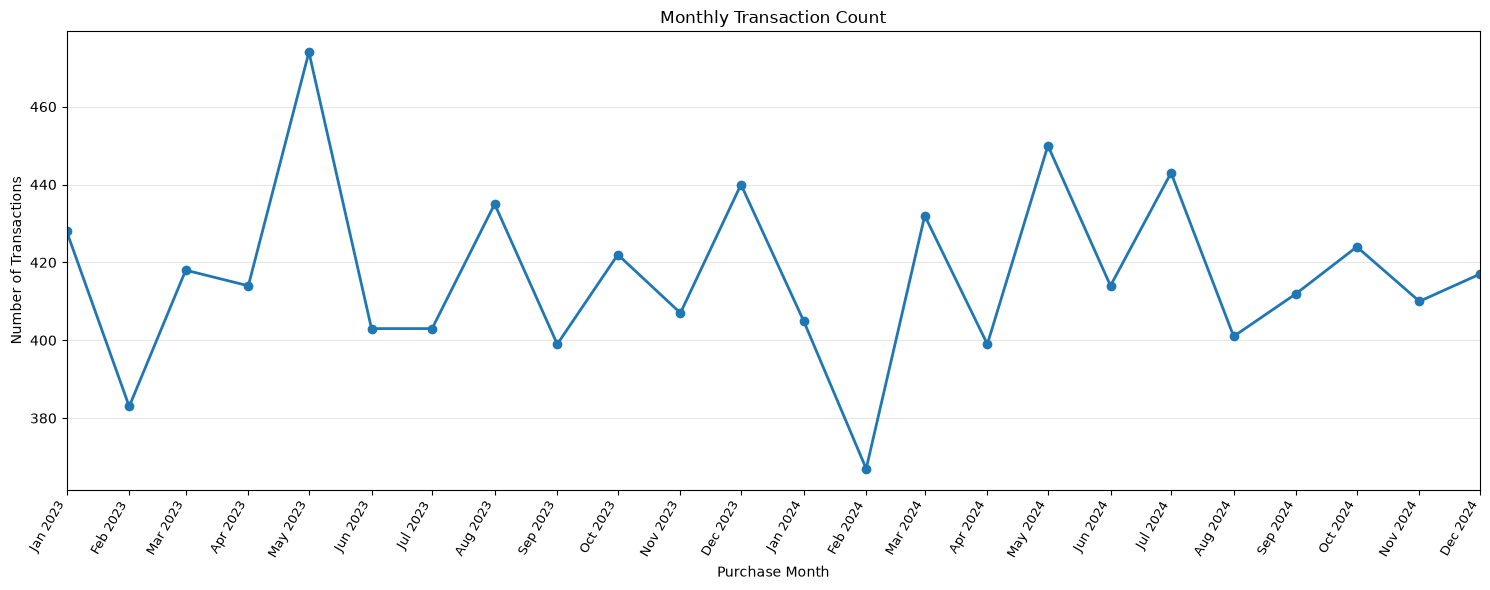

In [11]:
plt.figure(figsize=(15, 6))

plt.plot(
    monthly_activity["Month_Start"],
    monthly_activity["Transaction_Count"],
    marker="o",
    linewidth=2
)

plt.title("Monthly Transaction Count")
plt.xlabel("Purchase Month")
plt.ylabel("Number of Transactions")

# Display all 24 months
plt.xticks(
    monthly_activity["Month_Start"],
    monthly_activity["Month_Start"].dt.strftime("%b %Y"),
    rotation=60,
    ha="right",
    fontsize=9
)

plt.xlim(
    monthly_activity["Month_Start"].min(),
    monthly_activity["Month_Start"].max()
)

plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
save_figure(
    "h1_monthly_transaction_count.png"
)
plt.show()

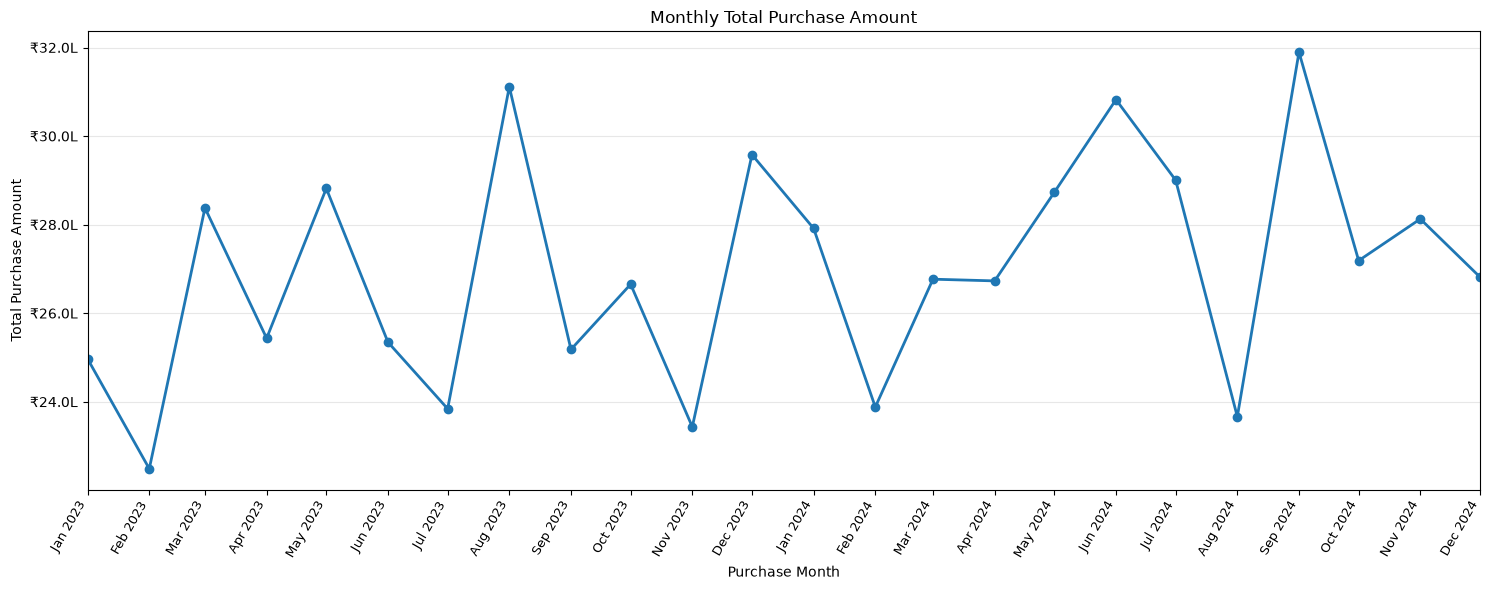

In [12]:
def format_lakhs(value, position):
    return f"₹{value / 100000:.1f}L"


plt.figure(figsize=(15, 6))

plt.plot(
    monthly_activity["Month_Start"],
    monthly_activity["Total_Purchase_Amount"],
    marker="o",
    linewidth=2
)

plt.title("Monthly Total Purchase Amount")
plt.xlabel("Purchase Month")
plt.ylabel("Total Purchase Amount")

plt.gca().yaxis.set_major_formatter(
    FuncFormatter(format_lakhs)
)

# Display all 24 months
plt.xticks(
    monthly_activity["Month_Start"],
    monthly_activity["Month_Start"].dt.strftime("%b %Y"),
    rotation=60,
    ha="right",
    fontsize=9
)

plt.xlim(
    monthly_activity["Month_Start"].min(),
    monthly_activity["Month_Start"].max()
)

plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
save_figure(
    "h1_monthly_total_purchase_amount.png"
)
plt.show()

In [13]:
highest_transaction_month = monthly_activity.loc[
    monthly_activity["Transaction_Count"].idxmax()
]

lowest_transaction_month = monthly_activity.loc[
    monthly_activity["Transaction_Count"].idxmin()
]

highest_purchase_month = monthly_activity.loc[
    monthly_activity["Total_Purchase_Amount"].idxmax()
]

lowest_purchase_month = monthly_activity.loc[
    monthly_activity["Total_Purchase_Amount"].idxmin()
]


print("Highest transaction-count month:")
print(
    highest_transaction_month[
        ["Year-Month", "Transaction_Count"]
    ]
)

print("\nLowest transaction-count month:")
print(
    lowest_transaction_month[
        ["Year-Month", "Transaction_Count"]
    ]
)

print("\nHighest purchase-amount month:")
print(
    highest_purchase_month[
        ["Year-Month", "Total_Purchase_Amount"]
    ]
)

print("\nLowest purchase-amount month:")
print(
    lowest_purchase_month[
        ["Year-Month", "Total_Purchase_Amount"]
    ]
)

Highest transaction-count month:
Year-Month           2023-05
Transaction_Count        474
Name: 4, dtype: object

Lowest transaction-count month:
Year-Month           2024-02
Transaction_Count        367
Name: 13, dtype: object

Highest purchase-amount month:
Year-Month               2024-09
Total_Purchase_Amount    3189510
Name: 20, dtype: object

Lowest purchase-amount month:
Year-Month               2023-02
Total_Purchase_Amount    2248695
Name: 1, dtype: object


### Monthly Activity Results

- Monthly transaction activity fluctuated throughout the two-year period without a consistent upward or downward trend.
- May 2023 recorded the highest transaction count, with 474 transactions.
- February 2024 recorded the lowest transaction count, with 367 transactions.
- September 2024 recorded the highest total purchase amount at ₹3,189,510, or approximately ₹31.90 lakh.
- February 2023 recorded the lowest total purchase amount at ₹2,248,695, or approximately ₹22.49 lakh.
- The month with the highest number of transactions was not the month with the highest total purchase amount.
- The month with the lowest number of transactions was also different from the month with the lowest total purchase amount.
- This indicates that monthly purchase value is influenced by both transaction volume and the average value of individual transactions.
- The monthly analysis provides overall context but does not directly determine whether promotional sales are associated with greater shopping activity.

### Analysis 1C: Promotional Sales versus Standard Days

This analysis directly compares transactions associated with festival or promotional sales against transactions made on standard days.

Average measures are used alongside totals because the two groups may contain different numbers of transactions.

The comparison includes:

- transaction count and transaction share;
- total and average purchase amount;
- median purchase amount;
- total and average quantity;
- average discount;
- return rate.

In [14]:
sale_event_counts = (
    df["Festival/Sale"]
    .value_counts()
    .rename_axis("Festival/Sale")
    .reset_index(name="Transaction Count")
)

sale_event_counts["Transaction Share (%)"] = (
    sale_event_counts["Transaction Count"]
    / len(df)
    * 100
)

display(sale_event_counts.round(2))

,Festival/Sale,Transaction Count,Transaction Share (%)
0,Standard Day,8835,88.35
1,In-Store Festival Offer,878,8.78
2,Diwali Sale,124,1.24
3,Independence Day Sale,62,0.62
4,Republic Day Sale,40,0.40
5,Big Billion Days,19,0.19
6,Amazon Great Indian Festival,16,0.16
7,Myntra End of Reason Sale,16,0.16
8,Nykaa Pink Friday,10,0.10


In [15]:
df["Promotion Group"] = df["Sale Purchase"].map({
    True: "Festival/Promotional Sale",
    False: "Standard Day"
})

print(df["Promotion Group"].value_counts())

Promotion Group
Standard Day                 8835
Festival/Promotional Sale    1165
Name: count, dtype: int64


In [16]:
promotion_summary = (
    df.groupby("Promotion Group", as_index=False, observed=True)
    .agg(
        Transaction_Count=("Transaction ID", "nunique"),
        Total_Purchase_Amount=("Purchase Amount (₹)", "sum"),
        Average_Purchase_Amount=("Purchase Amount (₹)", "mean"),
        Median_Purchase_Amount=("Purchase Amount (₹)", "median"),
        Total_Quantity=("Quantity", "sum"),
        Average_Quantity=("Quantity", "mean"),
        Average_Discount=("Discount (%)", "mean"),
        Return_Rate=("Returned", "mean")
    )
)

promotion_summary["Transaction Share (%)"] = (
    promotion_summary["Transaction_Count"]
    / promotion_summary["Transaction_Count"].sum()
    * 100
)

promotion_summary["Return Rate (%)"] = (
    promotion_summary["Return_Rate"] * 100
)

promotion_summary = promotion_summary.drop(columns="Return_Rate")

promotion_summary = promotion_summary[
    [
        "Promotion Group",
        "Transaction_Count",
        "Transaction Share (%)",
        "Total_Purchase_Amount",
        "Average_Purchase_Amount",
        "Median_Purchase_Amount",
        "Total_Quantity",
        "Average_Quantity",
        "Average_Discount",
        "Return Rate (%)"
    ]
]

display(promotion_summary.round(2))

,Promotion Group,Transaction_Count,Transaction Share (%),Total_Purchase_Amount,Average_Purchase_Amount,Median_Purchase_Amount,Total_Quantity,Average_Quantity,Average_Discount,Return Rate (%)
0,Festival/Promotional Sale,1165,11.65,7898475,"6,779.81","3,751.00",1652,1.42,22.45,16.14
1,Standard Day,8835,88.35,56778470,"6,426.54","3,457.00",12607,1.43,6.89,17.69


In [17]:
promotion_comparison = promotion_summary.set_index("Promotion Group")

standard_day = promotion_comparison.loc["Standard Day"]
promotional_sale = promotion_comparison.loc["Festival/Promotional Sale"]

purchase_amount_difference = (
    (
        promotional_sale["Average_Purchase_Amount"]
        - standard_day["Average_Purchase_Amount"]
    )
    / standard_day["Average_Purchase_Amount"]
    * 100
)

quantity_difference = (
    (
        promotional_sale["Average_Quantity"]
        - standard_day["Average_Quantity"]
    )
    / standard_day["Average_Quantity"]
    * 100
)

print(
    "Difference in average purchase amount:",
    f"{purchase_amount_difference:.2f}%"
)

print(
    "Difference in average quantity:",
    f"{quantity_difference:.2f}%"
)

Difference in average purchase amount: 5.50%
Difference in average quantity: -0.62%


### Promotional Sales Comparison Results

- Standard-day transactions represented 88.35% of all transactions, while festival and promotional-sale transactions represented 11.65%.
- The average purchase amount during festival and promotional sales was ₹6,779.81, compared with ₹6,426.54 on standard days.
- Therefore, the average purchase amount was approximately 5.50% higher during festival and promotional sales.
- The median purchase amount was also higher during promotional periods: ₹3,751 compared with ₹3,457 on standard days.
- The average quantity was nearly identical between the two groups. Promotional transactions averaged 1.42 items, while standard-day transactions averaged 1.43 items.
- The average quantity during promotional periods was approximately 0.62% lower, indicating that customers did not purchase more items per transaction.
- Promotional transactions had a lower return rate of 16.14%, compared with 17.69% on standard days.
- The average discount was substantially higher during promotional periods at 22.45%, compared with 6.89% on standard days.
- Because promotional transactions account for a much smaller share of the dataset, total purchase amounts should not be used alone to compare the two groups.
- The promotional group is dominated by the `In-Store Festival Offer`, which accounts for 878 of the 1,165 promotional transactions. Therefore, the combined promotional results are influenced mainly by this event.

### Analysis 1D: Visual Comparison of Promotional and Standard-Day Transactions

The comparison is visualized using average and median purchase amounts, followed by average quantity per transaction.

Purchase amount and quantity are shown in separate charts because they have different units and scales.

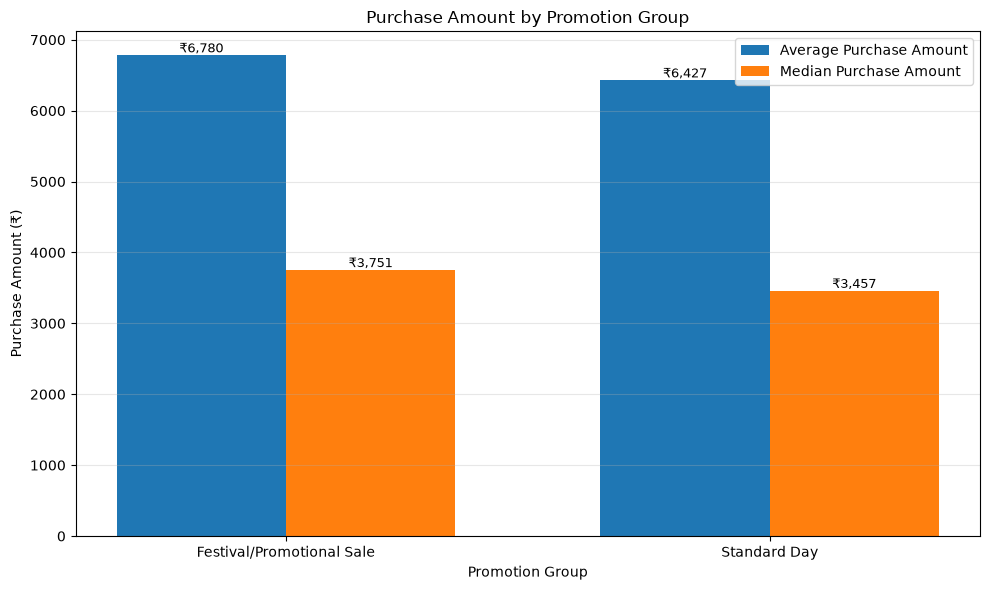

In [18]:
purchase_comparison = (
    promotion_summary[
        [
            "Promotion Group",
            "Average_Purchase_Amount",
            "Median_Purchase_Amount"
        ]
    ]
    .set_index("Promotion Group")
)

x_positions = range(len(purchase_comparison))
bar_width = 0.35

plt.figure(figsize=(10, 6))

average_bars = plt.bar(
    [x - bar_width / 2 for x in x_positions],
    purchase_comparison["Average_Purchase_Amount"],
    width=bar_width,
    label="Average Purchase Amount"
)

median_bars = plt.bar(
    [x + bar_width / 2 for x in x_positions],
    purchase_comparison["Median_Purchase_Amount"],
    width=bar_width,
    label="Median Purchase Amount"
)

plt.title("Purchase Amount by Promotion Group")
plt.xlabel("Promotion Group")
plt.ylabel("Purchase Amount (₹)")

plt.xticks(
    list(x_positions),
    purchase_comparison.index
)

plt.legend()
plt.grid(axis="y", alpha=0.3)

for bars in [average_bars, median_bars]:
    for bar in bars:
        value = bar.get_height()

        plt.text(
            bar.get_x() + bar.get_width() / 2,
            value,
            f"₹{value:,.0f}",
            ha="center",
            va="bottom",
            fontsize=9
        )

plt.tight_layout()
save_figure(
    "h1_purchase_amount_by_promotion_group.png"
)
plt.show()

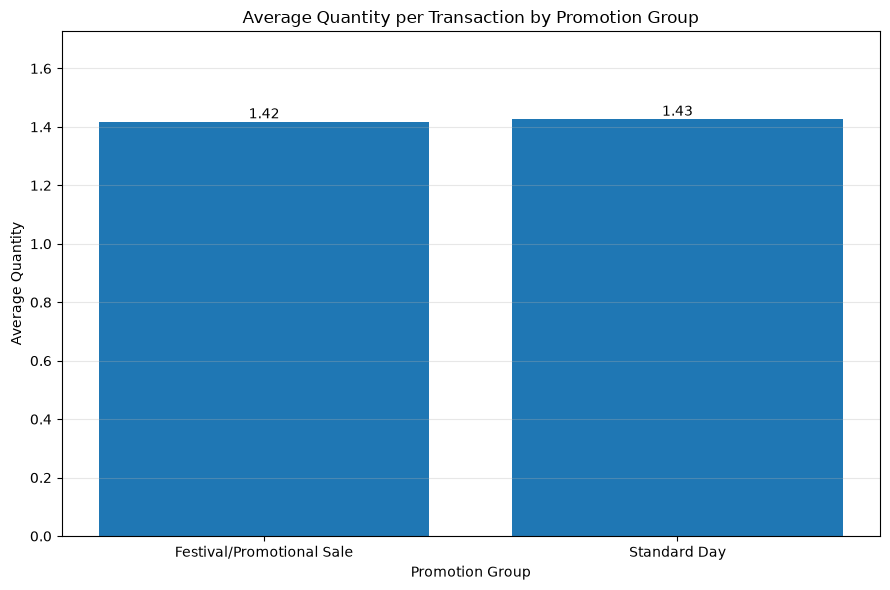

In [19]:
quantity_comparison = (
    promotion_summary[
        [
            "Promotion Group",
            "Average_Quantity"
        ]
    ]
    .set_index("Promotion Group")
)

plt.figure(figsize=(9, 6))

bars = plt.bar(
    quantity_comparison.index,
    quantity_comparison["Average_Quantity"]
)

plt.title("Average Quantity per Transaction by Promotion Group")
plt.xlabel("Promotion Group")
plt.ylabel("Average Quantity")

plt.ylim(
    0,
    quantity_comparison["Average_Quantity"].max() + 0.3
)

plt.grid(axis="y", alpha=0.3)

for bar in bars:
    value = bar.get_height()

    plt.text(
        bar.get_x() + bar.get_width() / 2,
        value,
        f"{value:.2f}",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
save_figure(
    "h1_avg_quantity_per_transaction_by_promotion_group.png"
)
plt.show()

### Visual Comparison Results

- Festival and promotional-sale transactions recorded a higher average purchase amount of approximately ₹6,780, compared with approximately ₹6,427 for standard-day transactions.
- This represents an increase of about 5.50% in the average purchase amount during promotional periods.
- The median purchase amount was also higher during promotional periods at ₹3,751, compared with ₹3,457 on standard days—an increase of approximately 8.50%.
- In both groups, the average purchase amount was considerably higher than the median. This suggests that the purchase-amount distribution may be right-skewed, with some high-value transactions increasing the average.
- Average quantity per transaction was almost identical between the groups: 1.42 items during promotional sales and 1.43 items on standard days.
- The quantity difference is too small to represent a meaningful increase in basket size. Promotional transactions actually recorded an approximately 0.62% lower average quantity.
- The visual evidence therefore indicates that promotional transactions were associated with higher purchase values, but not with customers purchasing more units per transaction.

## Hypothesis 1 Verdict

**Verdict: Partially supported**

The hypothesis predicted that festival and promotional-sale transactions would have both a higher purchase amount and a larger quantity than standard-day transactions.

The purchase-amount component was supported. Promotional transactions had a 5.50% higher average purchase amount and an approximately 8.50% higher median purchase amount.

The quantity component was not supported. Average quantity was almost unchanged and was slightly lower during promotional periods.

Within this synthetic dataset, promotions were therefore associated with higher-value transactions rather than larger baskets. This represents an association and does not establish that promotions caused customers to spend more.

## Hypothesis 2: Customer Groups and Shopping Contribution

### Question

Which customer groups contribute the most customers, transactions, and purchase amount?

### Hypothesis

Customers in the younger-to-middle age groups, particularly those aged 25–44, may form the largest customer base and contribute the highest transaction count and purchase amount.

Female customers may contribute more transactions and purchase amount than male customers.

Subscription rates may be higher among younger and middle-aged customers, while subscribed customers may complete more transactions and generate a higher purchase amount per customer than non-subscribed customers.

### Measures

The hypothesis will be examined using:

- number and share of unique customers;
- transaction count and transaction share;
- total purchase amount and purchase-amount share;
- transactions per customer;
- purchase amount per customer;
- average transaction value;
- average quantity per transaction;
- subscription rate.

The measures will be compared across:

- age groups;
- gender;
- subscription status;
- purchase-frequency groups;
- locations, where useful.

### Visual Analysis

The analysis will first examine each customer characteristic separately.

Targeted comparisons will then evaluate:

- subscription rate across age groups;
- subscription rate across genders;
- shopping activity of subscribed and non-subscribed customers.

### Interpretation Rule

Groups with more customers will naturally tend to produce more transactions and purchase amount. Therefore, total contribution measures must be interpreted alongside per-customer averages.

### Analysis 2A: Customer-Profile Consistency

The transaction dataset contains repeated Customer IDs because individual customers may have completed multiple purchases.

Before creating one record per customer, the analysis checks whether customer characteristics remain consistent across their transactions.

In [20]:
profile_columns = [
    "Age Group",
    "Gender",
    "Location",
    "Subscription Status",
    "Frequency of Purchases",
    "Subscribed"
]

profile_consistency = (
    df.groupby("Customer ID")[profile_columns]
      .nunique(dropna=False)
      .gt(1)
      .sum()
      .rename("Customers with Multiple Values")
      .to_frame()
)

display(profile_consistency)

,Customers with Multiple Values
Age Group,0
Gender,0
Location,0
Subscription Status,0
Frequency of Purchases,0
Subscribed,0


In [21]:
critical_profile_columns = [
    "Age Group",
    "Gender",
    "Subscription Status",
    "Subscribed"
]

inconsistent_critical_profiles = (
    profile_consistency
    .loc[critical_profile_columns, "Customers with Multiple Values"]
)

if inconsistent_critical_profiles.sum() == 0:
    print("Critical customer-profile variables are consistent.")
else:
    print("Warning: Some customers have inconsistent profile values.")
    display(
        inconsistent_critical_profiles[
            inconsistent_critical_profiles > 0
        ]
    )

Critical customer-profile variables are consistent.


#### Customer-Profile Consistency Results

- All 3,291 customers have consistent age-group, gender, location, subscription-status, and purchase-frequency values across their transactions.
- No Customer ID appears under multiple values for any of the inspected profile variables.
- Customer profiles can therefore be safely reduced to one row per customer and combined with their aggregated shopping activity.

### Analysis 2B: Customer-Level Dataset

A customer-level dataset is created by combining each customer's profile with their total shopping activity.

This prevents customers with many transactions from being counted repeatedly when measuring customer composition and subscription rates.

In [22]:
customer_profiles = (
    df.sort_values("Purchase Date")
      .drop_duplicates(
          subset="Customer ID",
          keep="last"
      )
      [
          [
              "Customer ID",
              "Age Group",
              "Gender",
              "Location",
              "Subscription Status",
              "Frequency of Purchases",
              "Subscribed"
          ]
      ]
      .copy()
)

print(
    "Customer profiles:",
    f"{customer_profiles.shape[0]:,}"
)

display(customer_profiles.head())

Customer profiles: 3,291


,Customer ID,Age Group,Gender,Location,Subscription Status,Frequency of Purchases,Subscribed
5594,CUST001895,18-24,Male,Chennai,Yes,Fortnightly,True
9250,CUST001452,55-64,Male,Ahmedabad,No,Fortnightly,False
5169,CUST002615,55-64,Female,Chandigarh,No,Monthly,False
3358,CUST000976,45-54,Female,Kochi,No,Fortnightly,False
9267,CUST000300,25-34,Male,Ahmedabad,Yes,Fortnightly,True


In [23]:
customer_metrics = (
    df.groupby("Customer ID", as_index=False)
      .agg(
          Transaction_Count=(
              "Transaction ID",
              "nunique"
          ),
          Total_Purchase_Amount=(
              "Purchase Amount (₹)",
              "sum"
          ),
          Total_Quantity=(
              "Quantity",
              "sum"
          )
      )
)

customer_metrics["Average_Transaction_Value"] = (
    customer_metrics["Total_Purchase_Amount"]
    / customer_metrics["Transaction_Count"]
)

customer_metrics["Average_Quantity_Per_Transaction"] = (
    customer_metrics["Total_Quantity"]
    / customer_metrics["Transaction_Count"]
)

display(customer_metrics.head())

,Customer ID,Transaction_Count,Total_Purchase_Amount,Total_Quantity,Average_Transaction_Value,Average_Quantity_Per_Transaction
0,CUST000001,2,12131,4,"6,065.50",2.00
1,CUST000002,2,28663,4,"14,331.50",2.00
2,CUST000005,2,2389,3,"1,194.50",1.50
3,CUST000006,3,10945,8,"3,648.33",2.67
4,CUST000008,6,55548,9,"9,258.00",1.50


In [24]:
customer_analysis = customer_profiles.merge(
    customer_metrics,
    on="Customer ID",
    how="left",
    validate="one_to_one"
)

print(
    "Customer-level dataset:",
    f"{customer_analysis.shape[0]:,} rows × "
    f"{customer_analysis.shape[1]} columns"
)

print(
    "Unique Customer IDs:",
    customer_analysis["Customer ID"].nunique()
)

print(
    "Missing values:",
    customer_analysis.isna().sum().sum()
)

display(customer_analysis.head())

Customer-level dataset: 3,291 rows × 12 columns
Unique Customer IDs: 3291
Missing values: 0


,Customer ID,Age Group,Gender,Location,Subscription Status,Frequency of Purchases,Subscribed,Transaction_Count,Total_Purchase_Amount,Total_Quantity,Average_Transaction_Value,Average_Quantity_Per_Transaction
0,CUST001895,18-24,Male,Chennai,Yes,Fortnightly,True,1,7545,2,"7,545.00",2.00
1,CUST001452,55-64,Male,Ahmedabad,No,Fortnightly,False,1,1153,1,"1,153.00",1.00
2,CUST002615,55-64,Female,Chandigarh,No,Monthly,False,1,13960,1,"13,960.00",1.00
3,CUST000976,45-54,Female,Kochi,No,Fortnightly,False,1,7218,2,"7,218.00",2.00
4,CUST000300,25-34,Male,Ahmedabad,Yes,Fortnightly,True,1,4579,1,"4,579.00",1.00


In [25]:
print(
    "Transactions in customer table:",
    customer_analysis["Transaction_Count"].sum()
)

print(
    "Transactions in original dataset:",
    df["Transaction ID"].nunique()
)

print(
    "\nPurchase amount in customer table:",
    customer_analysis["Total_Purchase_Amount"].sum()
)

print(
    "Purchase amount in original dataset:",
    df["Purchase Amount (₹)"].sum()
)

Transactions in customer table: 10000
Transactions in original dataset: 10000

Purchase amount in customer table: 64676945
Purchase amount in original dataset: 64676945


### Analysis 2C: Customer-Group Summary Function

A reusable function calculates both total contribution and per-customer shopping intensity for each customer characteristic.

In [26]:
def summarize_customer_dimension(data, group_column):
    summary = (
        data.groupby(
            group_column,
            as_index=False,
            observed=True
        )
        .agg(
            Unique_Customers=(
                "Customer ID",
                "nunique"
            ),
            Transaction_Count=(
                "Transaction_Count",
                "sum"
            ),
            Total_Purchase_Amount=(
                "Total_Purchase_Amount",
                "sum"
            ),
            Total_Quantity=(
                "Total_Quantity",
                "sum"
            ),
            Subscribed_Customers=(
                "Subscribed",
                "sum"
            )
        )
    )

    summary["Customer Share (%)"] = (
        summary["Unique_Customers"]
        / data["Customer ID"].nunique()
        * 100
    )

    summary["Transaction Share (%)"] = (
        summary["Transaction_Count"]
        / data["Transaction_Count"].sum()
        * 100
    )

    summary["Purchase Amount Share (%)"] = (
        summary["Total_Purchase_Amount"]
        / data["Total_Purchase_Amount"].sum()
        * 100
    )

    summary["Transactions per Customer"] = (
        summary["Transaction_Count"]
        / summary["Unique_Customers"]
    )

    summary["Purchase Amount per Customer"] = (
        summary["Total_Purchase_Amount"]
        / summary["Unique_Customers"]
    )

    summary["Average Transaction Value"] = (
        summary["Total_Purchase_Amount"]
        / summary["Transaction_Count"]
    )

    summary["Average Quantity per Transaction"] = (
        summary["Total_Quantity"]
        / summary["Transaction_Count"]
    )

    summary["Subscription Rate (%)"] = (
        summary["Subscribed_Customers"]
        / summary["Unique_Customers"]
        * 100
    )

    return summary[
        [
            group_column,
            "Unique_Customers",
            "Customer Share (%)",
            "Transaction_Count",
            "Transaction Share (%)",
            "Total_Purchase_Amount",
            "Purchase Amount Share (%)",
            "Transactions per Customer",
            "Purchase Amount per Customer",
            "Average Transaction Value",
            "Average Quantity per Transaction",
            "Subscribed_Customers",
            "Subscription Rate (%)"
        ]
    ]

### Analysis 2D: Customer Contribution by Age Group

Age groups are compared using customer representation, total contribution, per-customer activity, and subscription rate.

In [27]:
age_group_summary = summarize_customer_dimension(
    customer_analysis,
    "Age Group"
)

display(age_group_summary.round(2))

,Age Group,Unique_Customers,Customer Share (%),Transaction_Count,Transaction Share (%),Total_Purchase_Amount,Purchase Amount Share (%),Transactions per Customer,Purchase Amount per Customer,Average Transaction Value,Average Quantity per Transaction,Subscribed_Customers,Subscription Rate (%)
0,18-24,474,14.40,1430,14.30,9236857,14.28,3.02,"19,487.04","6,459.34",1.45,141,29.75
1,25-34,699,21.24,2101,21.01,13705072,21.19,3.01,"19,606.68","6,523.12",1.43,201,28.76
2,35-44,708,21.51,2142,21.42,14045585,21.72,3.03,"19,838.40","6,557.23",1.44,206,29.10
3,45-54,725,22.03,2146,21.46,13168902,20.36,2.96,"18,164.00","6,136.49",1.40,229,31.59
4,55-64,685,20.81,2181,21.81,14520529,22.45,3.18,"21,197.85","6,657.74",1.41,194,28.32


In [28]:
largest_age_customer_group = age_group_summary.loc[
    age_group_summary["Unique_Customers"].idxmax()
]

highest_age_transaction_group = age_group_summary.loc[
    age_group_summary["Transaction_Count"].idxmax()
]

highest_age_purchase_group = age_group_summary.loc[
    age_group_summary["Total_Purchase_Amount"].idxmax()
]

highest_age_subscription_group = age_group_summary.loc[
    age_group_summary["Subscription Rate (%)"].idxmax()
]

print("Largest age group by unique customers:")
print(
    largest_age_customer_group[
        [
            "Age Group",
            "Unique_Customers",
            "Customer Share (%)"
        ]
    ]
)

print("\nHighest age group by transaction count:")
print(
    highest_age_transaction_group[
        [
            "Age Group",
            "Transaction_Count",
            "Transaction Share (%)"
        ]
    ]
)

print("\nHighest age group by purchase amount:")
print(
    highest_age_purchase_group[
        [
            "Age Group",
            "Total_Purchase_Amount",
            "Purchase Amount Share (%)"
        ]
    ]
)

print("\nHighest subscription rate by age group:")
print(
    highest_age_subscription_group[
        [
            "Age Group",
            "Subscription Rate (%)"
        ]
    ]
)

Largest age group by unique customers:
Age Group             45-54
Unique_Customers        725
Customer Share (%)    22.03
Name: 3, dtype: object

Highest age group by transaction count:
Age Group                55-64
Transaction_Count         2181
Transaction Share (%)    21.81
Name: 4, dtype: object

Highest age group by purchase amount:
Age Group                       55-64
Total_Purchase_Amount        14520529
Purchase Amount Share (%)       22.45
Name: 4, dtype: object

Highest subscription rate by age group:
Age Group                45-54
Subscription Rate (%)    31.59
Name: 3, dtype: object


#### Age-Group Results

- Customers aged 45–54 formed the largest individual age group, with 725 customers representing 22.03% of the customer base.
- Customers aged 55–64 recorded the highest transaction count at 2,181 transactions and contributed the highest total purchase amount of ₹14,520,529.
- The 55–64 group also recorded the highest shopping intensity, with 3.18 transactions and ₹21,197.85 in purchase amount per customer.
- Its average transaction value of ₹6,657.74 was the highest among the age groups.
- Although customers aged 45–54 formed the largest customer group, their purchase amount per customer and average transaction value were the lowest among the observed age groups.
- Customers aged 45–54 had the highest subscription rate at 31.59%. Therefore, the expectation that younger customers would have the highest subscription rate was not supported by this comparison.
- The 18–24 group was the smallest observed age group and contributed the lowest transaction count and total purchase amount.
- Taken together, the 25–34 and 35–44 groups represented 42.75% of customers, 42.43% of transactions, and 42.91% of purchase amount. However, this combines two separate age categories and should not be compared directly with one individual ten-year group.
- No customers were observed in the 65+ category within this dataset.

### Analysis 2E: Customer Contribution by Gender

Gender groups are compared using customer representation, transaction activity, purchase amount, and subscription rate.

In [29]:
gender_summary = summarize_customer_dimension(
    customer_analysis,
    "Gender"
)

display(gender_summary.round(2))

,Gender,Unique_Customers,Customer Share (%),Transaction_Count,Transaction Share (%),Total_Purchase_Amount,Purchase Amount Share (%),Transactions per Customer,Purchase Amount per Customer,Average Transaction Value,Average Quantity per Transaction,Subscribed_Customers,Subscription Rate (%)
0,Female,1601,48.65,4839,48.39,31773117,49.13,3.02,"19,845.79","6,566.05",1.44,471,29.42
1,Male,1576,47.89,4790,47.90,30356410,46.94,3.04,"19,261.68","6,337.46",1.41,468,29.70
2,Other,114,3.46,371,3.71,2547418,3.94,3.25,"22,345.77","6,866.36",1.36,32,28.07


In [30]:
largest_gender_customer_group = gender_summary.loc[
    gender_summary["Unique_Customers"].idxmax()
]

highest_gender_transaction_group = gender_summary.loc[
    gender_summary["Transaction_Count"].idxmax()
]

highest_gender_purchase_group = gender_summary.loc[
    gender_summary["Total_Purchase_Amount"].idxmax()
]

highest_gender_subscription_group = gender_summary.loc[
    gender_summary["Subscription Rate (%)"].idxmax()
]

print("Largest gender group by unique customers:")
print(
    largest_gender_customer_group[
        [
            "Gender",
            "Unique_Customers",
            "Customer Share (%)"
        ]
    ]
)

print("\nHighest gender group by transaction count:")
print(
    highest_gender_transaction_group[
        [
            "Gender",
            "Transaction_Count",
            "Transaction Share (%)"
        ]
    ]
)

print("\nHighest gender group by purchase amount:")
print(
    highest_gender_purchase_group[
        [
            "Gender",
            "Total_Purchase_Amount",
            "Purchase Amount Share (%)"
        ]
    ]
)

print("\nHighest subscription rate by gender:")
print(
    highest_gender_subscription_group[
        [
            "Gender",
            "Subscription Rate (%)"
        ]
    ]
)

Largest gender group by unique customers:
Gender                Female
Unique_Customers        1601
Customer Share (%)     48.65
Name: 0, dtype: object

Highest gender group by transaction count:
Gender                   Female
Transaction_Count          4839
Transaction Share (%)     48.39
Name: 0, dtype: object

Highest gender group by purchase amount:
Gender                         Female
Total_Purchase_Amount        31773117
Purchase Amount Share (%)       49.13
Name: 0, dtype: object

Highest subscription rate by gender:
Gender                   Male
Subscription Rate (%)   29.70
Name: 1, dtype: object


#### Gender Results

- Female customers formed the largest gender group, with 1,601 customers, compared with 1,576 male customers.
- Female customers also contributed the highest transaction count and total purchase amount.
- However, the differences between female and male customer representation and transaction contribution were relatively small.
- Female customers recorded a higher purchase amount per customer and a higher average transaction value than male customers.
- Male customers recorded slightly more transactions per customer: 3.04 compared with 3.02 for female customers.
- Male customers also had a marginally higher subscription rate of 29.70%, compared with 29.42% for female customers. This difference is too small to indicate a substantial gender-based subscription pattern.
- Customers in the Other gender category recorded the highest transactions per customer, purchase amount per customer, and average transaction value.
- However, the Other category represented only 3.46% of customers. Its high per-customer figures should therefore not be interpreted as the largest overall contribution.

### Analysis 2F: Shopping Contribution by Subscription Status

Subscribed and non-subscribed customers are compared to determine whether subscription status is associated with greater shopping activity or spending per customer.

In [31]:
subscription_summary = summarize_customer_dimension(
    customer_analysis,
    "Subscription Status"
)

subscription_summary_display = subscription_summary[
    [
        "Subscription Status",
        "Unique_Customers",
        "Customer Share (%)",
        "Transaction_Count",
        "Transaction Share (%)",
        "Total_Purchase_Amount",
        "Purchase Amount Share (%)",
        "Transactions per Customer",
        "Purchase Amount per Customer",
        "Average Transaction Value",
        "Average Quantity per Transaction"
    ]
]

display(subscription_summary_display.round(2))

,Subscription Status,Unique_Customers,Customer Share (%),Transaction_Count,Transaction Share (%),Total_Purchase_Amount,Purchase Amount Share (%),Transactions per Customer,Purchase Amount per Customer,Average Transaction Value,Average Quantity per Transaction
0,No,2320,70.50,7043,70.43,45854798,70.90,3.04,"19,765.00","6,510.69",1.42
1,Yes,971,29.50,2957,29.57,18822147,29.10,3.05,"19,384.29","6,365.28",1.43


In [32]:
subscription_comparison = (
    subscription_summary
    .set_index("Subscription Status")
)

subscribed_group = subscription_comparison.loc["Yes"]
non_subscribed_group = subscription_comparison.loc["No"]

transaction_difference = (
    (
        subscribed_group["Transactions per Customer"]
        - non_subscribed_group["Transactions per Customer"]
    )
    / non_subscribed_group["Transactions per Customer"]
    * 100
)

customer_spending_difference = (
    (
        subscribed_group["Purchase Amount per Customer"]
        - non_subscribed_group["Purchase Amount per Customer"]
    )
    / non_subscribed_group["Purchase Amount per Customer"]
    * 100
)

average_transaction_difference = (
    (
        subscribed_group["Average Transaction Value"]
        - non_subscribed_group["Average Transaction Value"]
    )
    / non_subscribed_group["Average Transaction Value"]
    * 100
)

print(
    "Difference in transactions per customer:",
    f"{transaction_difference:.2f}%"
)

print(
    "Difference in purchase amount per customer:",
    f"{customer_spending_difference:.2f}%"
)

print(
    "Difference in average transaction value:",
    f"{average_transaction_difference:.2f}%"
)

Difference in transactions per customer: 0.31%
Difference in purchase amount per customer: -1.93%
Difference in average transaction value: -2.23%


#### Subscription-Status Results

- Non-subscribed customers represented 70.50% of the customer base and consequently contributed approximately 70% of transactions and purchase amount.
- The greater total contribution from non-subscribed customers mainly reflects their larger population rather than stronger shopping behaviour per customer.
- Subscribed customers completed only 0.31% more transactions per customer than non-subscribed customers.
- Despite this small transaction difference, subscribed customers generated 1.93% less purchase amount per customer.
- Their average transaction value was also 2.23% lower than that of non-subscribed customers.
- Average quantity per transaction was almost identical between subscribed and non-subscribed customers.
- Subscription status was therefore not associated with meaningfully greater transaction activity or spending per customer within this synthetic dataset.

### Analysis 2G: Customer Contribution by Purchase Frequency

Purchase-frequency groups are examined to determine whether customers reporting more frequent purchasing behaviour also contribute more transactions and purchase amount.

In [33]:
print(
    customer_analysis["Frequency of Purchases"]
    .value_counts(dropna=False)
)

Frequency of Purchases
Rarely         700
Fortnightly    670
Weekly         659
Monthly        639
Quarterly      623
Name: count, dtype: int64


In [34]:
frequency_summary = summarize_customer_dimension(
    customer_analysis,
    "Frequency of Purchases"
)

display(
    frequency_summary
    .sort_values(
        "Transactions per Customer",
        ascending=False
    )
    .round(2)
)

,Frequency of Purchases,Unique_Customers,Customer Share (%),Transaction_Count,Transaction Share (%),Total_Purchase_Amount,Purchase Amount Share (%),Transactions per Customer,Purchase Amount per Customer,Average Transaction Value,Average Quantity per Transaction,Subscribed_Customers,Subscription Rate (%)
4,Weekly,659,20.02,2034,20.34,12971315,20.06,3.09,"19,683.33","6,377.24",1.43,190,28.83
2,Quarterly,623,18.93,1918,19.18,12010211,18.57,3.08,"19,278.03","6,261.84",1.44,205,32.91
3,Rarely,700,21.27,2142,21.42,13856952,21.42,3.06,"19,795.65","6,469.17",1.44,194,27.71
0,Fortnightly,670,20.36,2006,20.06,13245355,20.48,2.99,"19,769.19","6,602.87",1.42,198,29.55
1,Monthly,639,19.42,1900,19.00,12593112,19.47,2.97,"19,707.53","6,627.95",1.40,184,28.79


#### Purchase-Frequency Results

- Customer representation was relatively balanced across all five purchase-frequency categories, ranging from 18.93% to 21.27% of customers.
- Customers labelled as Rarely formed the largest group and therefore contributed the highest transaction count and total purchase amount.
- Weekly customers recorded the highest observed transaction rate at 3.09 transactions per customer.
- Monthly customers recorded the lowest rate at 2.97 transactions per customer.
- The difference between the highest and lowest groups was only 0.12 transactions per customer, indicating that observed transaction activity was very similar across frequency categories.
- The reported purchase-frequency labels did not show a clear ordered relationship with the actual number of transactions recorded in the dataset.
- For example, customers labelled Rarely completed slightly more transactions per customer than customers labelled Monthly or Fortnightly.
- This suggests that the frequency variable should be treated as a provided customer category rather than an exact measure of transaction cadence across the two-year dataset.
- Quarterly customers recorded the highest subscription rate at 32.91%, while Rarely customers recorded the lowest rate at 27.71%.
- Average transaction value and purchase amount per customer varied only moderately across the frequency groups.

### Analysis 2H: Visual Comparison of Customer Groups

The visual analysis focuses on the main findings identified in the customer-group summaries:

1. contribution by age group;
2. subscription rate by age group;
3. contribution by gender;
4. differences between subscribed and non-subscribed customers;
5. observed activity across purchase-frequency groups.

Contribution shares are used instead of raw totals where appropriate so that customers, transactions, and purchase amount can be compared on the same scale.

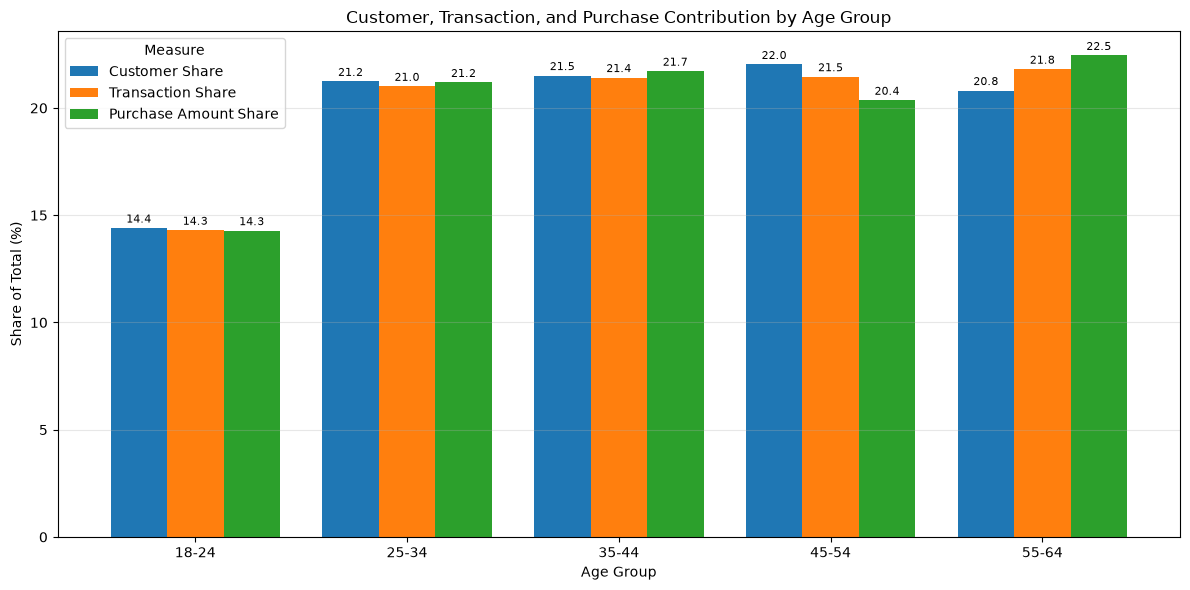

In [35]:
age_contribution_plot = (
    age_group_summary
    .set_index("Age Group")
    [
        [
            "Customer Share (%)",
            "Transaction Share (%)",
            "Purchase Amount Share (%)"
        ]
    ]
    .rename(
        columns={
            "Customer Share (%)": "Customer Share",
            "Transaction Share (%)": "Transaction Share",
            "Purchase Amount Share (%)": "Purchase Amount Share"
        }
    )
)

ax = age_contribution_plot.plot(
    kind="bar",
    figsize=(12, 6),
    width=0.8
)

plt.title("Customer, Transaction, and Purchase Contribution by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Share of Total (%)")
plt.xticks(rotation=0)
plt.grid(axis="y", alpha=0.3)
plt.legend(title="Measure")

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.1f",
        padding=2,
        fontsize=8
    )

plt.tight_layout()
save_figure(
    "h2_customer_transaction_and_purchase_contribution_by_age_group.png"
)
plt.show()

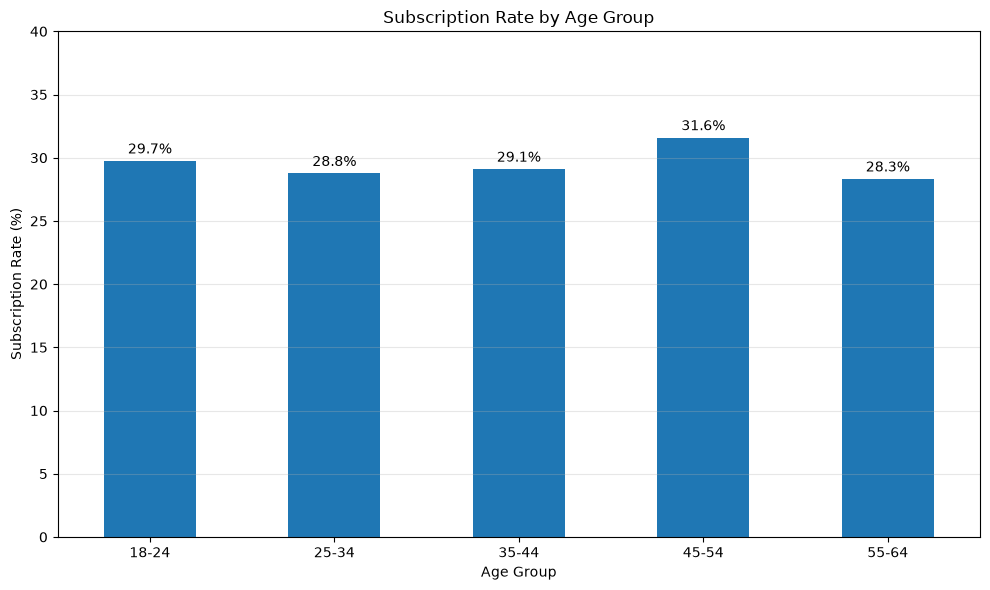

In [36]:
age_subscription_plot = (
    age_group_summary
    .set_index("Age Group")["Subscription Rate (%)"]
)

ax = age_subscription_plot.plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Subscription Rate by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Subscription Rate (%)")
plt.xticks(rotation=0)
plt.ylim(0, 40)
plt.grid(axis="y", alpha=0.3)

ax.bar_label(
    ax.containers[0],
    fmt="%.1f%%",
    padding=3
)

plt.tight_layout()
save_figure(
    "h2_subscription_rate_by_age_group.png"
)
plt.show()

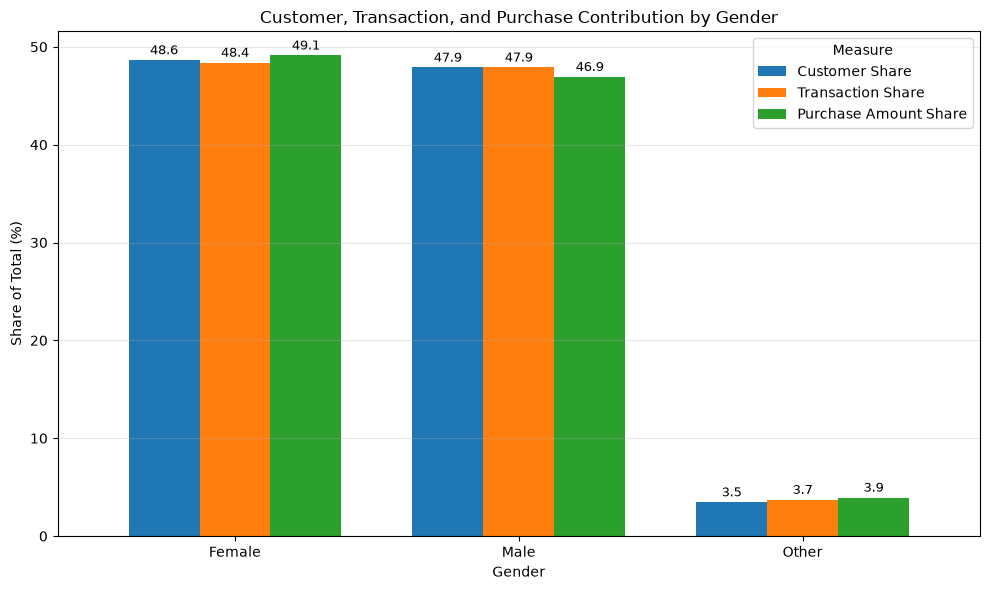

In [37]:
gender_contribution_plot = (
    gender_summary
    .set_index("Gender")
    [
        [
            "Customer Share (%)",
            "Transaction Share (%)",
            "Purchase Amount Share (%)"
        ]
    ]
    .rename(
        columns={
            "Customer Share (%)": "Customer Share",
            "Transaction Share (%)": "Transaction Share",
            "Purchase Amount Share (%)": "Purchase Amount Share"
        }
    )
)

ax = gender_contribution_plot.plot(
    kind="bar",
    figsize=(10, 6),
    width=0.75
)

plt.title("Customer, Transaction, and Purchase Contribution by Gender")
plt.xlabel("Gender")
plt.ylabel("Share of Total (%)")
plt.xticks(rotation=0)
plt.grid(axis="y", alpha=0.3)
plt.legend(title="Measure")

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.1f",
        padding=2,
        fontsize=9
    )

plt.tight_layout()
save_figure(
    "h2_customer_transaction_and_purchase_contribution_by_gender.png"
)
plt.show()

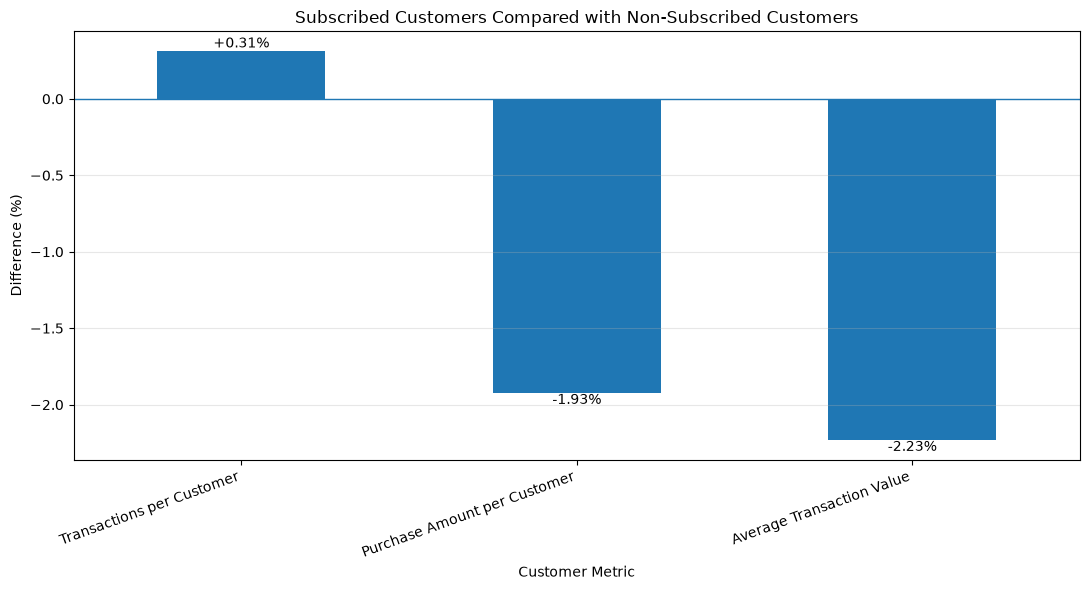

In [38]:
subscription_difference_plot = pd.Series(
    {
        "Transactions per Customer": transaction_difference,
        "Purchase Amount per Customer": customer_spending_difference,
        "Average Transaction Value": average_transaction_difference
    }
)

ax = subscription_difference_plot.plot(
    kind="bar",
    figsize=(11, 6)
)

plt.title(
    "Subscribed Customers Compared with Non-Subscribed Customers"
)
plt.xlabel("Customer Metric")
plt.ylabel("Difference (%)")
plt.xticks(rotation=20, ha="right")
plt.axhline(0, linewidth=1)
plt.grid(axis="y", alpha=0.3)

for bar in ax.patches:
    value = bar.get_height()

    plt.text(
        bar.get_x() + bar.get_width() / 2,
        value,
        f"{value:+.2f}%",
        ha="center",
        va="bottom" if value >= 0 else "top"
    )

plt.tight_layout()
save_figure(
    "h2_subscribed_customer_compared_with_non_subscribed_customers.png"
)
plt.show()

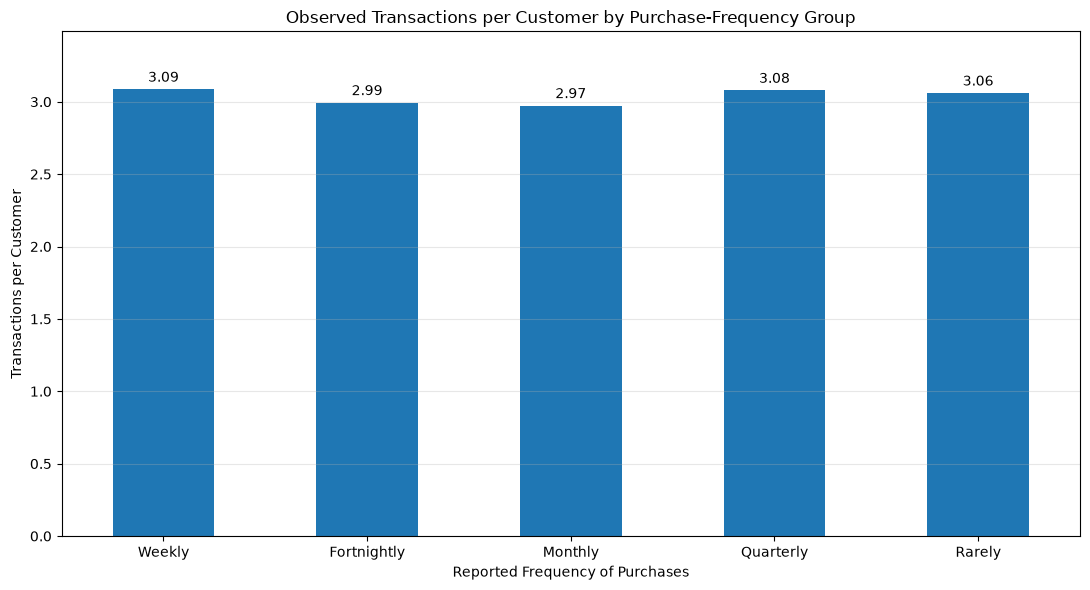

In [39]:
frequency_order = [
    "Weekly",
    "Fortnightly",
    "Monthly",
    "Quarterly",
    "Rarely"
]

frequency_activity_plot = (
    frequency_summary
    .set_index("Frequency of Purchases")
    .reindex(frequency_order)
)

ax = frequency_activity_plot[
    "Transactions per Customer"
].plot(
    kind="bar",
    figsize=(11, 6)
)

plt.title(
    "Observed Transactions per Customer by Purchase-Frequency Group"
)
plt.xlabel("Reported Frequency of Purchases")
plt.ylabel("Transactions per Customer")
plt.xticks(rotation=0)

plt.ylim(
    0,
    frequency_activity_plot[
        "Transactions per Customer"
    ].max() + 0.4
)

plt.grid(axis="y", alpha=0.3)

ax.bar_label(
    ax.containers[0],
    fmt="%.2f",
    padding=3
)

plt.tight_layout()
save_figure(
    "h2_observed_transactions_per_customer_by_purchase_frequency_group.png"
)
plt.show()

### Visual Comparison Results

**Age-group contribution**

- Customer, transaction, and purchase-amount shares were broadly similar for most age groups between 25 and 64, indicating that no single age group overwhelmingly dominated the customer base.
- The 45–54 group had the largest customer share, but its purchase-amount share was noticeably lower than its customer share.
- In contrast, the 55–64 group had a smaller customer share but the highest transaction and purchase-amount shares, indicating stronger shopping contribution relative to its group size.
- Customers aged 18–24 contributed the smallest shares across all three measures, largely reflecting their smaller representation in the dataset.

**Age-group subscriptions**

- Subscription rates were relatively close across all age groups, with no clear increase or decrease as age changed.
- The highest subscription rate occurred among customers aged 45–54 rather than among the youngest groups.

**Gender contribution**

- Female and male customers contributed almost equal shares of customers and transactions.
- Female customers contributed a slightly larger share of purchase amount than their customer share, while the opposite pattern appeared among male customers.
- The Other gender category contributed only a small share of customers, transactions, and purchase amount, despite recording relatively strong per-customer measures in the summary table.

**Subscription performance**

- Subscribed customers completed almost the same number of transactions per customer as non-subscribed customers.
- However, subscribed customers recorded slightly lower purchase amount per customer and average transaction value.

**Reported purchase frequency**

- The purchase-frequency chart was nearly flat, showing little difference in observed transactions per customer across the reported frequency categories.
- The reported frequency labels therefore did not correspond closely with actual transaction activity recorded during the dataset period.

## Hypothesis 2 Verdict

**Verdict: Mostly not supported**

The hypothesis expected customers aged 25–44 to form the strongest customer group and contribute the highest transaction count and purchase amount.

This expectation was not supported at the individual age-group level. Customers aged 45–54 formed the largest customer group, while customers aged 55–64 recorded the highest transaction count and purchase amount. The 55–64 group also showed the strongest shopping contribution relative to its number of customers.

The expectation that female customers would contribute more transactions and purchase amount was supported, but only slightly. Female and male customer contributions were generally close.

The expectation that younger and middle-aged customers would have the highest subscription rates was not supported. Subscription rates were similar across age groups, and the highest rate was observed among customers aged 45–54.

The expectation that subscribed customers would shop more frequently and spend more was also not supported. Subscribed and non-subscribed customers completed nearly the same number of transactions per customer, while subscribed customers recorded slightly lower spending measures.

Within this synthetic dataset, customer contribution was therefore relatively balanced across most demographic groups. The clearest distinction was that customers aged 55–64 generated greater shopping value relative to their customer-group size.

## Hypothesis 3: Product Performance

### Question

Which product categories, items, and brands perform most strongly in transaction volume, quantity purchased, and purchase amount?

### Hypothesis

Clothing and footwear may contribute more transactions, quantity, and purchase amount than accessories.

Clothing and footwear may also have higher return rates because product fit and sizing can influence customer decisions after purchase, while accessories may record lower return rates.

Popular or higher-value brands may generate greater total purchase amounts and average transaction values. However, the products with the highest commercial performance may not necessarily have the highest ratings or lowest return rates.

### Measures

Commercial performance will be evaluated using:

- transaction count;
- transaction share;
- total quantity purchased;
- quantity share;
- total purchase amount;
- purchase-amount share;
- average transaction value;
- average quantity per transaction;
- purchase amount per unit.

Customer outcomes will be evaluated using:

- average review rating;
- return rate.

The measures will be compared across:

- product categories;
- individual items;
- brands.

### Visual Analysis

The analysis will proceed from broad to detailed product levels:

1. category-level performance;
2. item-level performance;
3. brand-level performance;
4. comparison of commercial strength with ratings and return rates.

### Interpretation Rule

Total purchase amount depends on both transaction volume and transaction value. A group may generate high purchase amount because it sells frequently, because its transactions are expensive, or because of both factors.

Ratings and return rates for groups with very few transactions may be unstable. Item-level and brand-level customer-outcome comparisons will therefore use a minimum transaction threshold.

### Analysis 3A: Product-Structure Validation

The product hierarchy is inspected before aggregation to determine the number of categories, items, and brands and to verify whether individual items have consistent category assignments.

In [40]:
product_structure = pd.DataFrame(
    {
        "Product Level": [
            "Categories",
            "Items",
            "Brands"
        ],
        "Unique Values": [
            df["Category"].nunique(),
            df["Item Purchased"].nunique(),
            df["Brand"].nunique()
        ]
    }
)

display(product_structure)

,Product Level,Unique Values
0,Categories,3
1,Items,24
2,Brands,17


In [41]:
item_category_consistency = (
    df.groupby("Item Purchased", observed=True)["Category"]
      .nunique()
)

items_with_multiple_categories = (
    item_category_consistency[
        item_category_consistency > 1
    ]
)

print(
    "Items assigned to multiple categories:",
    len(items_with_multiple_categories)
)

if len(items_with_multiple_categories) > 0:
    display(items_with_multiple_categories)
else:
    print("Every item is consistently assigned to one category.")

Items assigned to multiple categories: 0
Every item is consistently assigned to one category.


In [42]:
brand_category_coverage = (
    df.groupby("Brand", observed=True)["Category"]
      .nunique()
      .sort_values(ascending=False)
      .rename("Number of Categories")
      .to_frame()
)

display(brand_category_coverage)

,Number of Categories
Brand,
Puma,3
Adidas,2
HRX,2
Levis,2
Max,2
Nike,2
Zara,2
Biba,1
Allen Solly,1


#### Product-Structure Validation Results

- The dataset contains 3 product categories, 24 individual items, and 17 brands.
- Every item is consistently assigned to one product category. No item appears under multiple categories.
- Brand coverage is less uniform. Puma operates across all three product categories.
- Adidas, HRX, Levi's, Max, Nike, and Zara operate across two categories, while the remaining brands appear in one category.
- Brand totals should therefore be interpreted carefully because brands with broader category coverage have more opportunities to generate transactions and purchase amount.

### Analysis 3B: Product-Performance Summary Function

A reusable function calculates commercial performance and customer-outcome measures for categories, items, and brands.

In [43]:
def summarize_product_dimension(data, group_column):
    summary = (
        data.groupby(
            group_column,
            as_index=False,
            observed=True
        )
        .agg(
            Transaction_Count=(
                "Transaction ID",
                "nunique"
            ),
            Unique_Customers=(
                "Customer ID",
                "nunique"
            ),
            Total_Quantity=(
                "Quantity",
                "sum"
            ),
            Total_Purchase_Amount=(
                "Purchase Amount (₹)",
                "sum"
            ),
            Average_Transaction_Value=(
                "Purchase Amount (₹)",
                "mean"
            ),
            Average_Quantity_Per_Transaction=(
                "Quantity",
                "mean"
            ),
            Average_Rating=(
                "Review Rating",
                "mean"
            ),
            Returned_Transactions=(
                "Returned",
                "sum"
            )
        )
    )

    summary["Transaction Share (%)"] = (
        summary["Transaction_Count"]
        / data["Transaction ID"].nunique()
        * 100
    )

    summary["Quantity Share (%)"] = (
        summary["Total_Quantity"]
        / data["Quantity"].sum()
        * 100
    )

    summary["Purchase Amount Share (%)"] = (
        summary["Total_Purchase_Amount"]
        / data["Purchase Amount (₹)"].sum()
        * 100
    )

    summary["Purchase Amount per Unit"] = (
        summary["Total_Purchase_Amount"]
        / summary["Total_Quantity"]
    )

    summary["Return Rate (%)"] = (
        summary["Returned_Transactions"]
        / summary["Transaction_Count"]
        * 100
    )

    return summary[
        [
            group_column,
            "Transaction_Count",
            "Transaction Share (%)",
            "Unique_Customers",
            "Total_Quantity",
            "Quantity Share (%)",
            "Total_Purchase_Amount",
            "Purchase Amount Share (%)",
            "Average_Transaction_Value",
            "Average_Quantity_Per_Transaction",
            "Purchase Amount per Unit",
            "Average_Rating",
            "Returned_Transactions",
            "Return Rate (%)"
        ]
    ]

In [44]:
def validate_product_summary(
    data,
    summary,
    dimension_name
):
    print(f"{dimension_name} summary validation")

    print(
        "Transactions:",
        summary["Transaction_Count"].sum(),
        "| Original:",
        data["Transaction ID"].nunique()
    )

    print(
        "Quantity:",
        summary["Total_Quantity"].sum(),
        "| Original:",
        data["Quantity"].sum()
    )

    print(
        "Purchase amount:",
        summary["Total_Purchase_Amount"].sum(),
        "| Original:",
        data["Purchase Amount (₹)"].sum()
    )

### Analysis 3C: Product Performance by Category

The three broad product categories are compared using commercial contribution, transaction value, ratings, and return rates.

In [45]:
category_summary = summarize_product_dimension(
    df,
    "Category"
)

display(category_summary.round(2))

,Category,Transaction_Count,Transaction Share (%),Unique_Customers,Total_Quantity,Quantity Share (%),Total_Purchase_Amount,Purchase Amount Share (%),Average_Transaction_Value,Average_Quantity_Per_Transaction,Purchase Amount per Unit,Average_Rating,Returned_Transactions,Return Rate (%)
0,Accessories,1601,16.01,1271,2294,16.09,5405061,8.36,"3,376.05",1.43,"2,356.17",3.46,162,10.12
1,Clothing,5004,50.04,2680,7104,49.82,21809421,33.72,"4,358.40",1.42,"3,070.02",3.50,941,18.80
2,Footwear,3395,33.95,2143,4861,34.09,37462463,57.92,"11,034.60",1.43,"7,706.74",3.45,648,19.09


In [46]:
validate_product_summary(
    df,
    category_summary,
    "Category"
)

Category summary validation
Transactions: 10000 | Original: 10000
Quantity: 14259 | Original: 14259
Purchase amount: 64676945 | Original: 64676945


In [47]:
category_metrics = {
    "Highest transaction count":
        "Transaction_Count",

    "Highest total quantity":
        "Total_Quantity",

    "Highest total purchase amount":
        "Total_Purchase_Amount",

    "Highest average transaction value":
        "Average_Transaction_Value",

    "Highest purchase amount per unit":
        "Purchase Amount per Unit",

    "Highest average rating":
        "Average_Rating",

    "Highest return rate":
        "Return Rate (%)",

    "Lowest return rate":
        "Return Rate (%)"
}

for label, metric in category_metrics.items():

    if label == "Lowest return rate":
        result = category_summary.loc[
            category_summary[metric].idxmin()
        ]
    else:
        result = category_summary.loc[
            category_summary[metric].idxmax()
        ]

    print(
        f"{label}:",
        result["Category"],
        f"({result[metric]:,.2f})"
    )

Highest transaction count: Clothing (5,004.00)
Highest total quantity: Clothing (7,104.00)
Highest total purchase amount: Footwear (37,462,463.00)
Highest average transaction value: Footwear (11,034.60)
Highest purchase amount per unit: Footwear (7,706.74)
Highest average rating: Clothing (3.50)
Highest return rate: Footwear (19.09)
Lowest return rate: Accessories (10.12)


#### Category-Level Results

- Clothing recorded the highest transaction count with 5,004 transactions, representing 50.04% of all transactions.
- Clothing also contributed the highest total quantity at 7,104 units, or 49.82% of the total quantity purchased.
- Footwear generated the highest total purchase amount at ₹37,462,463, representing 57.92% of the dataset's purchase amount.
- Footwear contributed only 33.95% of transactions but 57.92% of purchase amount, indicating substantially higher-value purchases.
- Footwear recorded the highest average transaction value at ₹11,034.60 and the highest purchase amount per unit at ₹7,706.74.
- Accessories contributed 16.01% of transactions but only 8.36% of purchase amount, reflecting its lower average transaction value of ₹3,376.05.
- Average quantity per transaction was almost identical across all three categories, ranging from 1.42 to 1.43 units.
- Footwear had the highest return rate at 19.09%, closely followed by Clothing at 18.80%.
- Accessories had a substantially lower return rate of 10.12%.
- Average ratings were very similar across categories. Clothing had the highest average rating at 3.50, compared with 3.46 for Accessories and 3.45 for Footwear.

### Analysis 3D: Product Performance by Item

Individual products are ranked by transaction count, total quantity, and purchase amount.

Ratings and return rates are examined only for items with sufficient transaction representation so that very small groups do not dominate the rankings.

In [48]:
item_summary = summarize_product_dimension(
    df,
    "Item Purchased"
)

validate_product_summary(
    df,
    item_summary,
    "Item"
)

print(
    "Number of items:",
    len(item_summary)
)

Item summary validation
Transactions: 10000 | Original: 10000
Quantity: 14259 | Original: 14259
Purchase amount: 64676945 | Original: 64676945
Number of items: 24


In [49]:
# Top items by transaction count
top_items_by_transactions = (
    item_summary
    .nlargest(
        10,
        "Transaction_Count"
    )
    [
        [
            "Item Purchased",
            "Transaction_Count",
            "Transaction Share (%)",
            "Total_Quantity",
            "Total_Purchase_Amount",
            "Average_Transaction_Value",
            "Average_Rating",
            "Return Rate (%)"
        ]
    ]
)

display(top_items_by_transactions.round(2))

,Item Purchased,Transaction_Count,Transaction Share (%),Total_Quantity,Total_Purchase_Amount,Average_Transaction_Value,Average_Rating,Return Rate (%)
11,Kurta,870,8.70,1250,2565357,"2,948.69",3.51,18.85
12,Running Shoes,861,8.61,1213,14080001,"16,353.08",3.58,18.23
14,Saree,846,8.46,1164,6331319,"7,483.83",3.51,18.56
18,Sneakers,817,8.17,1179,15583108,"19,073.57",3.55,17.14
9,Jacket,676,6.76,966,4634764,"6,856.16",3.60,19.23
21,T-shirt,645,6.45,920,1281872,"1,987.40",3.50,19.69
16,Shorts,604,6.04,827,1340030,"2,218.59",3.44,18.54
8,Hoodie,417,4.17,594,2168269,"5,199.69",3.54,17.99
13,Sandals,371,3.71,515,987552,"2,661.87",3.27,23.99
7,Heels,352,3.52,502,1487007,"4,224.45",3.31,19.03


In [50]:
# Top items by total quantity
top_items_by_quantity = (
    item_summary
    .nlargest(
        10,
        "Total_Quantity"
    )
    [
        [
            "Item Purchased",
            "Total_Quantity",
            "Quantity Share (%)",
            "Transaction_Count",
            "Total_Purchase_Amount",
            "Average_Quantity_Per_Transaction",
            "Average_Rating",
            "Return Rate (%)"
        ]
    ]
)

display(top_items_by_quantity.round(2))

,Item Purchased,Total_Quantity,Quantity Share (%),Transaction_Count,Total_Purchase_Amount,Average_Quantity_Per_Transaction,Average_Rating,Return Rate (%)
11,Kurta,1250,8.77,870,2565357,1.44,3.51,18.85
12,Running Shoes,1213,8.51,861,14080001,1.41,3.58,18.23
18,Sneakers,1179,8.27,817,15583108,1.44,3.55,17.14
14,Saree,1164,8.16,846,6331319,1.38,3.51,18.56
9,Jacket,966,6.77,676,4634764,1.43,3.60,19.23
21,T-shirt,920,6.45,645,1281872,1.43,3.50,19.69
16,Shorts,827,5.80,604,1340030,1.37,3.44,18.54
8,Hoodie,594,4.17,417,2168269,1.42,3.54,17.99
13,Sandals,515,3.61,371,987552,1.39,3.27,23.99
7,Heels,502,3.52,352,1487007,1.43,3.31,19.03


In [51]:
# Top items by purchase amount
top_items_by_purchase_amount = (
    item_summary
    .nlargest(
        10,
        "Total_Purchase_Amount"
    )
    [
        [
            "Item Purchased",
            "Total_Purchase_Amount",
            "Purchase Amount Share (%)",
            "Transaction_Count",
            "Total_Quantity",
            "Average_Transaction_Value",
            "Purchase Amount per Unit",
            "Average_Rating",
            "Return Rate (%)"
        ]
    ]
)

display(top_items_by_purchase_amount.round(2))

,Item Purchased,Total_Purchase_Amount,Purchase Amount Share (%),Transaction_Count,Total_Quantity,Average_Transaction_Value,Purchase Amount per Unit,Average_Rating,Return Rate (%)
18,Sneakers,15583108,24.09,817,1179,"19,073.57","13,217.22",3.55,17.14
12,Running Shoes,14080001,21.77,861,1213,"16,353.08","11,607.59",3.58,18.23
14,Saree,6331319,9.79,846,1164,"7,483.83","5,439.28",3.51,18.56
9,Jacket,4634764,7.17,676,966,"6,856.16","4,797.89",3.60,19.23
3,Boots,2681133,4.15,329,464,"8,149.34","5,778.30",3.39,20.97
11,Kurta,2565357,3.97,870,1250,"2,948.69","2,052.29",3.51,18.85
6,Formal Shoes,2348392,3.63,319,493,"7,361.73","4,763.47",3.37,16.61
8,Hoodie,2168269,3.35,417,594,"5,199.69","3,650.28",3.54,17.99
20,Sunglasses,1534805,2.37,232,350,"6,615.54","4,385.16",3.49,11.21
7,Heels,1487007,2.30,352,502,"4,224.45","2,962.17",3.31,19.03


In [52]:
# Item-level ratings and returns
minimum_item_transactions = 50

eligible_item_quality = item_summary[
    item_summary["Transaction_Count"]
    >= minimum_item_transactions
].copy()

print(
    "Items meeting the quality-analysis threshold:",
    len(eligible_item_quality)
)

Items meeting the quality-analysis threshold: 24


In [53]:
# Highest-rated items
top_rated_items = (
    eligible_item_quality
    .nlargest(
        10,
        "Average_Rating"
    )
    [
        [
            "Item Purchased",
            "Transaction_Count",
            "Average_Rating",
            "Return Rate (%)",
            "Total_Purchase_Amount"
        ]
    ]
)

display(top_rated_items.round(2))

,Item Purchased,Transaction_Count,Average_Rating,Return Rate (%),Total_Purchase_Amount
4,Cap,202,3.63,5.94,278967
9,Jacket,676,3.60,19.23,4634764
12,Running Shoes,861,3.58,18.23,14080001
18,Sneakers,817,3.55,17.14,15583108
8,Hoodie,417,3.54,17.99,2168269
5,Dress,225,3.52,18.67,1011085
14,Saree,846,3.51,18.56,6331319
11,Kurta,870,3.51,18.85,2565357
21,T-shirt,645,3.50,19.69,1281872
20,Sunglasses,232,3.49,11.21,1534805


In [54]:
# Items with the highest return rates
highest_return_items = (
    eligible_item_quality
    .nlargest(
        10,
        "Return Rate (%)"
    )
    [
        [
            "Item Purchased",
            "Transaction_Count",
            "Return Rate (%)",
            "Average_Rating",
            "Total_Purchase_Amount"
        ]
    ]
)

display(highest_return_items.round(2))

,Item Purchased,Transaction_Count,Return Rate (%),Average_Rating,Total_Purchase_Amount
13,Sandals,371,23.99,3.27,987552
17,Slippers,346,21.10,3.37,295270
3,Boots,329,20.97,3.39,2681133
21,T-shirt,645,19.69,3.50,1281872
15,Shirt,232,19.40,3.47,699994
9,Jacket,676,19.23,3.60,4634764
10,Jeans,250,19.20,3.46,993082
7,Heels,352,19.03,3.31,1487007
11,Kurta,870,18.85,3.51,2565357
5,Dress,225,18.67,3.52,1011085


#### Item-Level Results

- Kurta recorded the highest transaction count with 870 transactions and the highest total quantity with 1,250 units.
- Running Shoes followed closely with 861 transactions and 1,213 units.
- Sneakers generated the highest total purchase amount at ₹15,583,108, representing 24.09% of the entire dataset's purchase amount.
- Running Shoes generated the second-highest purchase amount at ₹14,080,001, representing 21.77%.
- Together, Sneakers and Running Shoes contributed 45.86% of the total purchase amount despite accounting for a much smaller share of transactions.
- Sneakers also recorded the highest average transaction value among the leading items at ₹19,073.57, followed by Running Shoes at ₹16,353.08.
- This shows a clear difference between volume leadership and value leadership: Kurta led transaction and quantity volume, while Sneakers led purchase value.
- All 24 items exceeded the 50-transaction quality threshold, so no items were excluded from rating and return analysis.
- Cap had the highest average rating at 3.63, followed by Jacket at 3.60 and Running Shoes at 3.58.
- The highest-selling or highest-value item was not necessarily the highest-rated item.
- Sandals recorded the highest return rate at 23.99%, followed by Slippers at 21.10% and Boots at 20.97%.
- Several footwear products appeared among the highest-return items, supporting the expectation that fit-related products may experience more returns.
- Clothing items such as T-shirt, Shirt, Jacket, Jeans, Kurta, and Dress also appeared among the higher-return products.
- Accessories did not appear among the ten items with the highest return rates.
- Ratings and returns should be treated as separate outcomes. For example, Jacket had a relatively high rating of 3.60 but also a return rate of 19.23%.

### Analysis 3E: Product Performance by Brand

Brands are compared using total commercial contribution and average transaction value.

Ratings and return rates are interpreted only for brands with sufficient transaction representation.

In [55]:
brand_summary = summarize_product_dimension(
    df,
    "Brand"
)

validate_product_summary(
    df,
    brand_summary,
    "Brand"
)

print(
    "Number of brands:",
    len(brand_summary)
)

Brand summary validation
Transactions: 10000 | Original: 10000
Quantity: 14259 | Original: 14259
Purchase amount: 64676945 | Original: 64676945
Number of brands: 17


In [56]:
# Top brands by transaction count
top_brands_by_transactions = (
    brand_summary
    .nlargest(
        10,
        "Transaction_Count"
    )
    [
        [
            "Brand",
            "Transaction_Count",
            "Transaction Share (%)",
            "Total_Quantity",
            "Total_Purchase_Amount",
            "Average_Transaction_Value",
            "Average_Rating",
            "Return Rate (%)"
        ]
    ]
)

display(top_brands_by_transactions.round(2))

,Brand,Transaction_Count,Transaction Share (%),Total_Quantity,Total_Purchase_Amount,Average_Transaction_Value,Average_Rating,Return Rate (%)
10,Max,1223,12.23,1754,3210817,"2,625.36",2.83,26.57
12,Puma,1177,11.77,1675,10672282,"9,067.36",3.83,13.51
7,HRX,835,8.35,1181,4965254,"5,946.41",2.82,24.31
0,Adidas,829,8.29,1164,10612884,"12,802.03",3.79,17.37
11,Nike,828,8.28,1200,11837969,"14,297.06",3.81,15.70
16,Zara,676,6.76,963,3969233,"5,871.65",3.77,15.68
4,FabIndia,600,6.00,849,4116405,"6,860.68",3.82,14.17
9,Levis,578,5.78,807,2086548,"3,609.94",3.80,9.34
3,Biba,557,5.57,772,3065499,"5,503.59",3.82,16.70
8,Hush Puppies,451,4.51,650,2855129,"6,330.66",3.88,14.63


In [57]:
# Top brands by total quantity
top_brands_by_quantity = (
    brand_summary
    .nlargest(
        10,
        "Total_Quantity"
    )
    [
        [
            "Brand",
            "Total_Quantity",
            "Quantity Share (%)",
            "Transaction_Count",
            "Total_Purchase_Amount",
            "Average_Quantity_Per_Transaction",
            "Average_Rating",
            "Return Rate (%)"
        ]
    ]
)

display(top_brands_by_quantity.round(2))

,Brand,Total_Quantity,Quantity Share (%),Transaction_Count,Total_Purchase_Amount,Average_Quantity_Per_Transaction,Average_Rating,Return Rate (%)
10,Max,1754,12.30,1223,3210817,1.43,2.83,26.57
12,Puma,1675,11.75,1177,10672282,1.42,3.83,13.51
11,Nike,1200,8.42,828,11837969,1.45,3.81,15.70
7,HRX,1181,8.28,835,4965254,1.41,2.82,24.31
0,Adidas,1164,8.16,829,10612884,1.40,3.79,17.37
16,Zara,963,6.75,676,3969233,1.42,3.77,15.68
4,FabIndia,849,5.95,600,4116405,1.42,3.82,14.17
9,Levis,807,5.66,578,2086548,1.40,3.80,9.34
3,Biba,772,5.41,557,3065499,1.39,3.82,16.70
2,Bata,655,4.59,449,1215053,1.46,2.85,24.72


In [58]:
# Top brands by purchase amount
top_brands_by_purchase_amount = (
    brand_summary
    .nlargest(
        10,
        "Total_Purchase_Amount"
    )
    [
        [
            "Brand",
            "Total_Purchase_Amount",
            "Purchase Amount Share (%)",
            "Transaction_Count",
            "Total_Quantity",
            "Average_Transaction_Value",
            "Purchase Amount per Unit",
            "Average_Rating",
            "Return Rate (%)"
        ]
    ]
)

display(top_brands_by_purchase_amount.round(2))

,Brand,Total_Purchase_Amount,Purchase Amount Share (%),Transaction_Count,Total_Quantity,Average_Transaction_Value,Purchase Amount per Unit,Average_Rating,Return Rate (%)
11,Nike,11837969,18.30,828,1200,"14,297.06","9,864.97",3.81,15.70
12,Puma,10672282,16.50,1177,1675,"9,067.36","6,371.51",3.83,13.51
0,Adidas,10612884,16.41,829,1164,"12,802.03","9,117.60",3.79,17.37
7,HRX,4965254,7.68,835,1181,"5,946.41","4,204.28",2.82,24.31
4,FabIndia,4116405,6.36,600,849,"6,860.68","4,848.53",3.82,14.17
16,Zara,3969233,6.14,676,963,"5,871.65","4,121.74",3.77,15.68
10,Max,3210817,4.96,1223,1754,"2,625.36","1,830.57",2.83,26.57
3,Biba,3065499,4.74,557,772,"5,503.59","3,970.85",3.82,16.70
8,Hush Puppies,2855129,4.41,451,650,"6,330.66","4,392.51",3.88,14.63
9,Levis,2086548,3.23,578,807,"3,609.94","2,585.56",3.80,9.34


In [59]:
# Brand-level ratings and returns
minimum_brand_transactions = 50

eligible_brand_quality = brand_summary[
    brand_summary["Transaction_Count"]
    >= minimum_brand_transactions
].copy()

print(
    "Brands meeting the quality-analysis threshold:",
    len(eligible_brand_quality)
)

Brands meeting the quality-analysis threshold: 17


In [60]:
# Highest-rated brands
top_rated_brands = (
    eligible_brand_quality
    .nlargest(
        10,
        "Average_Rating"
    )
    [
        [
            "Brand",
            "Transaction_Count",
            "Average_Rating",
            "Return Rate (%)",
            "Total_Purchase_Amount"
        ]
    ]
)

display(top_rated_brands.round(2))

,Brand,Transaction_Count,Average_Rating,Return Rate (%),Total_Purchase_Amount
8,Hush Puppies,451,3.88,14.63,2855129
6,H&M,294,3.87,16.67,1115910
12,Puma,1177,3.83,13.51,10672282
14,Tommy Hilfiger,338,3.82,5.33,1847652
3,Biba,557,3.82,16.70,3065499
4,FabIndia,600,3.82,14.17,4116405
11,Nike,828,3.81,15.70,11837969
9,Levis,578,3.80,9.34,2086548
1,Allen Solly,301,3.79,18.60,1199239
0,Adidas,829,3.79,17.37,10612884


In [61]:
# Brands with the highest return rates
highest_return_brands = (
    eligible_brand_quality
    .nlargest(
        10,
        "Return Rate (%)"
    )
    [
        [
            "Brand",
            "Transaction_Count",
            "Return Rate (%)",
            "Average_Rating",
            "Total_Purchase_Amount"
        ]
    ]
)

display(highest_return_brands.round(2))

,Brand,Transaction_Count,Return Rate (%),Average_Rating,Total_Purchase_Amount
10,Max,1223,26.57,2.83,3210817
2,Bata,449,24.72,2.85,1215053
7,HRX,835,24.31,2.82,4965254
13,Roadster,259,23.17,2.67,535145
1,Allen Solly,301,18.60,3.79,1199239
0,Adidas,829,17.37,3.79,10612884
15,Wildcraft,295,17.29,2.83,737332
3,Biba,557,16.70,3.82,3065499
6,H&M,294,16.67,3.87,1115910
11,Nike,828,15.70,3.81,11837969


#### Brand-Level Results

- Max recorded the highest transaction count with 1,223 transactions and the highest total quantity with 1,754 units.
- Puma ranked second in both transaction count and quantity.
- Nike generated the highest total purchase amount at ₹11,837,969, representing 18.30% of the dataset's purchase amount.
- Puma and Adidas followed with purchase-amount shares of 16.50% and 16.41%, respectively.
- Nike, Puma, and Adidas together contributed 51.21% of the total purchase amount.
- Nike recorded the highest average transaction value among the leading brands at ₹14,297.06, followed by Adidas at ₹12,802.03 and Puma at ₹9,067.36.
- Max demonstrates the difference between sales volume and sales value. Although it led transactions and quantity, its average transaction value was only ₹2,625.36 and its purchase-amount share was 4.96%.
- All 17 brands exceeded the 50-transaction threshold, so no brands were excluded from customer-outcome analysis.
- Hush Puppies recorded the highest average rating at 3.88, followed by H&M at 3.87 and Puma at 3.83.
- Max recorded the highest return rate at 26.57%, followed by Bata at 24.72%, HRX at 24.31%, and Roadster at 23.17%.
- Max and HRX combined comparatively high commercial volume with lower ratings and higher return rates.
- Puma combined strong commercial performance with an average rating of 3.83 and a relatively lower return rate of 13.51%.
- Nike also combined the highest purchase amount with a rating of 3.81 and a return rate of 15.70%.
- Commercial leadership therefore did not automatically imply either the best or worst customer outcomes.

### Analysis 3F: Visual Comparison of Product Performance

The visual analysis focuses on the distinctions identified in the product summaries:

1. category volume versus purchase-value contribution;
2. items generating the highest purchase amount;
3. items with the highest return rates;
4. brand transaction share versus purchase-amount share;
5. brand ratings and return rates.

These charts distinguish high-volume products from high-value products and compare commercial performance with customer outcomes.

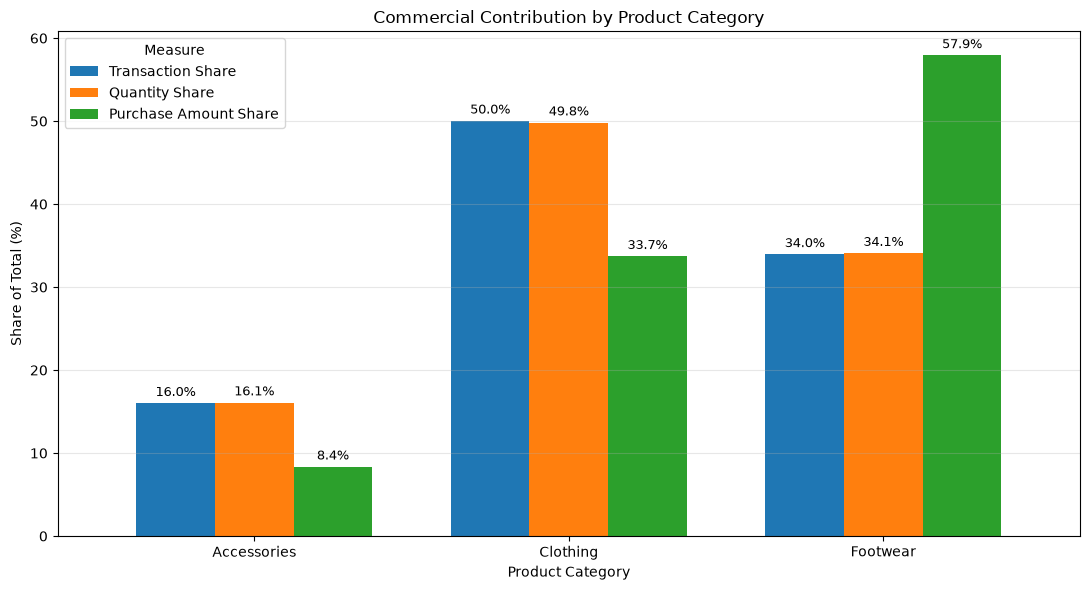

In [62]:
# Category contribution chart
category_contribution_plot = (
    category_summary
    .set_index("Category")
    [
        [
            "Transaction Share (%)",
            "Quantity Share (%)",
            "Purchase Amount Share (%)"
        ]
    ]
    .rename(
        columns={
            "Transaction Share (%)": "Transaction Share",
            "Quantity Share (%)": "Quantity Share",
            "Purchase Amount Share (%)": "Purchase Amount Share"
        }
    )
)

ax = category_contribution_plot.plot(
    kind="bar",
    figsize=(11, 6),
    width=0.75
)

plt.title("Commercial Contribution by Product Category")
plt.xlabel("Product Category")
plt.ylabel("Share of Total (%)")
plt.xticks(rotation=0)
plt.grid(axis="y", alpha=0.3)
plt.legend(title="Measure")

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.1f%%",
        padding=3,
        fontsize=9
    )

plt.tight_layout()
save_figure(
    "h3_commercial_contribution_by_product_category.png"
)
plt.show()

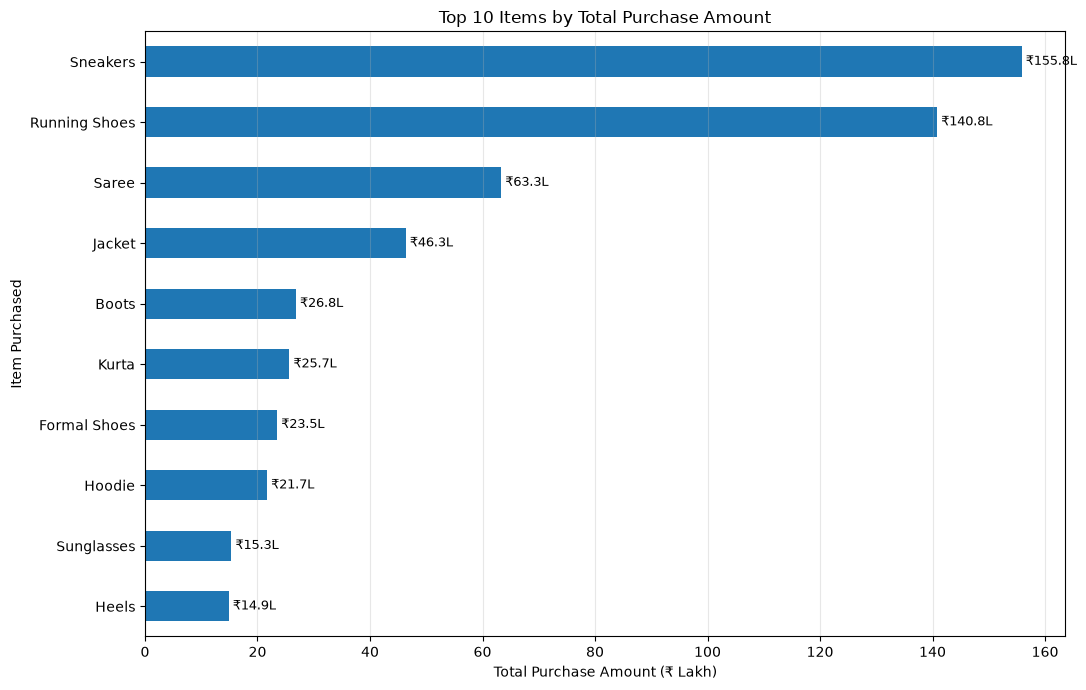

In [63]:
# Top items by purchase amount
top_item_value_plot = (
    item_summary
    .nlargest(10, "Total_Purchase_Amount")
    .sort_values("Total_Purchase_Amount")
    .copy()
)

top_item_value_plot["Purchase Amount (₹ Lakh)"] = (
    top_item_value_plot["Total_Purchase_Amount"] / 100000
)

ax = top_item_value_plot.plot(
    kind="barh",
    x="Item Purchased",
    y="Purchase Amount (₹ Lakh)",
    figsize=(11, 7),
    legend=False
)

plt.title("Top 10 Items by Total Purchase Amount")
plt.xlabel("Total Purchase Amount (₹ Lakh)")
plt.ylabel("Item Purchased")
plt.grid(axis="x", alpha=0.3)

ax.bar_label(
    ax.containers[0],
    fmt="₹%.1fL",
    padding=3,
    fontsize=9
)

plt.tight_layout()
save_figure(
    "h3_top_10_items_by_total_purchase_amount.png"
)
plt.show()

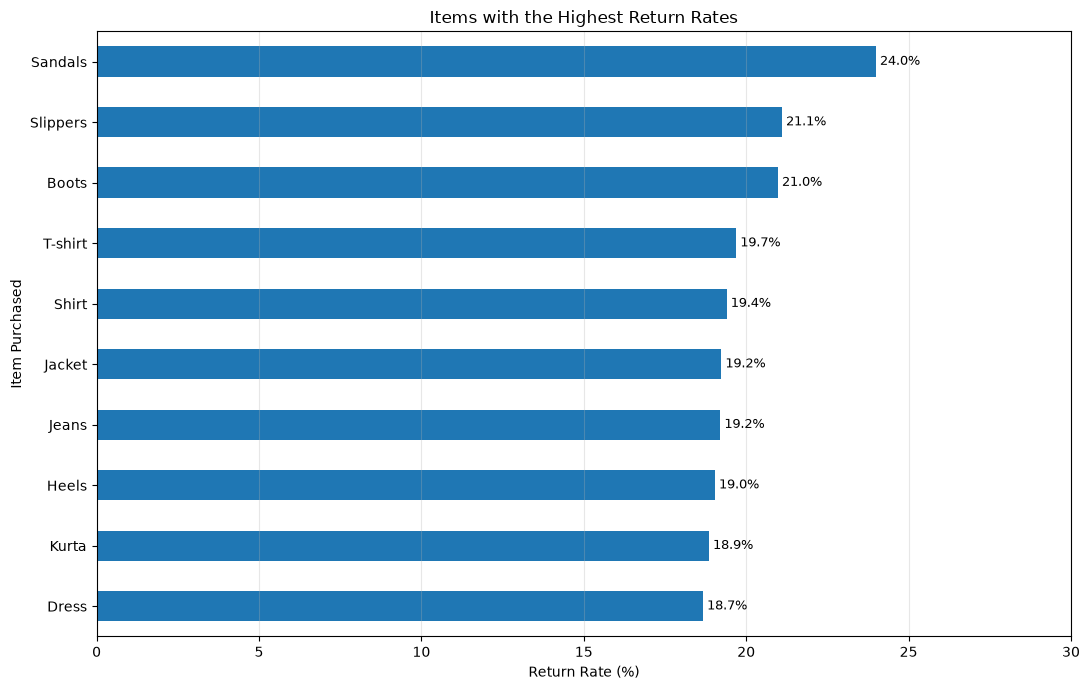

In [64]:
# Items with the highest return rates
item_return_plot = (
    highest_return_items
    .sort_values("Return Rate (%)")
)

ax = item_return_plot.plot(
    kind="barh",
    x="Item Purchased",
    y="Return Rate (%)",
    figsize=(11, 7),
    legend=False
)

plt.title("Items with the Highest Return Rates")
plt.xlabel("Return Rate (%)")
plt.ylabel("Item Purchased")
plt.xlim(0, 30)
plt.grid(axis="x", alpha=0.3)

ax.bar_label(
    ax.containers[0],
    fmt="%.1f%%",
    padding=3,
    fontsize=9
)

plt.tight_layout()
save_figure(
    "h3_items_with_the_highest_return_rates.png"
)
plt.show()

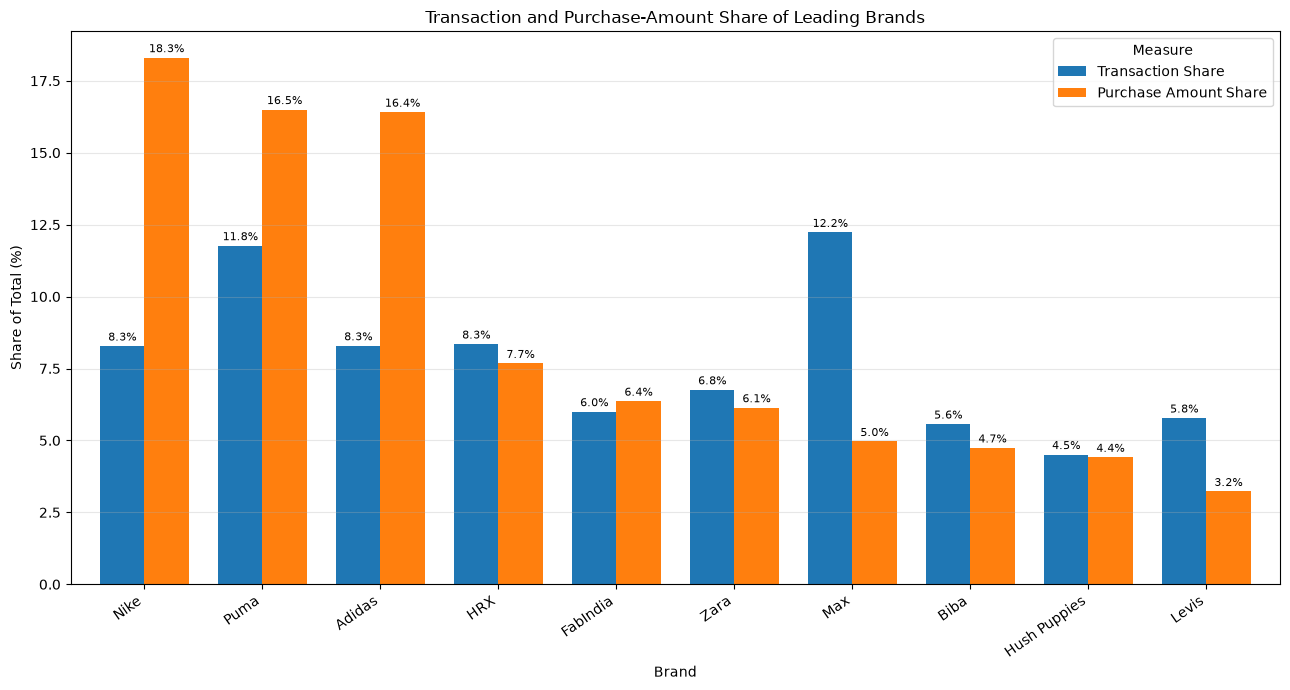

In [65]:
# Brand volume share versus purchase-value share
brand_share_plot = (
    brand_summary
    .nlargest(10, "Total_Purchase_Amount")
    .set_index("Brand")
    [
        [
            "Transaction Share (%)",
            "Purchase Amount Share (%)"
        ]
    ]
    .rename(
        columns={
            "Transaction Share (%)": "Transaction Share",
            "Purchase Amount Share (%)": "Purchase Amount Share"
        }
    )
)

ax = brand_share_plot.plot(
    kind="bar",
    figsize=(13, 7),
    width=0.75
)

plt.title("Transaction and Purchase-Amount Share of Leading Brands")
plt.xlabel("Brand")
plt.ylabel("Share of Total (%)")
plt.xticks(rotation=35, ha="right")
plt.grid(axis="y", alpha=0.3)
plt.legend(title="Measure")

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.1f%%",
        padding=2,
        fontsize=8
    )

plt.tight_layout()
save_figure(
    "h3_transaction_and_purchases_amount_share_of_leading_brands.png"
)
plt.show()

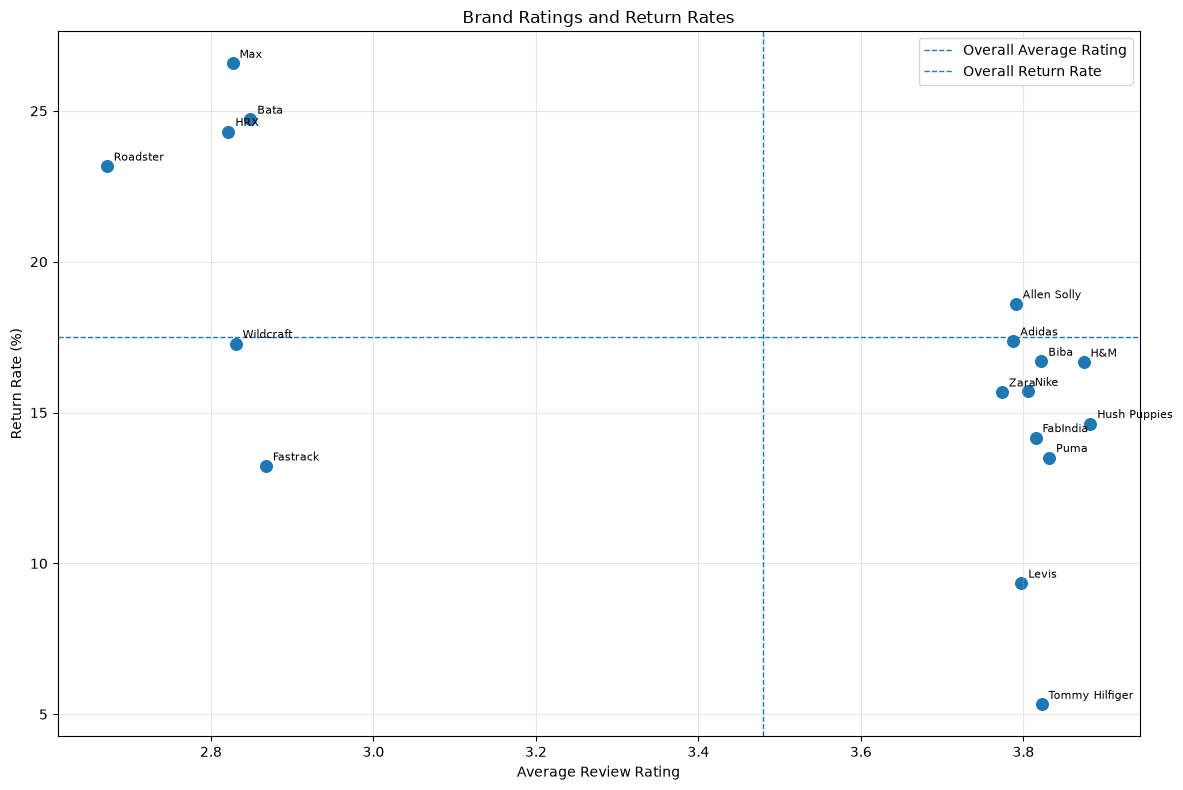

In [66]:
# Brand ratings and return rates
overall_average_rating = df["Review Rating"].mean()

overall_return_rate = (
    df["Returned"].mean() * 100
)

plt.figure(figsize=(12, 8))

plt.scatter(
    brand_summary["Average_Rating"],
    brand_summary["Return Rate (%)"],
    s=70
)

for _, row in brand_summary.iterrows():
    plt.annotate(
        row["Brand"],
        (
            row["Average_Rating"],
            row["Return Rate (%)"]
        ),
        xytext=(5, 4),
        textcoords="offset points",
        fontsize=8
    )

plt.axvline(
    overall_average_rating,
    linestyle="--",
    linewidth=1,
    label="Overall Average Rating"
)

plt.axhline(
    overall_return_rate,
    linestyle="--",
    linewidth=1,
    label="Overall Return Rate"
)

plt.title("Brand Ratings and Return Rates")
plt.xlabel("Average Review Rating")
plt.ylabel("Return Rate (%)")
plt.grid(alpha=0.3)
plt.legend()

plt.tight_layout()
save_figure(
    "h3_brand_ratings_and_return_rates.png"
)
plt.show()

### Visual Comparison Results

**Category performance**

- Product-category performance showed a clear difference between sales volume and monetary value.
- Clothing generated approximately half of all transactions and quantity purchased, but only 33.7% of total purchase amount.
- Footwear generated approximately 34% of transactions and quantity but contributed 57.9% of total purchase amount, indicating substantially higher-value transactions.
- Accessories contributed approximately 16% of transaction and quantity volume but only 8.4% of purchase amount, indicating comparatively lower-value purchases.

**Item-level purchase value**

- Item-level purchase value was highly concentrated, with Sneakers and Running Shoes generating much larger purchase amounts than every other item.
- After the two leading footwear products, total purchase amount dropped sharply from ₹140.8 lakh for Running Shoes to ₹63.3 lakh for Saree.
- The highest-value items were therefore not necessarily those with the highest transaction or quantity volume.

**Item return rates**

- The item-return chart was dominated by footwear and clothing products.
- Sandals recorded the highest return rate at approximately 24.0%, followed by Slippers and Boots at approximately 21%.
- Clothing products including T-shirt, Shirt, Jacket, Jeans, Kurta, and Dress also appeared among the highest-return items.
- No Accessories appeared in the ten highest-return items, supporting the expectation that products affected by fit and sizing may experience more returns.

**Brand contribution**

- Brand performance also showed a strong difference between transaction volume and purchase value.
- Nike generated only 8.3% of transactions but contributed 18.3% of total purchase amount.
- Adidas showed a similar pattern, contributing 16.4% of purchase amount from 8.3% of transactions.
- Puma performed strongly on both measures, with 11.8% of transactions and 16.5% of purchase amount.
- Max showed the opposite pattern, producing the highest transaction share among the displayed brands at 12.2% but only 5.0% of purchase amount.
- Nike and Adidas can therefore be described as high-value brands, while Max is primarily a high-volume brand.

**Brand ratings and returns**

- The brand scatter plot showed no simple relationship between average rating and return rate.
- Puma, Nike, Hush Puppies, FabIndia, Levi's, Tommy Hilfiger, Biba, H&M, and Zara combined above-average ratings with below-average return rates.
- Max, Bata, HRX, and Roadster combined below-average ratings with above-average return rates, indicating comparatively weaker customer outcomes.
- Allen Solly had an above-average rating but also an above-average return rate, showing that ratings and returns measure different aspects of product experience.
- Commercial success did not automatically result in better ratings or lower return rates.

## Hypothesis 3 Verdict

**Verdict: Mostly supported**

The hypothesis expected Clothing and Footwear to outperform Accessories commercially. This was supported, although the two categories performed strongly in different ways.

Clothing was the volume leader, generating the highest transaction count and quantity purchased. Footwear was the value leader, contributing the highest total purchase amount and substantially more purchase value relative to its transaction share. Accessories recorded the lowest commercial contribution, particularly in purchase amount.

The expectation that Clothing and Footwear would have higher return rates than Accessories was also supported. Footwear recorded the highest category return rate, closely followed by Clothing, while Accessories had a considerably lower return rate. Footwear and clothing items also dominated the list of products with the highest return rates.

The expectation that popular or higher-value brands would generate the greatest purchase amounts was supported by brands such as Nike, Puma, and Adidas. However, the brand with the highest transaction volume was not the brand with the highest purchase amount. Max led transaction volume, while Nike led purchase value.

The analysis also supported the expectation that commercial performance and customer outcomes would not always move together. Some commercially strong brands combined high ratings with relatively low return rates, while others generated strong volume alongside lower ratings or higher returns.

Within this synthetic dataset, product performance therefore had three distinct forms:

- Clothing led sales volume.
- Footwear led monetary value.
- Customer satisfaction and return behaviour varied independently across items and brands.

## Hypothesis 4: Online and Offline Shopping Behaviour

### Question

How do online and offline purchases differ in customer reach, product preferences, transaction value, payment methods, and return behaviour?

### Hypothesis

- Online purchases may have a higher return rate because customers cannot physically inspect or try products before purchasing them.

- Online transactions are expected to rely mainly on digital payment methods and cash on delivery, while offline transactions may use cash more frequently.

- Product preferences may differ between channels. Online and offline channels may contribute different shares of transactions and purchase amount across product categories and individual items.

- Average transaction value and quantity may also differ between channels because customers may use online and offline shopping for different types of purchases.

### Measures

Channel performance will be evaluated using:

- unique customers and customer reach;
- transaction count and transaction share;
- total purchase amount and purchase-amount share;
- average transaction value;
- total and average quantity;
- purchase amount per unit;
- average discount;
- average review rating;
- return rate.

Shopping behaviour will also be compared using:

- customer channel usage;
- product-category mix;
- leading items by channel;
- payment-method distribution;
- online-store performance.

### Visual Analysis

The analysis will proceed from broad channel behaviour to more detailed purchasing patterns:

1. online and offline customer reach;
2. commercial performance by channel;
3. category and item preferences by channel;
4. payment methods by channel;
5. performance of individual online stores.

### Interpretation Rule

A customer may make both online and offline purchases. Therefore, unique-customer counts for the two channels may overlap and should not be added together.

Total purchase amount is affected by transaction volume. Channel totals must therefore be interpreted alongside average transaction value and within-channel percentage shares.

### Analysis 4A: Channel-Structure Validation

The channel and store fields are inspected before comparison.

The analysis also identifies whether customers purchase only online, only offline, or through both channels.

In [67]:
# Inspect channel values
channel_counts = (
    df["Online/Offline"]
    .value_counts(dropna=False)
    .rename_axis("Channel")
    .reset_index(name="Transaction Count")
)

channel_counts["Transaction Share (%)"] = (
    channel_counts["Transaction Count"]
    / len(df)
    * 100
)

display(channel_counts.round(2))

,Channel,Transaction Count,Transaction Share (%)
0,Online,7417,74.17
1,Offline,2583,25.83


In [68]:
# Inspect store values within each channel
store_channel_table = pd.crosstab(
    df["Online/Offline"],
    df["Online Store"]
)

display(store_channel_table)

Online Store,Ajio,Amazon,Flipkart,In-Store Purchase,Meesho,Myntra,Nykaa
Online/Offline,,,,,,,
Offline,0,0,0,2583,0,0,0
Online,1276,1229,1212,0,1277,1218,1205


In [69]:
# Validate channel-store combinations
offline_store_mismatches = df[
    (df["Online/Offline"] == "Offline")
    & (df["Online Store"] != "In-Store Purchase")
]

online_store_mismatches = df[
    (df["Online/Offline"] == "Online")
    & (df["Online Store"] == "In-Store Purchase")
]

print(
    "Offline transactions with an unexpected store value:",
    len(offline_store_mismatches)
)

print(
    "Online transactions marked as In-Store Purchase:",
    len(online_store_mismatches)
)

Offline transactions with an unexpected store value: 0
Online transactions marked as In-Store Purchase: 0


In [70]:
# Classify customers by channel usage
customer_channel_counts = pd.crosstab(
    df["Customer ID"],
    df["Online/Offline"]
).reindex(
    columns=["Online", "Offline"],
    fill_value=0
)

customer_channel_counts["Channel Segment"] = np.select(
    [
        (
            customer_channel_counts["Online"] > 0
        )
        & (
            customer_channel_counts["Offline"] > 0
        ),
        (
            customer_channel_counts["Online"] > 0
        )
        & (
            customer_channel_counts["Offline"] == 0
        ),
        (
            customer_channel_counts["Online"] == 0
        )
        & (
            customer_channel_counts["Offline"] > 0
        )
    ],
    [
        "Both Channels",
        "Online Only",
        "Offline Only"
    ],
    default="Unclassified"
)

customer_channel_segments = (
    customer_channel_counts["Channel Segment"]
    .value_counts()
    .rename_axis("Channel Segment")
    .reset_index(name="Unique Customers")
)

customer_channel_segments["Customer Share (%)"] = (
    customer_channel_segments["Unique Customers"]
    / df["Customer ID"].nunique()
    * 100
)

display(customer_channel_segments.round(2))

,Channel Segment,Unique Customers,Customer Share (%)
0,Both Channels,1595,48.47
1,Online Only,1491,45.31
2,Offline Only,205,6.23


#### Channel-Structure Results

- Online purchases accounted for 7,417 transactions, representing 74.17% of all transactions.
- Offline purchases accounted for 2,583 transactions, representing 25.83%.
- Every offline transaction was correctly labelled as an In-Store Purchase, while every online transaction was assigned to an online platform.
- No inconsistent channel-store combinations were found.
- Among the 3,291 customers, 1,595 customers, or 48.47%, purchased through both online and offline channels.
- A further 1,491 customers, or 45.31%, purchased only online.
- Only 205 customers, or 6.23%, purchased exclusively offline.
- Online shopping therefore had substantially broader customer reach, while nearly half of the customer base used both channels.
- The separate online and offline customer-reach percentages should not be added because customers who used both channels appear in both counts.

### Analysis 4B: Commercial Performance by Channel

Online and offline transactions are compared using total contribution, average transaction behaviour, ratings, and return rates.

In [71]:
channel_summary = (
    df.groupby(
        "Online/Offline",
        as_index=False,
        observed=True
    )
    .agg(
        Unique_Customers=(
            "Customer ID",
            "nunique"
        ),
        Transaction_Count=(
            "Transaction ID",
            "nunique"
        ),
        Total_Quantity=(
            "Quantity",
            "sum"
        ),
        Total_Purchase_Amount=(
            "Purchase Amount (₹)",
            "sum"
        ),
        Average_Transaction_Value=(
            "Purchase Amount (₹)",
            "mean"
        ),
        Average_Quantity_Per_Transaction=(
            "Quantity",
            "mean"
        ),
        Average_Discount=(
            "Discount (%)",
            "mean"
        ),
        Average_Rating=(
            "Review Rating",
            "mean"
        ),
        Returned_Transactions=(
            "Returned",
            "sum"
        )
    )
)

channel_summary["Customer Reach (%)"] = (
    channel_summary["Unique_Customers"]
    / df["Customer ID"].nunique()
    * 100
)

channel_summary["Transaction Share (%)"] = (
    channel_summary["Transaction_Count"]
    / df["Transaction ID"].nunique()
    * 100
)

channel_summary["Quantity Share (%)"] = (
    channel_summary["Total_Quantity"]
    / df["Quantity"].sum()
    * 100
)

channel_summary["Purchase Amount Share (%)"] = (
    channel_summary["Total_Purchase_Amount"]
    / df["Purchase Amount (₹)"].sum()
    * 100
)

channel_summary["Purchase Amount per Unit"] = (
    channel_summary["Total_Purchase_Amount"]
    / channel_summary["Total_Quantity"]
)

channel_summary["Return Rate (%)"] = (
    channel_summary["Returned_Transactions"]
    / channel_summary["Transaction_Count"]
    * 100
)

channel_summary = channel_summary[
    [
        "Online/Offline",
        "Unique_Customers",
        "Customer Reach (%)",
        "Transaction_Count",
        "Transaction Share (%)",
        "Total_Quantity",
        "Quantity Share (%)",
        "Total_Purchase_Amount",
        "Purchase Amount Share (%)",
        "Average_Transaction_Value",
        "Average_Quantity_Per_Transaction",
        "Purchase Amount per Unit",
        "Average_Discount",
        "Average_Rating",
        "Returned_Transactions",
        "Return Rate (%)"
    ]
]

display(channel_summary.round(2))

,Online/Offline,Unique_Customers,Customer Reach (%),Transaction_Count,Transaction Share (%),Total_Quantity,Quantity Share (%),Total_Purchase_Amount,Purchase Amount Share (%),Average_Transaction_Value,Average_Quantity_Per_Transaction,Purchase Amount per Unit,Average_Discount,Average_Rating,Returned_Transactions,Return Rate (%)
0,Offline,1800,54.69,2583,25.83,3685,25.84,16859372,26.07,"6,527.05",1.43,"4,575.13",9.63,3.66,421,16.30
1,Online,3086,93.77,7417,74.17,10574,74.16,47817573,73.93,"6,447.02",1.43,"4,522.18",8.38,3.42,1330,17.93


In [72]:
# Validate the aggregation
print(
    "Transactions in channel summary:",
    channel_summary["Transaction_Count"].sum()
)

print(
    "Transactions in original dataset:",
    df["Transaction ID"].nunique()
)

print(
    "\nQuantity in channel summary:",
    channel_summary["Total_Quantity"].sum()
)

print(
    "Quantity in original dataset:",
    df["Quantity"].sum()
)

print(
    "\nPurchase amount in channel summary:",
    channel_summary["Total_Purchase_Amount"].sum()
)

print(
    "Purchase amount in original dataset:",
    df["Purchase Amount (₹)"].sum()
)

Transactions in channel summary: 10000
Transactions in original dataset: 10000

Quantity in channel summary: 14259
Quantity in original dataset: 14259

Purchase amount in channel summary: 64676945
Purchase amount in original dataset: 64676945


In [73]:
# Calculate channel differences
channel_comparison = channel_summary.set_index(
    "Online/Offline"
)

online_channel = channel_comparison.loc["Online"]
offline_channel = channel_comparison.loc["Offline"]

channel_difference_metrics = {
    "Average transaction value":
        "Average_Transaction_Value",

    "Average quantity per transaction":
        "Average_Quantity_Per_Transaction",

    "Purchase amount per unit":
        "Purchase Amount per Unit",

    "Average discount":
        "Average_Discount",

    "Average rating":
        "Average_Rating",

    "Return rate":
        "Return Rate (%)"
}

for label, metric in channel_difference_metrics.items():

    difference = (
        (
            online_channel[metric]
            - offline_channel[metric]
        )
        / offline_channel[metric]
        * 100
    )

    print(
        f"Online versus offline — {label}:",
        f"{difference:+.2f}%"
    )

Online versus offline — Average transaction value: -1.23%
Online versus offline — Average quantity per transaction: -0.07%
Online versus offline — Purchase amount per unit: -1.16%
Online versus offline — Average discount: -13.01%
Online versus offline — Average rating: -6.58%
Online versus offline — Return rate: +10.02%


#### Channel-Performance Results

- Online transactions generated 74.17% of transaction volume, 74.16% of quantity purchased, and 73.93% of total purchase amount.
- This large online contribution mainly reflects its substantially higher transaction volume.
- Average transaction value was slightly higher offline at ₹6,527.05, compared with ₹6,447.02 online.
- Online average transaction value was approximately 1.23% lower than the offline value.
- Average quantity per transaction was almost identical in both channels at approximately 1.43 units.
- Purchase amount per unit was also slightly higher offline at ₹4,575.13, compared with ₹4,522.18 online.
- Online transactions received an average discount of 8.38%, compared with 9.63% for offline transactions.
- Average review rating was higher offline at 3.66, compared with 3.42 online.
- Online purchases recorded a return rate of 17.93%, compared with 16.30% for offline purchases.
- The online return rate was therefore 1.63 percentage points higher, equivalent to an approximately 10.02% relative increase over the offline rate.
- Online purchasing was associated with wider reach and greater total activity, but not with higher transaction value or larger quantities per transaction.

### Analysis 4C: Product-Category Preferences by Channel

Category preferences are measured using within-channel shares.

This prevents the larger channel from automatically appearing stronger in every category.

In [74]:
# Category transaction counts
channel_category_transactions = pd.crosstab(
    df["Online/Offline"],
    df["Category"]
)

display(channel_category_transactions)

Category,Accessories,Clothing,Footwear
Online/Offline,,,
Offline,393,1276,914
Online,1208,3728,2481


In [75]:
# Category transaction share within each channel
channel_category_transaction_share = (
    pd.crosstab(
        df["Online/Offline"],
        df["Category"],
        normalize="index"
    )
    * 100
)

display(
    channel_category_transaction_share.round(2)
)

Category,Accessories,Clothing,Footwear
Online/Offline,,,
Offline,15.21,49.40,35.39
Online,16.29,50.26,33.45


In [76]:
print(
    "Transaction-share row totals:"
)

print(
    channel_category_transaction_share
    .sum(axis=1)
    .round(2)
)

Transaction-share row totals:
Online/Offline
Offline   100.00
Online    100.00
dtype: float64


In [77]:
# Category purchase amount by channel
channel_category_purchase_amount = pd.pivot_table(
    df,
    index="Online/Offline",
    columns="Category",
    values="Purchase Amount (₹)",
    aggfunc="sum",
    fill_value=0,
    observed=True
)

display(channel_category_purchase_amount)

Category,Accessories,Clothing,Footwear
Online/Offline,,,
Offline,1314243,5537206,10007923
Online,4090818,16272215,27454540


In [78]:
# Category purchase-amount share within each channel
channel_category_purchase_share = (
    channel_category_purchase_amount
    .div(
        channel_category_purchase_amount.sum(axis=1),
        axis=0
    )
    * 100
)

display(
    channel_category_purchase_share.round(2)
)

Category,Accessories,Clothing,Footwear
Online/Offline,,,
Offline,7.80,32.84,59.36
Online,8.56,34.03,57.42


In [79]:
print(
    "Purchase-share row totals:"
)

print(
    channel_category_purchase_share
    .sum(axis=1)
    .round(2)
)

Purchase-share row totals:
Online/Offline
Offline   100.00
Online    100.00
dtype: float64


#### Product-Category Preference Results

- Product-category transaction patterns were highly similar across online and offline channels.
- Clothing represented 49.40% of offline transactions and 50.26% of online transactions.
- Footwear represented 35.39% of offline transactions and 33.45% of online transactions.
- Accessories represented 15.21% of offline transactions and 16.29% of online transactions.
- Purchase-amount composition was also similar across channels.
- Footwear generated 59.36% of offline purchase amount and 57.42% of online purchase amount.
- Clothing generated 32.84% of offline purchase amount and 34.03% of online purchase amount.
- Accessories contributed less than 9% of purchase amount in both channels.
- The results do not indicate a major difference in broad product-category preference between online and offline customers.
- In both channels, Clothing led transaction volume while Footwear led monetary value.

### Analysis 4D: Leading Items by Channel

The highest-performing items are identified separately for online and offline purchases.

Transaction rankings show frequently purchased items, while purchase-amount rankings identify high-value products.

In [80]:
channel_item_summary = (
    df.groupby(
        [
            "Online/Offline",
            "Item Purchased"
        ],
        as_index=False,
        observed=True
    )
    .agg(
        Transaction_Count=(
            "Transaction ID",
            "nunique"
        ),
        Total_Quantity=(
            "Quantity",
            "sum"
        ),
        Total_Purchase_Amount=(
            "Purchase Amount (₹)",
            "sum"
        ),
        Average_Transaction_Value=(
            "Purchase Amount (₹)",
            "mean"
        ),
        Returned_Transactions=(
            "Returned",
            "sum"
        )
    )
)

channel_item_summary["Return Rate (%)"] = (
    channel_item_summary["Returned_Transactions"]
    / channel_item_summary["Transaction_Count"]
    * 100
)

In [81]:
# Top five items by transaction count in each channel
top_channel_items_by_transactions = (
    channel_item_summary
    .sort_values(
        [
            "Online/Offline",
            "Transaction_Count"
        ],
        ascending=[True, False]
    )
    .groupby(
        "Online/Offline",
        as_index=False,
        group_keys=False
    )
    .head(5)
)

display(
    top_channel_items_by_transactions[
        [
            "Online/Offline",
            "Item Purchased",
            "Transaction_Count",
            "Total_Quantity",
            "Total_Purchase_Amount",
            "Average_Transaction_Value",
            "Return Rate (%)"
        ]
    ].round(2)
)

,Online/Offline,Item Purchased,Transaction_Count,Total_Quantity,Total_Purchase_Amount,Average_Transaction_Value,Return Rate (%)
12,Offline,Running Shoes,254,363,3984715,"15,687.85",17.72
14,Offline,Saree,213,304,1656165,"7,775.42",20.19
11,Offline,Kurta,211,303,621907,"2,947.43",16.59
18,Offline,Sneakers,211,303,3996661,"18,941.52",20.38
21,Offline,T-shirt,186,257,363071,"1,951.99",19.89
35,Online,Kurta,659,947,1943450,"2,949.09",19.58
38,Online,Saree,633,860,4675154,"7,385.71",18.01
36,Online,Running Shoes,607,850,10095286,"16,631.44",18.45
42,Online,Sneakers,606,876,11586447,"19,119.55",16.01
33,Online,Jacket,494,692,3384481,"6,851.18",19.84


In [82]:
# Top five items by purchase amount in each channel
top_channel_items_by_purchase_amount = (
    channel_item_summary
    .sort_values(
        [
            "Online/Offline",
            "Total_Purchase_Amount"
        ],
        ascending=[True, False]
    )
    .groupby(
        "Online/Offline",
        as_index=False,
        group_keys=False
    )
    .head(5)
)

display(
    top_channel_items_by_purchase_amount[
        [
            "Online/Offline",
            "Item Purchased",
            "Total_Purchase_Amount",
            "Transaction_Count",
            "Total_Quantity",
            "Average_Transaction_Value",
            "Return Rate (%)"
        ]
    ].round(2)
)

,Online/Offline,Item Purchased,Total_Purchase_Amount,Transaction_Count,Total_Quantity,Average_Transaction_Value,Return Rate (%)
18,Offline,Sneakers,3996661,211,303,"18,941.52",20.38
12,Offline,Running Shoes,3984715,254,363,"15,687.85",17.72
14,Offline,Saree,1656165,213,304,"7,775.42",20.19
9,Offline,Jacket,1250283,182,274,"6,869.69",17.58
6,Offline,Formal Shoes,731261,98,156,"7,461.85",15.31
42,Online,Sneakers,11586447,606,876,"19,119.55",16.01
36,Online,Running Shoes,10095286,607,850,"16,631.44",18.45
38,Online,Saree,4675154,633,860,"7,385.71",18.01
33,Online,Jacket,3384481,494,692,"6,851.18",19.84
27,Online,Boots,2046925,248,352,"8,253.73",22.98


#### Leading-Item Results by Channel

- Product rankings were largely consistent across online and offline channels.
- Running Shoes, Saree, Kurta, and Sneakers appeared among the five most frequently purchased items in both channels.
- Running Shoes recorded the highest offline transaction count, while Kurta recorded the highest online transaction count.
- The fifth leading item differed: T-shirt appeared in the offline ranking, while Jacket appeared in the online ranking.
- Sneakers generated the highest purchase amount in both channels, followed by Running Shoes.
- Sneakers, Running Shoes, Saree, and Jacket appeared among the five highest-value items in both channels.
- The fifth highest-value product was Formal Shoes offline and Boots online.
- The strong overlap in item rankings indicates that online and offline customers generally purchased similar leading products.
- Raw online item totals were higher because the online channel contained nearly three times as many transactions. The rankings are therefore more meaningful than direct comparisons of raw totals between channels.

### Analysis 4E: Payment Methods by Channel

Payment-method distributions are compared using within-channel percentages.

This identifies the methods customers prefer when shopping online and offline.

In [83]:
# Payment-method counts
channel_payment_counts = pd.crosstab(
    df["Online/Offline"],
    df["Payment Method"]
)

payment_order = (
    channel_payment_counts
    .sum(axis=0)
    .sort_values(ascending=False)
    .index
)

channel_payment_counts = (
    channel_payment_counts
    .reindex(columns=payment_order)
)

display(channel_payment_counts)

Payment Method,UPI,Credit Card,Debit Card,Cash on Delivery,Cash,Net Banking,Wallet
Online/Offline,,,,,,,
Offline,1264,527,257,0,535,0,0
Online,3015,1448,1163,1091,0,355,345


In [84]:
# Payment-method share within each channel
channel_payment_share = (
    pd.crosstab(
        df["Online/Offline"],
        df["Payment Method"],
        normalize="index"
    )
    * 100
)

channel_payment_share = (
    channel_payment_share
    .reindex(columns=payment_order)
)

display(channel_payment_share.round(2))

Payment Method,UPI,Credit Card,Debit Card,Cash on Delivery,Cash,Net Banking,Wallet
Online/Offline,,,,,,,
Offline,48.94,20.40,9.95,0.00,20.71,0.00,0.00
Online,40.65,19.52,15.68,14.71,0.00,4.79,4.65


In [85]:
print(
    "Payment-share row totals:"
)

print(
    channel_payment_share
    .sum(axis=1)
    .round(2)
)

Payment-share row totals:
Online/Offline
Offline   100.00
Online    100.00
dtype: float64


#### Payment-Method Results

- UPI was the most frequently used payment method in both channels.
- UPI accounted for 48.94% of offline transactions and 40.65% of online transactions.
- Cash represented 20.71% of offline transactions and was not used for online purchases.
- Cash on Delivery represented 14.71% of online transactions and was not used offline.
- Credit cards were used at similar rates in both channels: 20.40% offline and 19.52% online.
- Debit-card usage was higher online at 15.68%, compared with 9.95% offline.
- Net Banking and Wallet payments were exclusive to the online channel, although each accounted for less than 5% of online transactions.
- Offline purchases relied on UPI, cards, and cash, while online purchases used a broader range of digital methods together with Cash on Delivery.
- The expected channel-based difference in payment behaviour was therefore supported.

### Analysis 4F: Online-Store Performance

Online transactions are examined separately to compare platform reach, commercial performance, ratings, and returns.

Offline transactions are excluded because all offline purchases use the single In-Store Purchase label.

In [86]:
online_transactions = df[
    df["Online/Offline"] == "Online"
].copy()

online_store_summary = (
    online_transactions
    .groupby(
        "Online Store",
        as_index=False,
        observed=True
    )
    .agg(
        Unique_Customers=(
            "Customer ID",
            "nunique"
        ),
        Transaction_Count=(
            "Transaction ID",
            "nunique"
        ),
        Total_Quantity=(
            "Quantity",
            "sum"
        ),
        Total_Purchase_Amount=(
            "Purchase Amount (₹)",
            "sum"
        ),
        Average_Transaction_Value=(
            "Purchase Amount (₹)",
            "mean"
        ),
        Average_Quantity_Per_Transaction=(
            "Quantity",
            "mean"
        ),
        Average_Discount=(
            "Discount (%)",
            "mean"
        ),
        Average_Rating=(
            "Review Rating",
            "mean"
        ),
        Returned_Transactions=(
            "Returned",
            "sum"
        )
    )
)

online_store_summary["Transaction Share (%)"] = (
    online_store_summary["Transaction_Count"]
    / online_transactions["Transaction ID"].nunique()
    * 100
)

online_store_summary["Purchase Amount Share (%)"] = (
    online_store_summary["Total_Purchase_Amount"]
    / online_transactions["Purchase Amount (₹)"].sum()
    * 100
)

online_store_summary["Return Rate (%)"] = (
    online_store_summary["Returned_Transactions"]
    / online_store_summary["Transaction_Count"]
    * 100
)

online_store_summary = online_store_summary[
    [
        "Online Store",
        "Unique_Customers",
        "Transaction_Count",
        "Transaction Share (%)",
        "Total_Quantity",
        "Total_Purchase_Amount",
        "Purchase Amount Share (%)",
        "Average_Transaction_Value",
        "Average_Quantity_Per_Transaction",
        "Average_Discount",
        "Average_Rating",
        "Returned_Transactions",
        "Return Rate (%)"
    ]
].sort_values(
    "Total_Purchase_Amount",
    ascending=False
)

display(online_store_summary.round(2))

,Online Store,Unique_Customers,Transaction_Count,Transaction Share (%),Total_Quantity,Total_Purchase_Amount,Purchase Amount Share (%),Average_Transaction_Value,Average_Quantity_Per_Transaction,Average_Discount,Average_Rating,Returned_Transactions,Return Rate (%)
0,Ajio,1071,1276,17.20,1826,8345811,17.45,"6,540.60",1.43,8.60,3.46,213,16.69
2,Flipkart,1006,1212,16.34,1708,8039413,16.81,"6,633.18",1.41,8.31,3.42,218,17.99
1,Amazon,1042,1229,16.57,1791,7935876,16.60,"6,457.18",1.46,8.60,3.35,248,20.18
4,Myntra,1021,1218,16.42,1742,7898572,16.52,"6,484.87",1.43,8.21,3.44,224,18.39
5,Nykaa,1025,1205,16.25,1702,7833580,16.38,"6,500.90",1.41,8.31,3.41,210,17.43
3,Meesho,1069,1277,17.22,1805,7764321,16.24,"6,080.13",1.41,8.24,3.42,217,16.99


In [87]:
# Identify leading stores
online_store_metrics = {
    "Highest transaction count":
        "Transaction_Count",

    "Highest total purchase amount":
        "Total_Purchase_Amount",

    "Highest average transaction value":
        "Average_Transaction_Value",

    "Highest average rating":
        "Average_Rating",

    "Highest return rate":
        "Return Rate (%)",

    "Lowest return rate":
        "Return Rate (%)"
}

for label, metric in online_store_metrics.items():

    if label == "Lowest return rate":
        result = online_store_summary.loc[
            online_store_summary[metric].idxmin()
        ]
    else:
        result = online_store_summary.loc[
            online_store_summary[metric].idxmax()
        ]

    print(
        f"{label}:",
        result["Online Store"],
        f"({result[metric]:,.2f})"
    )

Highest transaction count: Meesho (1,277.00)
Highest total purchase amount: Ajio (8,345,811.00)
Highest average transaction value: Flipkart (6,633.18)
Highest average rating: Ajio (3.46)
Highest return rate: Amazon (20.18)
Lowest return rate: Ajio (16.69)


#### Online-Store Results

- Transaction and purchase-amount contributions were distributed relatively evenly across the six online platforms.
- Individual platform transaction shares ranged only from 16.25% to 17.22%.
- Purchase-amount shares ranged from 16.24% to 17.45%.
- Meesho recorded the highest transaction count with 1,277 transactions.
- Ajio generated the highest total purchase amount at ₹8,345,811.
- Flipkart recorded the highest average transaction value at ₹6,633.18.
- Ajio also recorded the highest average rating at 3.46 and the lowest return rate at 16.69%.
- Amazon recorded the lowest average rating at 3.35 and the highest return rate at 20.18%.
- No single platform dominated every commercial measure.
- Ajio showed the strongest combined performance across purchase amount, rating, and return behaviour, while Meesho led transaction volume and Flipkart led average transaction value.
- Differences between stores were generally moderate, so the platform rankings should not be interpreted as evidence of overwhelming dominance.

### Analysis 4G: Visual Comparison of Shopping Channels

The visual analysis focuses on:

1. customer use of online and offline channels;
2. differences in transaction behaviour and return rates;
3. product-category composition by channel;
4. payment-method preferences;
5. commercial contribution of online stores.

Item-level rankings are retained as tables because the leading online and offline products substantially overlap.

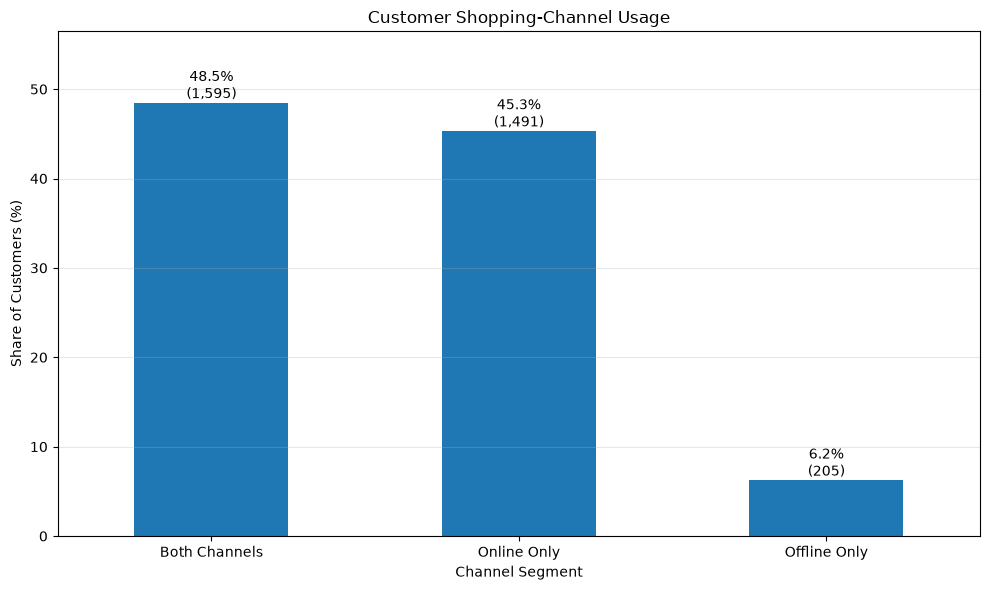

In [88]:
# Visualize whether customers use online, offline, or both channels
channel_segment_plot = (
    customer_channel_segments
    .set_index("Channel Segment")
)

ax = channel_segment_plot[
    "Customer Share (%)"
].plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Customer Shopping-Channel Usage")
plt.xlabel("Channel Segment")
plt.ylabel("Share of Customers (%)")
plt.xticks(rotation=0)
plt.ylim(
    0,
    channel_segment_plot["Customer Share (%)"].max() + 8
)
plt.grid(axis="y", alpha=0.3)

for bar, customers in zip(
    ax.patches,
    channel_segment_plot["Unique Customers"]
):
    value = bar.get_height()

    plt.text(
        bar.get_x() + bar.get_width() / 2,
        value,
        f"{value:.1f}%\n({customers:,})",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
save_figure(
    "h4_customer_shopping_channel_usage.png"
)
plt.show()

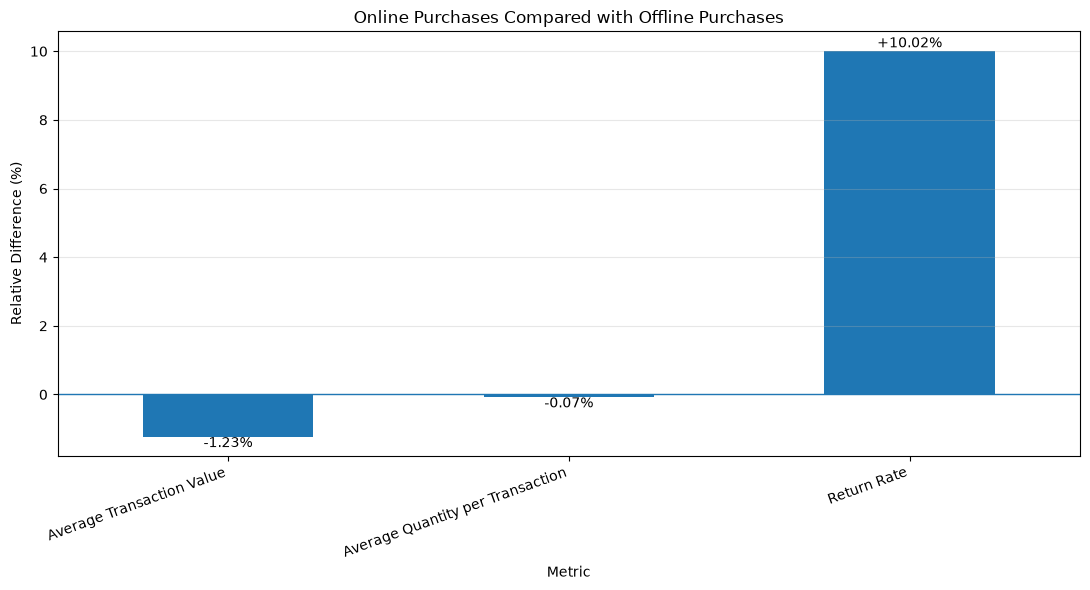

In [89]:
# Compare key online metrics with their offline equivalents
online_vs_offline_difference = pd.Series(
    {
        "Average Transaction Value": (
            online_channel["Average_Transaction_Value"]
            / offline_channel["Average_Transaction_Value"]
            - 1
        ) * 100,

        "Average Quantity per Transaction": (
            online_channel["Average_Quantity_Per_Transaction"]
            / offline_channel["Average_Quantity_Per_Transaction"]
            - 1
        ) * 100,

        "Return Rate": (
            online_channel["Return Rate (%)"]
            / offline_channel["Return Rate (%)"]
            - 1
        ) * 100
    }
)

ax = online_vs_offline_difference.plot(
    kind="bar",
    figsize=(11, 6)
)

plt.title("Online Purchases Compared with Offline Purchases")
plt.xlabel("Metric")
plt.ylabel("Relative Difference (%)")
plt.xticks(rotation=20, ha="right")
plt.axhline(0, linewidth=1)
plt.grid(axis="y", alpha=0.3)

for bar in ax.patches:
    value = bar.get_height()

    plt.text(
        bar.get_x() + bar.get_width() / 2,
        value,
        f"{value:+.2f}%",
        ha="center",
        va="bottom" if value >= 0 else "top"
    )

plt.tight_layout()
save_figure(
    "h4_online_purchases_compared_with_offline_purchases.png"
)
plt.show()

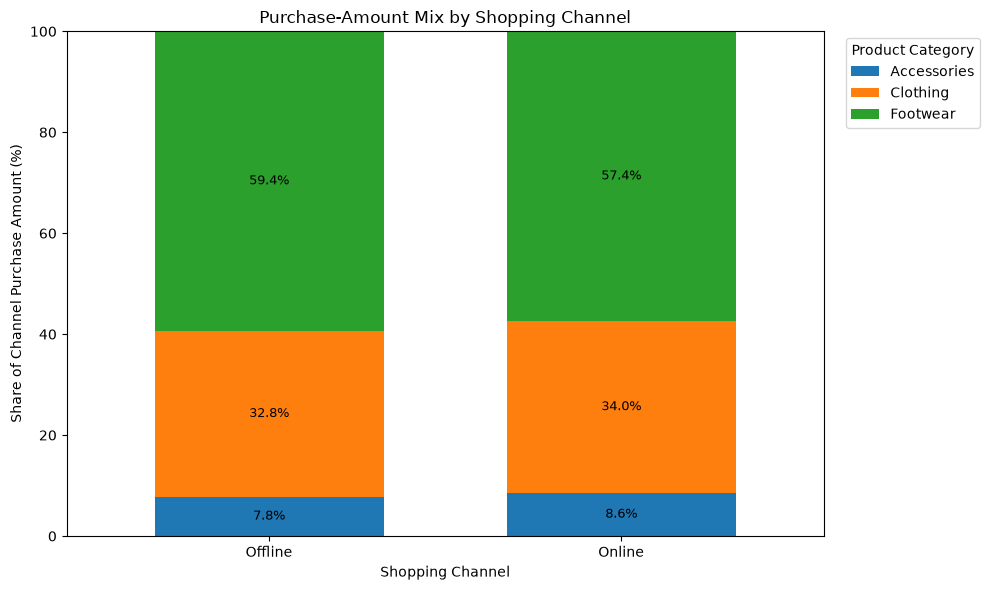

In [90]:
# Compare the composition of purchase value within each channel
category_purchase_mix_plot = (
    channel_category_purchase_share
    .reindex(
        columns=[
            "Accessories",
            "Clothing",
            "Footwear"
        ]
    )
)

ax = category_purchase_mix_plot.plot(
    kind="bar",
    stacked=True,
    figsize=(10, 6),
    width=0.65
)

plt.title("Purchase-Amount Mix by Shopping Channel")
plt.xlabel("Shopping Channel")
plt.ylabel("Share of Channel Purchase Amount (%)")
plt.xticks(rotation=0)
plt.ylim(0, 100)
plt.legend(
    title="Product Category",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

for container in ax.containers:
    labels = [
        f"{value:.1f}%"
        if value >= 5
        else ""
        for value in container.datavalues
    ]

    ax.bar_label(
        container,
        labels=labels,
        label_type="center",
        fontsize=9
    )

plt.tight_layout()
save_figure(
    "h4_purchase_amount_mix_by_shopping_channel.png"
)
plt.show()

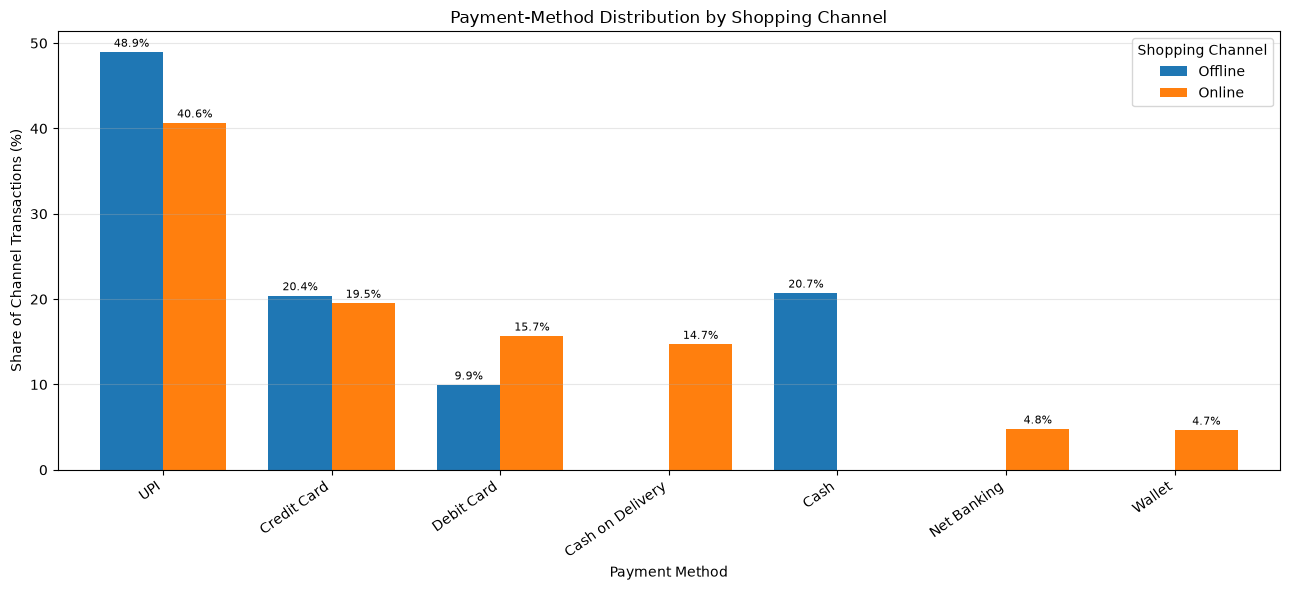

In [91]:
# Compare payment-method shares within online and offline transactions
payment_share_plot = (
    channel_payment_share
    .transpose()
)

ax = payment_share_plot.plot(
    kind="bar",
    figsize=(13, 6),
    width=0.75
)

plt.title("Payment-Method Distribution by Shopping Channel")
plt.xlabel("Payment Method")
plt.ylabel("Share of Channel Transactions (%)")
plt.xticks(rotation=35, ha="right")
plt.grid(axis="y", alpha=0.3)
plt.legend(title="Shopping Channel")

for container in ax.containers:
    labels = [
        f"{value:.1f}%"
        if value > 0
        else ""
        for value in container.datavalues
    ]

    ax.bar_label(
        container,
        labels=labels,
        padding=2,
        fontsize=8
    )

plt.tight_layout()
save_figure(
    "h4_payment_method_dist_by_shopping_channel.png"
)
plt.show()

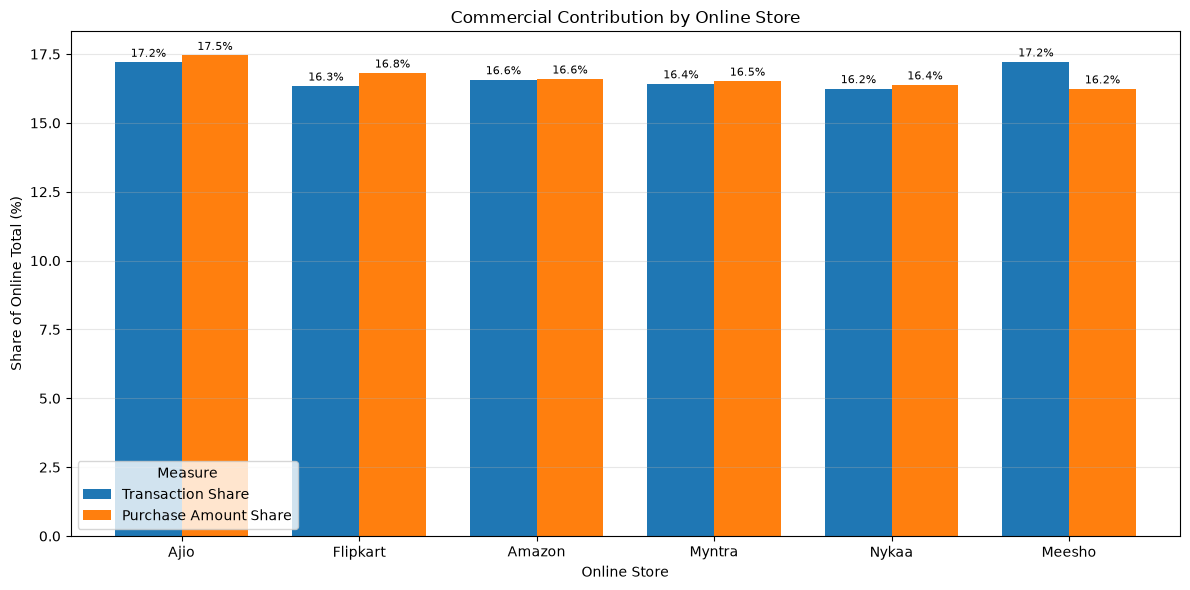

In [92]:
# Compare transaction and purchase-value contribution across online stores
online_store_share_plot = (
    online_store_summary
    .set_index("Online Store")
    [
        [
            "Transaction Share (%)",
            "Purchase Amount Share (%)"
        ]
    ]
    .rename(
        columns={
            "Transaction Share (%)":
                "Transaction Share",

            "Purchase Amount Share (%)":
                "Purchase Amount Share"
        }
    )
)

ax = online_store_share_plot.plot(
    kind="bar",
    figsize=(12, 6),
    width=0.75
)

plt.title("Commercial Contribution by Online Store")
plt.xlabel("Online Store")
plt.ylabel("Share of Online Total (%)")
plt.xticks(rotation=0)
plt.grid(axis="y", alpha=0.3)
plt.legend(title="Measure")

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.1f%%",
        padding=2,
        fontsize=8
    )

plt.tight_layout()
save_figure(
    "h4_commercial_contribution_by_online_store.png"
)
plt.show()

### Visual Comparison Results

**Customer reach**

- Online shopping had substantially greater customer reach than offline shopping.
- Nearly half of customers used both channels, while another 45.3% purchased exclusively online.
- Only 6.2% purchased exclusively offline, showing that offline-only behaviour was uncommon within the dataset.

**Transaction behaviour and returns**

- Online and offline transactions had almost identical average quantities.
- Online average transaction value was only 1.23% lower than offline, indicating little difference in spending per transaction.
- The online return rate was 10.02% higher relative to the offline return rate.
- This represented an actual difference of approximately 1.63 percentage points.

**Product-category composition**

- Product-category purchase-amount composition was highly similar across both channels.
- Footwear generated the majority of purchase value online and offline.
- Clothing contributed approximately one-third of purchase amount in both channels, while Accessories contributed less than 9%.
- Customers therefore did not use online and offline channels for substantially different broad product categories.

**Payment methods**

- UPI was the leading payment method in both channels, although its share was higher offline.
- Credit-card usage was also similar across online and offline purchases.
- Cash appeared only offline, while Cash on Delivery, Net Banking, and Wallet appeared only online.
- Online shopping therefore supported more payment methods, while offline shopping retained meaningful dependence on cash.

**Online-store contribution**

- Commercial contribution was distributed almost evenly across the six online stores.
- Each platform contributed approximately 16–17% of online transactions and purchase amount.
- No online store showed clear dominance within this synthetic dataset.
- Ajio contributed slightly more purchase amount than transaction volume, while Meesho contributed slightly more transaction volume than purchase amount.

## Hypothesis 4 Verdict

**Verdict: Partially supported**

The hypothesis expected online purchases to have a higher return rate than offline purchases. This expectation was supported. Online purchases recorded a moderately higher return rate, although the absolute difference was only approximately 1.63 percentage points.

The expected difference in payment behaviour was also supported. UPI was the dominant method in both channels, but cash was limited to offline purchases, while Cash on Delivery, Net Banking, and Wallet payments were specific to online purchases.

The expectation that product preferences would differ substantially between channels was not supported. Online and offline transactions showed very similar category composition, and many of the leading products appeared in both channels.

The expectation that transaction value or basket size would differ between channels was also not meaningfully supported. Average transaction value was only slightly higher offline, while average quantity per transaction was almost identical.

Within this synthetic dataset, the principal difference between shopping channels was therefore not what customers purchased or how many products they bought. The main distinctions were:

- online shopping had much broader customer reach;
- online purchases had a moderately higher return rate;
- payment-method availability differed by channel;
- product mix and transaction behaviour remained broadly similar.

## Hypothesis 5: Discount Behaviour

### Question

Is the level of discount associated with higher purchase amounts, larger quantities, or different return rates?

### Hypothesis

Transactions with larger discount percentages may have higher average purchase amounts and quantities because customers may purchase more products or choose higher-value products when larger discounts are available.

Higher discounts may also be associated with higher return rates if discount-driven purchases result in more impulsive buying decisions.

However, product-category composition and promotional-sale status may partly explain any observed relationship between discount level and shopping behaviour.

### Measures

Discount behaviour will be evaluated using:

- transaction count and transaction share;
- total purchase amount and purchase-amount share;
- average and median purchase amount;
- total and average quantity;
- purchase amount per unit;
- average review rating;
- return rate;
- promotional-sale transaction share;
- correlation between discount percentage and shopping outcomes.

The analysis will compare:

- transactions with no discount;
- low-discount transactions;
- medium-discount transactions;
- high-discount transactions;
- discount behaviour within individual product categories.

### Visual Analysis

The visual analysis will examine:

1. the distribution of transactions across discount levels;
2. average purchase amount and quantity by discount band;
3. return rate by discount band;
4. category-level behaviour across discount bands;
5. the relationship between discount percentage and purchase amount.

### Interpretation Rule

The analysis identifies associations and does not establish that discounts caused customers to spend more, purchase more items, or return products.

The dataset does not provide a confirmed original list price. Therefore, recorded purchase amount will be analysed directly without attempting to reconstruct the pre-discount price.

### Analysis 5A: Discount Distribution

The discount-percentage distribution is inspected before creating discount bands.

This ensures that the selected bands reflect the actual range of discounts and contain enough transactions for meaningful comparison.

In [93]:
# Summarize the range and distribution of recorded discounts
discount_profile = df["Discount (%)"].describe(
    percentiles=[
        0.25,
        0.50,
        0.75,
        0.90,
        0.95,
        0.99
    ]
).to_frame(name="Discount (%)")

display(discount_profile.round(2))

,Discount (%)
count,"10,000.00"
mean,8.70
std,7.28
min,0.00
25%,4.00
50%,8.00
75%,12.00
90%,15.00
95%,23.00
99%,37.00


In [94]:
# Count transactions with and without recorded discounts
discount_status_summary = pd.DataFrame(
    {
        "Measure": [
            "Total Transactions",
            "Zero-Discount Transactions",
            "Discounted Transactions",
            "Minimum Discount (%)",
            "Maximum Discount (%)",
            "Mean Discount (%)",
            "Median Discount (%)"
        ],
        "Value": [
            len(df),
            df["Discount (%)"].eq(0).sum(),
            df["Discount (%)"].gt(0).sum(),
            df["Discount (%)"].min(),
            df["Discount (%)"].max(),
            df["Discount (%)"].mean(),
            df["Discount (%)"].median()
        ]
    }
)

display(discount_status_summary.round(2))

,Measure,Value
0,Total Transactions,"10,000.00"
1,Zero-Discount Transactions,633.00
2,Discounted Transactions,"9,367.00"
3,Minimum Discount (%),0.00
4,Maximum Discount (%),69.00
5,Mean Discount (%),8.70
6,Median Discount (%),8.00


### Analysis 5B: Discount-Band Creation

Transactions are grouped into ordered discount bands so that shopping behaviour can be compared across increasing discount levels.

Zero-discount transactions are retained as a separate baseline group.

In [95]:
# Group transactions into ordered discount ranges
discount_bins = [
    -0.01,
    0,
    5,
    10,
    15,
    30,
    np.inf
]

discount_labels = [
    "0%",
    "1-5%",
    "6-10%",
    "11-15%",
    "16-30%",
    "Above 30%"
]

df["Discount Band"] = pd.cut(
    df["Discount (%)"],
    bins=discount_bins,
    labels=discount_labels,
    ordered=True
)

In [96]:
# Validate transaction coverage across discount bands
discount_band_counts = (
    df["Discount Band"]
    .value_counts(sort=False)
    .rename_axis("Discount Band")
    .reset_index(name="Transaction Count")
)

discount_band_counts["Transaction Share (%)"] = (
    discount_band_counts["Transaction Count"]
    / len(df)
    * 100
)

display(discount_band_counts.round(2))

print(
    "Transactions represented:",
    discount_band_counts["Transaction Count"].sum()
)

print(
    "Missing discount-band values:",
    df["Discount Band"].isna().sum()
)

print(
    "Transaction-share total:",
    round(
        discount_band_counts[
            "Transaction Share (%)"
        ].sum(),
        2
    )
)

,Discount Band,Transaction Count,Transaction Share (%)
0,0%,633,6.33
1,1-5%,3062,30.62
2,6-10%,2998,29.98
3,11-15%,2437,24.37
4,16-30%,720,7.20
5,Above 30%,150,1.50


Transactions represented: 10000
Missing discount-band values: 0
Transaction-share total: 100.0


#### Discount-Distribution Results

- The recorded discount percentage ranged from 0% to 69%.
- The average discount was 8.70%, while the median was 8%.
- Only 633 transactions, or 6.33%, received no discount.
- The remaining 9,367 transactions, or 93.67%, received some level of discount.
- Most transactions were concentrated in moderate discount ranges.
- Discounts between 1% and 15% accounted for 84.97% of all transactions.
- Transactions receiving discounts above 30% represented only 1.50% of the dataset.
- The extreme-discount group is therefore much smaller than the other discount bands and should be interpreted cautiously.

### Analysis 5C: Shopping Behaviour by Discount Band

Discount bands are compared using commercial activity, basket size, customer outcomes, and promotional-sale representation.

Average and median purchase amounts are both included because a small number of high-value transactions may influence the average.

In [97]:
# Calculate shopping and customer-outcome measures for each discount band
discount_summary = (
    df.groupby(
        "Discount Band",
        as_index=False,
        observed=True
    )
    .agg(
        Transaction_Count=(
            "Transaction ID",
            "nunique"
        ),
        Unique_Customers=(
            "Customer ID",
            "nunique"
        ),
        Average_Discount=(
            "Discount (%)",
            "mean"
        ),
        Total_Quantity=(
            "Quantity",
            "sum"
        ),
        Average_Quantity=(
            "Quantity",
            "mean"
        ),
        Total_Purchase_Amount=(
            "Purchase Amount (₹)",
            "sum"
        ),
        Average_Purchase_Amount=(
            "Purchase Amount (₹)",
            "mean"
        ),
        Median_Purchase_Amount=(
            "Purchase Amount (₹)",
            "median"
        ),
        Average_Rating=(
            "Review Rating",
            "mean"
        ),
        Returned_Transactions=(
            "Returned",
            "sum"
        ),
        Sale_Transactions=(
            "Sale Purchase",
            "sum"
        )
    )
)

discount_summary["Transaction Share (%)"] = (
    discount_summary["Transaction_Count"]
    / df["Transaction ID"].nunique()
    * 100
)

discount_summary["Quantity Share (%)"] = (
    discount_summary["Total_Quantity"]
    / df["Quantity"].sum()
    * 100
)

discount_summary["Purchase Amount Share (%)"] = (
    discount_summary["Total_Purchase_Amount"]
    / df["Purchase Amount (₹)"].sum()
    * 100
)

discount_summary["Purchase Amount per Unit"] = (
    discount_summary["Total_Purchase_Amount"]
    / discount_summary["Total_Quantity"]
)

discount_summary["Return Rate (%)"] = (
    discount_summary["Returned_Transactions"]
    / discount_summary["Transaction_Count"]
    * 100
)

discount_summary["Sale Transaction Share (%)"] = (
    discount_summary["Sale_Transactions"]
    / discount_summary["Transaction_Count"]
    * 100
)

discount_summary = discount_summary[
    [
        "Discount Band",
        "Transaction_Count",
        "Transaction Share (%)",
        "Unique_Customers",
        "Average_Discount",
        "Total_Quantity",
        "Quantity Share (%)",
        "Average_Quantity",
        "Total_Purchase_Amount",
        "Purchase Amount Share (%)",
        "Average_Purchase_Amount",
        "Median_Purchase_Amount",
        "Purchase Amount per Unit",
        "Average_Rating",
        "Returned_Transactions",
        "Return Rate (%)",
        "Sale_Transactions",
        "Sale Transaction Share (%)"
    ]
]

display(discount_summary.round(2))

,Discount Band,Transaction_Count,Transaction Share (%),Unique_Customers,Average_Discount,Total_Quantity,Quantity Share (%),Average_Quantity,Total_Purchase_Amount,Purchase Amount Share (%),Average_Purchase_Amount,Median_Purchase_Amount,Purchase Amount per Unit,Average_Rating,Returned_Transactions,Return Rate (%),Sale_Transactions,Sale Transaction Share (%)
0,0%,633,6.33,581,0.00,896,6.28,1.42,3811463,5.89,"6,021.27","3,574.00","4,253.86",3.51,96,15.17,0,0.00
1,1-5%,3062,30.62,2006,3.04,4333,30.39,1.42,19515856,30.17,"6,373.56","3,384.50","4,504.01",3.49,573,18.71,0,0.00
2,6-10%,2998,29.98,2006,7.91,4331,30.37,1.44,19829352,30.66,"6,614.19","3,594.50","4,578.47",3.47,529,17.65,48,1.60
3,11-15%,2437,24.37,1782,12.95,3473,24.36,1.43,15506839,23.98,"6,363.09","3,402.00","4,464.97",3.42,414,16.99,247,10.14
4,16-30%,720,7.20,644,22.55,1013,7.10,1.41,4883850,7.55,"6,783.12","3,823.00","4,821.17",3.65,123,17.08,720,100.00
5,Above 30%,150,1.50,146,41.52,213,1.49,1.42,1129585,1.75,"7,530.57","3,621.00","5,303.22",3.40,16,10.67,150,100.00


In [98]:
# Confirm that discount-band aggregation preserves dataset totals
print(
    "Transactions in discount summary:",
    discount_summary["Transaction_Count"].sum()
)

print(
    "Transactions in original dataset:",
    df["Transaction ID"].nunique()
)

print(
    "\nQuantity in discount summary:",
    discount_summary["Total_Quantity"].sum()
)

print(
    "Quantity in original dataset:",
    df["Quantity"].sum()
)

print(
    "\nPurchase amount in discount summary:",
    discount_summary[
        "Total_Purchase_Amount"
    ].sum()
)

print(
    "Purchase amount in original dataset:",
    df["Purchase Amount (₹)"].sum()
)

Transactions in discount summary: 10000
Transactions in original dataset: 10000

Quantity in discount summary: 14259
Quantity in original dataset: 14259

Purchase amount in discount summary: 64676945
Purchase amount in original dataset: 64676945


#### Discount-Band Shopping Results

- Average purchase amount did not increase consistently as the discount band increased.
- Average purchase amount rose from ₹6,021.27 for zero-discount transactions to ₹6,614.19 for the 6–10% band, declined to ₹6,363.09 in the 11–15% band, and then increased again in the higher discount bands.
- The Above 30% band recorded the highest average purchase amount at ₹7,530.57.
- However, this group contained only 150 transactions and should not be treated as evidence of a general upward discount-spending pattern.
- Median purchase amount also fluctuated rather than increasing steadily with the discount level.
- The 16–30% band recorded the highest median purchase amount at ₹3,823, while the Above 30% median was lower at ₹3,621.
- Average quantity remained almost unchanged across the discount bands, ranging only from 1.41 to 1.44 units per transaction.
- Larger discounts were therefore not associated with meaningfully larger basket sizes.
- Return rates did not increase consistently with discount level.
- The highest return rate occurred in the 1–5% band at 18.71%, while the Above 30% band recorded the lowest return rate at 10.67%.
- Average ratings also showed no consistent relationship with increasing discount level.
- The 16–30% band recorded the highest average rating at 3.65, while the Above 30% band recorded the lowest at 3.40.
- All transactions in the 16–30% and Above 30% bands were promotional-sale transactions.

### Analysis 5D: Continuous Discount Associations

Spearman correlations are calculated using the original discount percentage.

The coefficients measure the strength and direction of association between discount level and purchase amount, quantity, rating, and return status.

In [99]:
# Measure monotonic associations with the original discount percentage
discount_association_data = df[
    [
        "Discount (%)",
        "Purchase Amount (₹)",
        "Quantity",
        "Review Rating"
    ]
].copy()

discount_association_data["Returned Flag"] = (
    df["Returned"].astype(int)
)

discount_correlations = (
    discount_association_data
    .corr(method="spearman")
    .loc[
        "Discount (%)",
        [
            "Purchase Amount (₹)",
            "Quantity",
            "Review Rating",
            "Returned Flag"
        ]
    ]
    .rename("Spearman Correlation")
    .to_frame()
)

display(discount_correlations.round(4))

,Spearman Correlation
Purchase Amount (₹),0.01
Quantity,0.01
Review Rating,-0.00
Returned Flag,-0.01


#### Continuous Discount-Association Results

- The Spearman correlation between discount percentage and purchase amount was approximately 0.01.
- The correlation between discount percentage and quantity was also approximately 0.01.
- Discount percentage had correlations close to zero with review rating and return status.
- These results indicate no meaningful monotonic relationship between increasing discount percentage and purchase amount, quantity, rating, or return behaviour.
- In other words, transactions receiving larger discounts did not consistently involve more spending, larger baskets, better ratings, or more returns.

### Analysis 5E: Product Mix Across Discount Bands

The category composition of each discount band is examined to determine whether product mix may influence differences in purchase amount.

Shopping outcomes are then compared within each category.

In [100]:
# Calculate category transaction shares within each discount band
discount_category_mix = (
    pd.crosstab(
        df["Discount Band"],
        df["Category"],
        normalize="index"
    )
    * 100
)

discount_category_mix = discount_category_mix.reindex(
    columns=[
        "Accessories",
        "Clothing",
        "Footwear"
    ]
)

display(discount_category_mix.round(2))

print(
    "Category-share row totals:"
)

print(
    discount_category_mix
    .sum(axis=1)
    .round(2)
)

Category,Accessories,Clothing,Footwear
Discount Band,,,
0%,14.38,50.71,34.91
1-5%,16.62,50.95,32.43
6-10%,15.88,49.20,34.92
11-15%,16.29,50.18,33.52
16-30%,13.47,49.72,36.81
Above 30%,20.67,44.67,34.67


Category-share row totals:
Discount Band
0%          100.00
1-5%        100.00
6-10%       100.00
11-15%      100.00
16-30%      100.00
Above 30%   100.00
dtype: float64


In [101]:
# Compare purchase behaviour within category and discount band
discount_category_summary = (
    df.groupby(
        [
            "Category",
            "Discount Band"
        ],
        as_index=False,
        observed=True
    )
    .agg(
        Transaction_Count=(
            "Transaction ID",
            "nunique"
        ),
        Average_Purchase_Amount=(
            "Purchase Amount (₹)",
            "mean"
        ),
        Average_Quantity=(
            "Quantity",
            "mean"
        ),
        Returned_Transactions=(
            "Returned",
            "sum"
        )
    )
)

discount_category_summary["Return Rate (%)"] = (
    discount_category_summary[
        "Returned_Transactions"
    ]
    / discount_category_summary[
        "Transaction_Count"
    ]
    * 100
)

In [102]:
# Compare average purchase amount across discount bands within categories
category_discount_purchase_pivot = (
    discount_category_summary
    .pivot(
        index="Discount Band",
        columns="Category",
        values="Average_Purchase_Amount"
    )
)

display(
    category_discount_purchase_pivot.round(2)
)

Category,Accessories,Clothing,Footwear
Discount Band,,,
0%,"3,376.49","4,654.17","9,095.99"
1-5%,"3,325.15","4,311.77","11,175.22"
6-10%,"3,402.26","4,389.83","11,208.10"
11-15%,"3,404.97","4,249.38","10,964.59"
16-30%,"3,603.70","4,563.35","10,945.70"
Above 30%,"2,725.58","4,229.87","14,647.90"


In [103]:
# Compare average basket quantity across discount bands within categories
category_discount_quantity_pivot = (
    discount_category_summary
    .pivot(
        index="Discount Band",
        columns="Category",
        values="Average_Quantity"
    )
)

display(
    category_discount_quantity_pivot.round(2)
)

Category,Accessories,Clothing,Footwear
Discount Band,,,
0%,1.36,1.46,1.37
1-5%,1.41,1.41,1.43
6-10%,1.46,1.43,1.46
11-15%,1.47,1.40,1.44
16-30%,1.44,1.42,1.37
Above 30%,1.23,1.48,1.46


In [104]:
# Compare return rates across discount bands within categories
category_discount_return_pivot = (
    discount_category_summary
    .pivot(
        index="Discount Band",
        columns="Category",
        values="Return Rate (%)"
    )
)

display(
    category_discount_return_pivot.round(2)
)

Category,Accessories,Clothing,Footwear
Discount Band,,,
0%,7.69,18.38,13.57
1-5%,9.82,20.77,20.04
6-10%,9.66,18.51,20.06
11-15%,11.34,17.58,18.85
16-30%,10.31,18.44,17.74
Above 30%,12.90,5.97,15.38


In [105]:
# Show the number of transactions behind each category-level result
category_discount_count_pivot = (
    discount_category_summary
    .pivot(
        index="Discount Band",
        columns="Category",
        values="Transaction_Count"
    )
)

display(category_discount_count_pivot)

Category,Accessories,Clothing,Footwear
Discount Band,,,
0%,91,321,221
1-5%,509,1560,993
6-10%,476,1475,1047
11-15%,397,1223,817
16-30%,97,358,265
Above 30%,31,67,52


#### Product-Mix and Category-Level Results

**Product composition**

- Product-category composition remained broadly similar across most discount bands.
- Clothing represented approximately half of transactions in the 0% through 16–30% bands.
- Footwear generally represented approximately one-third, while Accessories represented the smallest share.
- The Above 30% band differed somewhat, with 44.67% Clothing and 20.67% Accessories.
- These differences did not indicate a completely different product mix.

**Purchase amount**

- Within Accessories, average purchase amount did not increase consistently with discount level.
- Accessories recorded its highest average in the 16–30% band at ₹3,603.70 and its lowest in the Above 30% band at ₹2,725.58.
- Clothing also fluctuated without a clear upward pattern.
- Zero-discount Clothing transactions averaged ₹4,654.17, exceeding several discounted bands.
- Footwear generated substantially higher averages than the other categories across every band.
- Footwear reached ₹14,647.90 in the Above 30% band, but that complete band contained only 150 transactions.

**Basket size**

- Average quantity remained close to 1.4 units within nearly every category and discount band.
- No category displayed a consistent increase in basket size as discount level rose.

**Return behaviour**

- Category-specific return rates fluctuated rather than increasing consistently.
- Accessories rose irregularly from 7.69% at zero discount to 12.90% above 30%.
- Clothing fell sharply to 5.97% in the Above 30% band.
- Footwear return rates were highest in the 1–5% and 6–10% bands rather than in the largest discount bands.

**Conclusion**

- Product category explains major differences in purchase amount, particularly the consistently higher value of Footwear.
- Discount level does not show a consistent relationship with spending, quantity, or returns.

### Analysis 5F: Discount and Promotional-Sale Overlap

Discount bands are compared with promotional-sale status to determine whether high discount levels are concentrated within festival and promotional transactions.

This provides context for interpreting any relationship between discount level and shopping behaviour.

In [106]:
# Measure promotional-sale representation within each discount band
discount_promotion_share = (
    pd.crosstab(
        df["Discount Band"],
        df["Sale Purchase"],
        normalize="index"
    )
    * 100
)

discount_promotion_share = (
    discount_promotion_share
    .rename(
        columns={
            False: "Standard Day (%)",
            True: "Festival/Promotional Sale (%)"
        }
    )
)

display(discount_promotion_share.round(2))

print(
    "Promotion-share row totals:"
)

print(
    discount_promotion_share
    .sum(axis=1)
    .round(2)
)

Sale Purchase,Standard Day (%),Festival/Promotional Sale (%)
Discount Band,,
0%,100.00,0.00
1-5%,100.00,0.00
6-10%,98.40,1.60
11-15%,89.86,10.14
16-30%,0.00,100.00
Above 30%,0.00,100.00


Promotion-share row totals:
Discount Band
0%          100.00
1-5%        100.00
6-10%       100.00
11-15%      100.00
16-30%      100.00
Above 30%   100.00
dtype: float64


#### Discount and Promotional-Sale Overlap Results

- Zero-discount and 1–5% discount transactions occurred entirely on standard days.
- The 6–10% discount band was also almost entirely composed of standard-day transactions, with only 1.60% associated with promotional sales.
- Promotional transactions represented 10.14% of the 11–15% discount band.
- Every transaction receiving a discount between 16% and 30% occurred during a festival or promotional sale.
- Every transaction receiving a discount above 30% was also a promotional-sale transaction.
- High discount levels are therefore completely linked to promotional-sale status within this synthetic dataset.
- Discount level and promotional status are not independent variables, so outcomes in the high-discount bands may reflect both the discount and the characteristics of promotional transactions.
- Despite this overlap, increasing discount percentage still showed almost no overall correlation with purchase amount, quantity, rating, or return status.

### Analysis 5G: Visual Comparison of Discount Behaviour

The visual analysis focuses on:

1. purchase amount across discount bands;
2. basket quantity across discount bands;
3. return rates across discount bands;
4. category-level purchase amounts;
5. the overlap between high discounts and promotional sales.

Transaction counts are included in the discount-band labels because the highest discount groups contain substantially fewer observations.

In [107]:
# Add transaction counts to discount-band labels
discount_plot = discount_summary.copy()

discount_plot["Discount Band Label"] = (
    discount_plot.apply(
        lambda row: (
            f"{row['Discount Band']}\n"
            f"(n={int(row['Transaction_Count']):,})"
        ),
        axis=1
    )
)

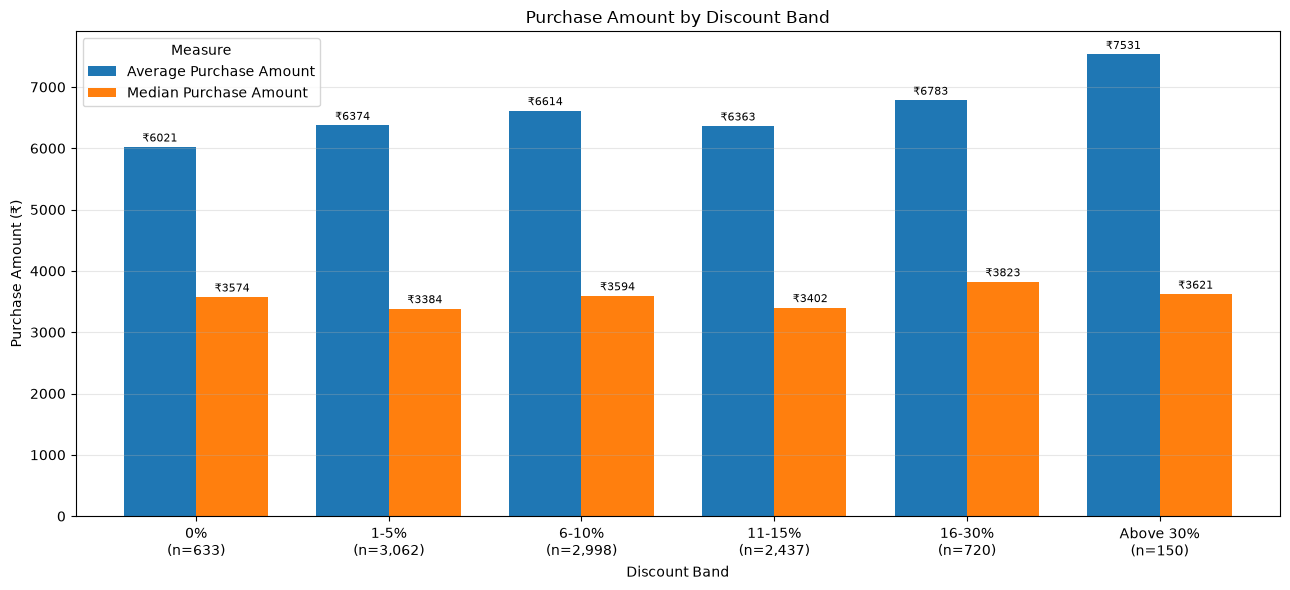

In [108]:
# Compare typical purchase values across discount bands
purchase_amount_plot = (
    discount_plot
    .set_index("Discount Band Label")
    [
        [
            "Average_Purchase_Amount",
            "Median_Purchase_Amount"
        ]
    ]
    .rename(
        columns={
            "Average_Purchase_Amount":
                "Average Purchase Amount",

            "Median_Purchase_Amount":
                "Median Purchase Amount"
        }
    )
)

ax = purchase_amount_plot.plot(
    kind="bar",
    figsize=(13, 6),
    width=0.75
)

plt.title("Purchase Amount by Discount Band")
plt.xlabel("Discount Band")
plt.ylabel("Purchase Amount (₹)")
plt.xticks(rotation=0)
plt.grid(axis="y", alpha=0.3)
plt.legend(title="Measure")

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="₹%.0f",
        padding=2,
        fontsize=8
    )

plt.tight_layout()
save_figure(
    "h5_purchase_amount_by_discount_band.png"
)
plt.show()

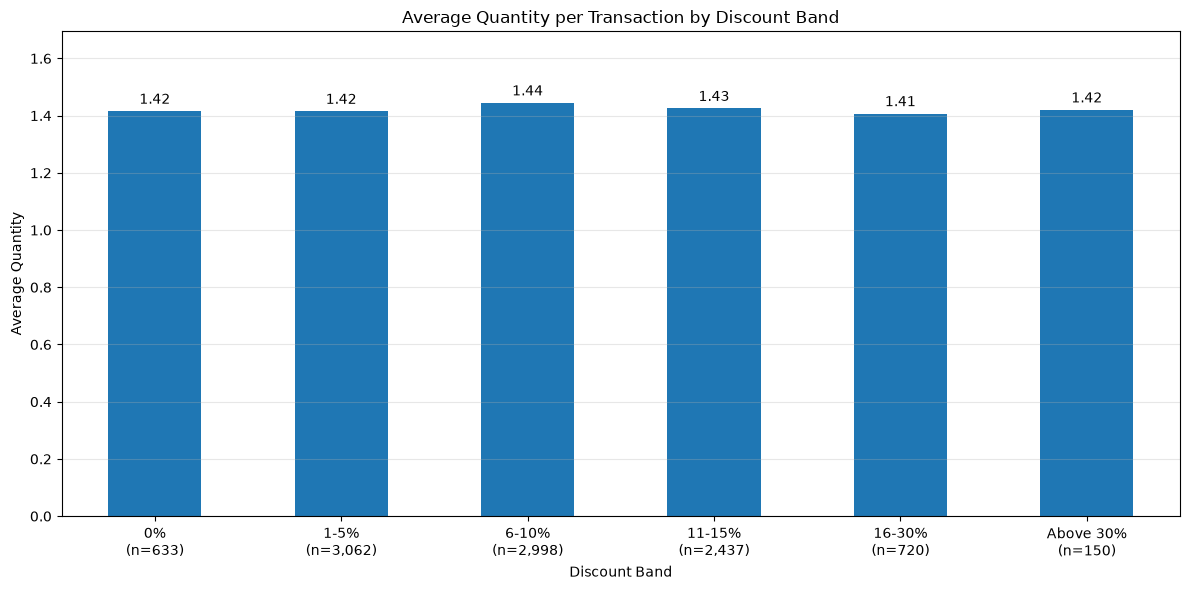

In [109]:
# Compare basket size across discount bands
quantity_plot = (
    discount_plot
    .set_index("Discount Band Label")
)

ax = quantity_plot["Average_Quantity"].plot(
    kind="bar",
    figsize=(12, 6)
)

plt.title("Average Quantity per Transaction by Discount Band")
plt.xlabel("Discount Band")
plt.ylabel("Average Quantity")
plt.xticks(rotation=0)

plt.ylim(
    0,
    quantity_plot["Average_Quantity"].max() + 0.25
)

plt.grid(axis="y", alpha=0.3)

ax.bar_label(
    ax.containers[0],
    fmt="%.2f",
    padding=3
)

plt.tight_layout()
save_figure(
    "h5_avg_quantity_per_transaction_by_discount_band.png"
)
plt.show()

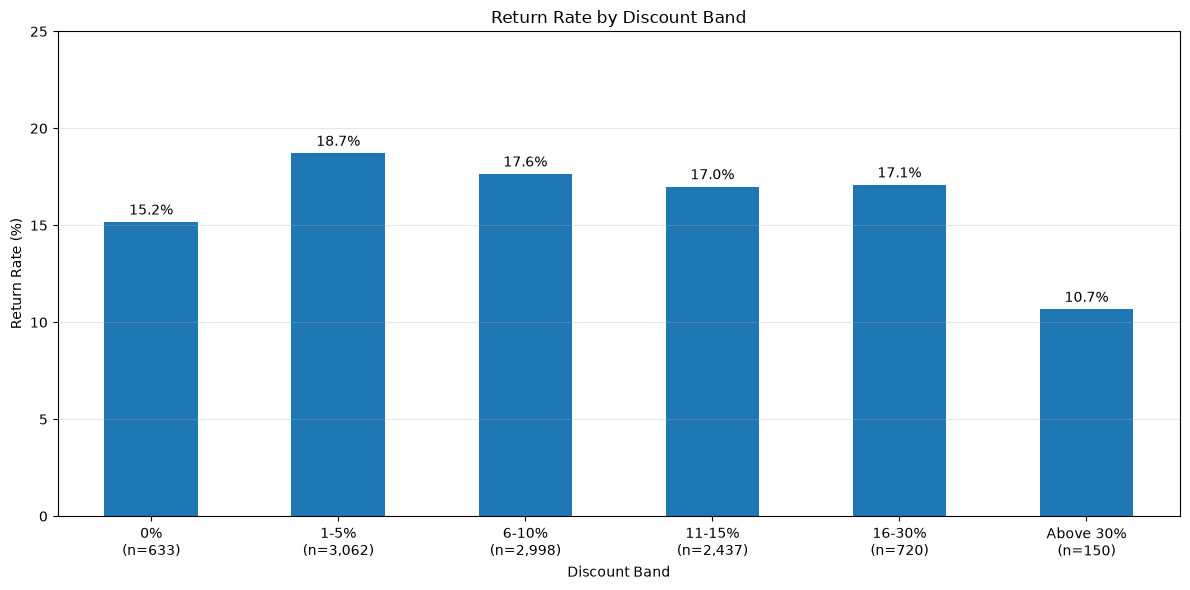

In [110]:
# Compare customer return behaviour across discount bands
return_rate_plot = (
    discount_plot
    .set_index("Discount Band Label")
)

ax = return_rate_plot["Return Rate (%)"].plot(
    kind="bar",
    figsize=(12, 6)
)

plt.title("Return Rate by Discount Band")
plt.xlabel("Discount Band")
plt.ylabel("Return Rate (%)")
plt.xticks(rotation=0)
plt.ylim(0, 25)
plt.grid(axis="y", alpha=0.3)

ax.bar_label(
    ax.containers[0],
    fmt="%.1f%%",
    padding=3
)

plt.tight_layout()
save_figure(
    "h5_return_rate_by_discount_band.png"
)
plt.show()

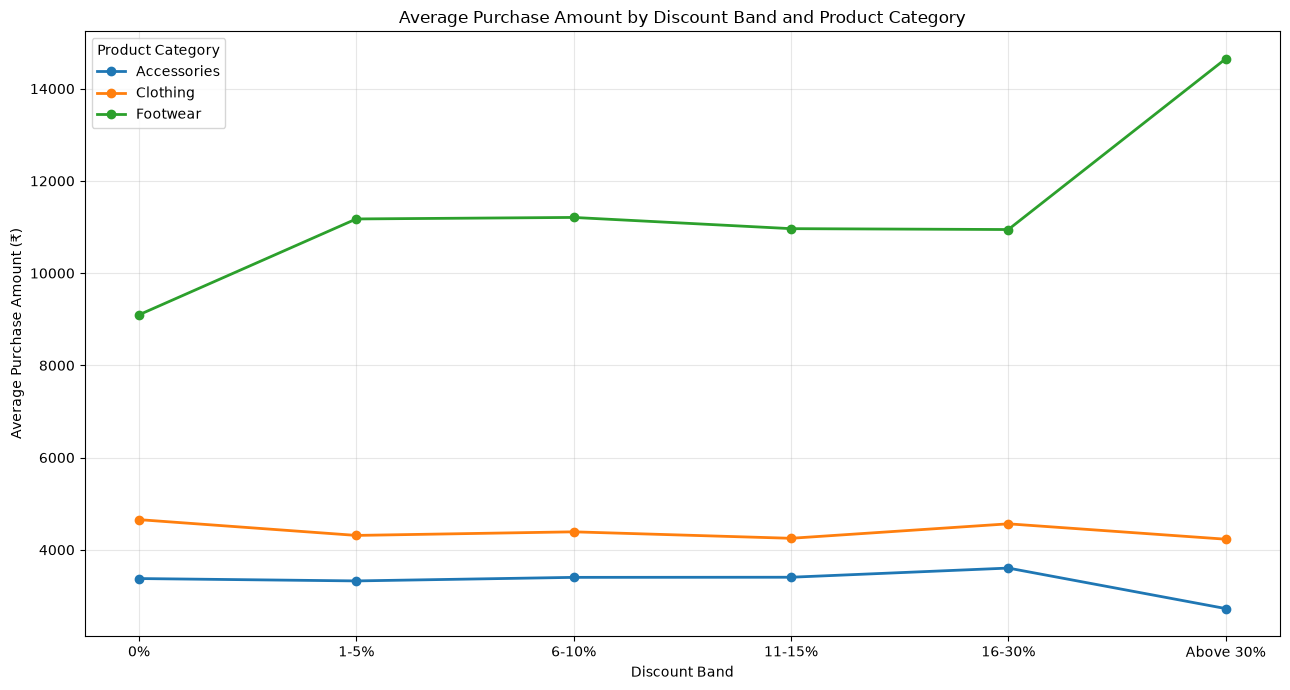

In [111]:
# Compare discount patterns separately within each product category
ax = category_discount_purchase_pivot.plot(
    kind="line",
    marker="o",
    figsize=(13, 7),
    linewidth=2
)

plt.title(
    "Average Purchase Amount by Discount Band and Product Category"
)
plt.xlabel("Discount Band")
plt.ylabel("Average Purchase Amount (₹)")
plt.xticks(
    range(len(category_discount_purchase_pivot.index)),
    category_discount_purchase_pivot.index,
    rotation=0
)
plt.grid(alpha=0.3)
plt.legend(title="Product Category")

plt.tight_layout()
save_figure(
    "h5_avg_purchase_amount_by_discount_band_and_product_category.png"
)
plt.show()

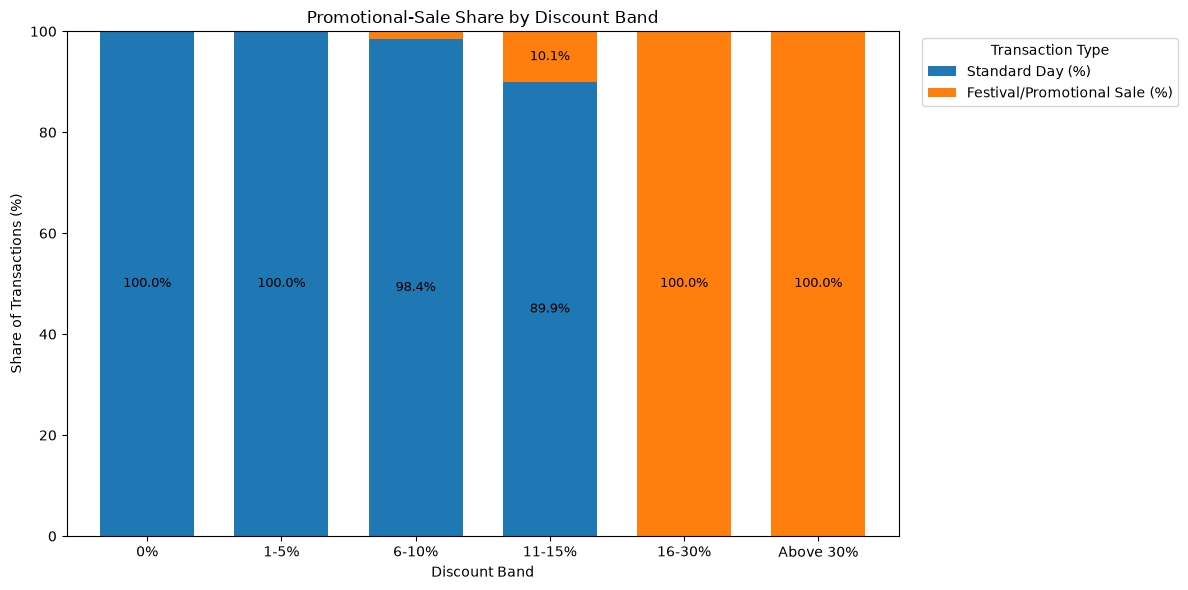

In [112]:
# Show how promotional transactions are distributed across discount bands
ax = discount_promotion_share.plot(
    kind="bar",
    stacked=True,
    figsize=(12, 6),
    width=0.7
)

plt.title("Promotional-Sale Share by Discount Band")
plt.xlabel("Discount Band")
plt.ylabel("Share of Transactions (%)")
plt.xticks(rotation=0)
plt.ylim(0, 100)
plt.legend(
    title="Transaction Type",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

for container in ax.containers:
    labels = [
        f"{value:.1f}%"
        if value >= 5
        else ""
        for value in container.datavalues
    ]

    ax.bar_label(
        container,
        labels=labels,
        label_type="center",
        fontsize=9
    )

plt.tight_layout()
save_figure(
    "h5_promotional_sale_share_by_discount_band.png"
)
plt.show()

### Visual Comparison Results

**Purchase amount**

- Average purchase amount did not increase consistently across discount bands.
- The Above 30% band recorded the highest average, but contained only 150 transactions.
- Median purchase amount followed a different pattern.

**Basket size**

- Average quantity remained between 1.41 and 1.44 units.
- Larger discounts were not associated with larger baskets.

**Return behaviour**

- Return rates did not increase with discount level.
- The Above 30% band recorded the lowest observed return rate.

**Product category**

- Footwear had a much higher purchase amount across every discount band.
- Product category explained more variation than discount percentage.

**Promotional overlap**

- High-discount transactions were entirely promotional.
- Their outcomes cannot be attributed to discount percentage alone.

## Hypothesis 5 Verdict

**Verdict: Mostly not supported**

The hypothesis expected larger discounts to be associated with higher purchase amounts, larger basket quantities, and higher return rates.

The purchase-amount expectation received only limited support. The Above 30% band recorded the highest average purchase amount, but purchase amount did not increase consistently across the discount bands. Median purchase amount also fluctuated, and the Spearman correlation between discount percentage and purchase amount was close to zero.

The quantity expectation was not supported. Average quantity remained almost identical across all discount levels, and the correlation between discount percentage and quantity was also close to zero.

The return-rate expectation was not supported. Return rates did not rise consistently with discount level, and the largest discount band recorded the lowest observed return rate.

Product category had a much clearer relationship with purchase amount than discount percentage. Footwear produced substantially higher average purchase amounts across every discount band, while Clothing and Accessories showed relatively limited variation.

The highest discount bands were also entirely composed of promotional-sale transactions. Discount level and promotional status were therefore closely connected, preventing the high-discount results from being attributed to discount percentage alone.

Within this synthetic dataset, larger discounts were not consistently associated with greater spending, larger baskets, or more returns. The isolated high average purchase amount in the Above 30% band appears to reflect a combination of Footwear purchases, promotional transactions, and a relatively small group size rather than a general discount-driven pattern.

## Hypothesis 6: Customer Experience, Delivery, and Returns

### Question

Which delivery conditions are associated with better customer ratings and lower return rates, and how do these outcomes vary across product categories and online stores?

### Hypothesis

Faster delivery may be associated with higher review ratings and lower return rates, while longer delivery times may result in poorer customer outcomes.

Free shipping may also be associated with slightly better ratings and fewer returns than paid shipping.

Transactions receiving lower ratings may have substantially higher return rates than highly rated transactions.

Online stores with shorter delivery times and better ratings may also record lower return rates.

### Measures

Customer experience will be evaluated using:

- transaction count and transaction share;
- average review rating;
- low-rating share;
- high-rating share;
- returned transactions;
- return rate;
- average delivery time;
- delivery-speed category;
- shipping-charge level;
- free-shipping share;
- online-store performance.

The analysis will compare:

- review-rating levels;
- returned and non-returned transactions;
- delivery-speed categories;
- exact delivery times;
- delivery-time bands;
- free and paid shipping;
- shipping-charge levels;
- online stores;
- delivery outcomes within product categories.

### Visual Analysis

The visual analysis will examine:

1. return rate across review-rating levels;
2. ratings and return rates across delivery times;
3. delivery outcomes by delivery-time band;
4. free versus paid shipping;
5. customer-experience outcomes across online stores.

### Interpretation Rule

The analysis identifies associations and does not establish that delivery conditions caused ratings or returns.

Offline purchases do not involve delivery in this dataset. Delivery-time, delivery-speed, and shipping-charge analyses will therefore use online transactions only.

### Analysis 6A: Delivery-Field Validation

Delivery fields are inspected separately for online and offline transactions.

This confirms that offline purchases are correctly marked as not requiring delivery and that online delivery-speed labels agree with the recorded delivery times.

In [113]:
# Check whether delivery-speed values are consistent with shopping channel
channel_delivery_table = pd.crosstab(
    df["Online/Offline"],
    df["Delivery Speed"]
)

display(channel_delivery_table)

Delivery Speed,Express,N/A (Offline),Same Day,Standard
Online/Offline,,,,
Offline,0,2583,0,0
Online,2167,0,729,4521


In [114]:
# Check whether delivery-time values match the delivery-speed categories
delivery_speed_time_validation = (
    df.groupby(
        "Delivery Speed",
        as_index=False,
        observed=True
    )
    .agg(
        Transaction_Count=(
            "Transaction ID",
            "nunique"
        ),
        Minimum_Delivery_Time=(
            "Delivery Time (Days)",
            "min"
        ),
        Maximum_Delivery_Time=(
            "Delivery Time (Days)",
            "max"
        ),
        Average_Delivery_Time=(
            "Delivery Time (Days)",
            "mean"
        )
    )
)

display(delivery_speed_time_validation.round(2))

,Delivery Speed,Transaction_Count,Minimum_Delivery_Time,Maximum_Delivery_Time,Average_Delivery_Time
0,Express,2167,1,2,1.49
1,N/A (Offline),2583,0,0,0.00
2,Same Day,729,0,0,0.00
3,Standard,4521,3,7,4.99


In [115]:
# Restrict delivery analysis to online transactions
online_experience = df[
    df["Online/Offline"] == "Online"
].copy()

print(
    "Online transactions:",
    f"{len(online_experience):,}"
)

print(
    "Missing delivery-speed values:",
    online_experience["Delivery Speed"].isna().sum()
)

print(
    "Missing delivery-time values:",
    online_experience["Delivery Time (Days)"].isna().sum()
)

print(
    "Missing shipping-charge values:",
    online_experience["Shipping Charge (₹)"].isna().sum()
)

Online transactions: 7,417
Missing delivery-speed values: 0
Missing delivery-time values: 0
Missing shipping-charge values: 0


In [116]:
# Confirm that offline transactions do not contain online delivery values
offline_experience = df[
    df["Online/Offline"] == "Offline"
]

print(
    "Offline transactions not marked N/A:",
    (
        offline_experience["Delivery Speed"]
        != "N/A (Offline)"
    ).sum()
)

print(
    "Offline transactions with non-zero delivery time:",
    (
        offline_experience["Delivery Time (Days)"]
        != 0
    ).sum()
)

print(
    "Offline transactions with shipping charges:",
    (
        offline_experience["Shipping Charge (₹)"]
        != 0
    ).sum()
)

Offline transactions not marked N/A: 0
Offline transactions with non-zero delivery time: 0
Offline transactions with shipping charges: 0


#### Delivery-Field Validation Results

**Channel consistency**

- All 2,583 offline transactions were correctly labelled `N/A (Offline)`.
- All 7,417 online transactions were assigned to Same Day, Express, or Standard delivery.
- No online transaction had missing delivery-speed, delivery-time, or shipping-charge information.

**Delivery-speed consistency**

- Same Day delivery contained 729 transactions and consistently recorded zero delivery days.
- Express delivery contained 2,167 transactions, ranged from one to two days, and averaged 1.49 days.
- Standard delivery contained 4,521 transactions, ranged from three to seven days, and averaged 4.99 days.
- Offline transactions consistently recorded zero delivery days and zero shipping charges.

**Conclusion**

- Delivery fields are internally consistent and suitable for online customer-experience analysis.

### Analysis 6B: Relationship Between Ratings and Returns

Review-rating levels are compared with return behaviour to determine whether poorly rated transactions are more likely to be returned.

In [117]:
# Summarize transaction and return behaviour across review ratings
rating_return_summary = (
    df.groupby(
        "Review Rating",
        as_index=False,
        observed=True
    )
    .agg(
        Transaction_Count=(
            "Transaction ID",
            "nunique"
        ),
        Returned_Transactions=(
            "Returned",
            "sum"
        ),
        Average_Purchase_Amount=(
            "Purchase Amount (₹)",
            "mean"
        )
    )
)

rating_return_summary["Transaction Share (%)"] = (
    rating_return_summary["Transaction_Count"]
    / df["Transaction ID"].nunique()
    * 100
)

rating_return_summary["Return Rate (%)"] = (
    rating_return_summary["Returned_Transactions"]
    / rating_return_summary["Transaction_Count"]
    * 100
)

rating_return_summary = rating_return_summary[
    [
        "Review Rating",
        "Transaction_Count",
        "Transaction Share (%)",
        "Returned_Transactions",
        "Return Rate (%)",
        "Average_Purchase_Amount"
    ]
]

display(rating_return_summary.round(2))

,Review Rating,Transaction_Count,Transaction Share (%),Returned_Transactions,Return Rate (%),Average_Purchase_Amount
0,1,102,1.02,46,45.10,"3,228.22"
1,2,1181,11.81,494,41.83,"4,154.81"
2,3,3613,36.13,512,14.17,"5,793.15"
3,4,4027,40.27,552,13.71,"7,514.05"
4,5,1077,10.77,147,13.65,"7,661.18"


In [118]:
# Compare customer ratings for returned and retained purchases
return_status_experience = (
    df.groupby(
        "Return Status",
        as_index=False,
        observed=True
    )
    .agg(
        Transaction_Count=(
            "Transaction ID",
            "nunique"
        ),
        Average_Rating=(
            "Review Rating",
            "mean"
        ),
        Average_Purchase_Amount=(
            "Purchase Amount (₹)",
            "mean"
        ),
        Average_Quantity=(
            "Quantity",
            "mean"
        )
    )
)

display(return_status_experience.round(2))

,Return Status,Transaction_Count,Average_Rating,Average_Purchase_Amount,Average_Quantity
0,Not Returned,8249,3.55,"6,535.52",1.42
1,Returned,1751,3.15,"6,148.18",1.45


In [119]:
# Measure the association between review rating and return status
rating_return_correlation = (
    df[
        [
            "Review Rating",
            "Returned"
        ]
    ]
    .assign(
        Returned=lambda data:
            data["Returned"].astype(int)
    )
    .corr(method="spearman")
    .loc[
        "Review Rating",
        "Returned"
    ]
)

print(
    "Spearman correlation between rating and return status:",
    f"{rating_return_correlation:.4f}"
)

Spearman correlation between rating and return status: -0.1574


#### Rating and Return Results

**Rating distribution**

- Four-star ratings were most common, representing 40.27% of transactions, followed by three-star ratings at 36.13%.
- One-star ratings represented only 1.02%, while two-star ratings represented 11.81%.

**Return behaviour**

- One-star transactions recorded a 45.10% return rate, and two-star transactions recorded a 41.83% return rate.
- Return rates dropped sharply to 14.17% for three-star transactions, 13.71% for four-star transactions, and 13.65% for five-star transactions.
- This indicates that the clearest difference occurs between ratings of two or below and ratings of three or above.

**Returned versus retained transactions**

- Returned transactions averaged a rating of 3.15, compared with 3.55 for non-returned transactions.
- Returned transactions also had a slightly lower average purchase amount of ₹6,148.18, compared with ₹6,535.52 for retained purchases.
- Average quantity was almost identical between the two groups.

**Association**

- Review rating and return status had a Spearman correlation of −0.1574.
- The relationship was negative but not strong, meaning higher ratings were generally associated with fewer returns without ratings fully explaining return behaviour.

### Analysis 6C: Customer Experience by Delivery Speed

Online delivery-speed categories are compared using delivery time, ratings, shipping charges, and returns.

In [120]:
# Summarize customer outcomes for each delivery-speed category
delivery_speed_summary = (
    online_experience
    .groupby(
        "Delivery Speed",
        as_index=False,
        observed=True
    )
    .agg(
        Transaction_Count=(
            "Transaction ID",
            "nunique"
        ),
        Average_Delivery_Time=(
            "Delivery Time (Days)",
            "mean"
        ),
        Average_Rating=(
            "Review Rating",
            "mean"
        ),
        Low_Rating_Transactions=(
            "Review Rating",
            lambda values:
                values.le(2).sum()
        ),
        High_Rating_Transactions=(
            "Review Rating",
            lambda values:
                values.ge(4).sum()
        ),
        Returned_Transactions=(
            "Returned",
            "sum"
        ),
        Average_Shipping_Charge=(
            "Shipping Charge (₹)",
            "mean"
        ),
        Free_Shipping_Transactions=(
            "Shipping Charge (₹)",
            lambda values:
                values.eq(0).sum()
        )
    )
)

delivery_speed_summary["Transaction Share (%)"] = (
    delivery_speed_summary["Transaction_Count"]
    / len(online_experience)
    * 100
)

delivery_speed_summary["Low Rating Share (%)"] = (
    delivery_speed_summary["Low_Rating_Transactions"]
    / delivery_speed_summary["Transaction_Count"]
    * 100
)

delivery_speed_summary["High Rating Share (%)"] = (
    delivery_speed_summary["High_Rating_Transactions"]
    / delivery_speed_summary["Transaction_Count"]
    * 100
)

delivery_speed_summary["Return Rate (%)"] = (
    delivery_speed_summary["Returned_Transactions"]
    / delivery_speed_summary["Transaction_Count"]
    * 100
)

delivery_speed_summary["Free Shipping Share (%)"] = (
    delivery_speed_summary["Free_Shipping_Transactions"]
    / delivery_speed_summary["Transaction_Count"]
    * 100
)

delivery_speed_order = [
    "Same Day",
    "Express",
    "Standard"
]

delivery_speed_summary["Delivery Speed"] = (
    pd.Categorical(
        delivery_speed_summary["Delivery Speed"],
        categories=delivery_speed_order,
        ordered=True
    )
)

delivery_speed_summary = (
    delivery_speed_summary
    .sort_values("Delivery Speed")
)

display(delivery_speed_summary.round(2))

,Delivery Speed,Transaction_Count,Average_Delivery_Time,Average_Rating,Low_Rating_Transactions,High_Rating_Transactions,Returned_Transactions,Average_Shipping_Charge,Free_Shipping_Transactions,Transaction Share (%),Low Rating Share (%),High Rating Share (%),Return Rate (%),Free Shipping Share (%)
1,Same Day,729,0.00,3.66,47,439,123,28.83,348,9.83,6.45,60.22,16.87,47.74
0,Express,2167,1.49,3.67,152,1310,356,27.57,1035,29.22,7.01,60.45,16.43,47.76
2,Standard,4521,4.99,3.26,912,1818,851,27.42,2230,60.95,20.17,40.21,18.82,49.33


#### Delivery-Speed Results

**Delivery distribution**

- Standard delivery accounted for 60.95% of online transactions.
- Express delivery represented 29.22%, while Same Day delivery represented 9.83%.

**Customer ratings**

- Same Day and Express delivery produced similar average ratings of 3.66 and 3.67.
- Standard delivery recorded a considerably lower average rating of 3.26.
- Low ratings represented only 6.45% of Same Day and 7.01% of Express transactions, compared with 20.17% of Standard transactions.
- High-rating shares were approximately 60% for Same Day and Express delivery but only 40.21% for Standard delivery.

**Returns**

- Express delivery recorded the lowest return rate at 16.43%.
- Same Day delivery recorded 16.87%, while Standard delivery recorded the highest rate at 18.82%.
- Faster delivery was therefore associated with better ratings, although Same Day delivery did not outperform Express delivery on returns.

**Shipping**

- Average shipping charges and free-shipping shares were similar across all delivery-speed categories.
- These shipping differences are too small to explain the substantial rating gap between faster and Standard delivery.

### Analysis 6D: Customer Experience by Delivery Time

Exact delivery times are examined to determine whether customer ratings and return rates change as delivery takes longer.

In [121]:
# Compare customer outcomes for each recorded delivery day
delivery_day_summary = (
    online_experience
    .groupby(
        "Delivery Time (Days)",
        as_index=False,
        observed=True
    )
    .agg(
        Transaction_Count=(
            "Transaction ID",
            "nunique"
        ),
        Average_Rating=(
            "Review Rating",
            "mean"
        ),
        Low_Rating_Transactions=(
            "Review Rating",
            lambda values:
                values.le(2).sum()
        ),
        High_Rating_Transactions=(
            "Review Rating",
            lambda values:
                values.ge(4).sum()
        ),
        Returned_Transactions=(
            "Returned",
            "sum"
        ),
        Average_Shipping_Charge=(
            "Shipping Charge (₹)",
            "mean"
        )
    )
)

delivery_day_summary["Low Rating Share (%)"] = (
    delivery_day_summary["Low_Rating_Transactions"]
    / delivery_day_summary["Transaction_Count"]
    * 100
)

delivery_day_summary["High Rating Share (%)"] = (
    delivery_day_summary["High_Rating_Transactions"]
    / delivery_day_summary["Transaction_Count"]
    * 100
)

delivery_day_summary["Return Rate (%)"] = (
    delivery_day_summary["Returned_Transactions"]
    / delivery_day_summary["Transaction_Count"]
    * 100
)

display(delivery_day_summary.round(2))

,Delivery Time (Days),Transaction_Count,Average_Rating,Low_Rating_Transactions,High_Rating_Transactions,Returned_Transactions,Average_Shipping_Charge,Low Rating Share (%),High Rating Share (%),Return Rate (%)
0,0,729,3.66,47,439,123,28.83,6.45,60.22,16.87
1,1,1102,3.65,87,654,188,27.16,7.89,59.35,17.06
2,2,1065,3.69,65,656,168,27.99,6.10,61.60,15.77
3,3,952,3.68,66,570,138,28.05,6.93,59.87,14.50
4,4,904,3.62,73,524,142,26.87,8.08,57.96,15.71
5,5,824,3.62,71,475,121,27.29,8.62,57.65,14.68
6,6,906,2.68,345,109,216,26.38,38.08,12.03,23.84
7,7,935,2.72,357,140,234,28.44,38.18,14.97,25.03


In [122]:
# Group delivery times into fast, moderate, and long ranges
delivery_time_bins = [
    -0.01,
    2,
    5,
    7
]

delivery_time_labels = [
    "0-2 Days",
    "3-5 Days",
    "6-7 Days"
]

online_experience["Delivery Time Band"] = pd.cut(
    online_experience["Delivery Time (Days)"],
    bins=delivery_time_bins,
    labels=delivery_time_labels,
    ordered=True
)

In [123]:
# Summarize customer outcomes across delivery-time bands
delivery_time_band_summary = (
    online_experience
    .groupby(
        "Delivery Time Band",
        as_index=False,
        observed=True
    )
    .agg(
        Transaction_Count=(
            "Transaction ID",
            "nunique"
        ),
        Average_Delivery_Time=(
            "Delivery Time (Days)",
            "mean"
        ),
        Average_Rating=(
            "Review Rating",
            "mean"
        ),
        Low_Rating_Transactions=(
            "Review Rating",
            lambda values:
                values.le(2).sum()
        ),
        High_Rating_Transactions=(
            "Review Rating",
            lambda values:
                values.ge(4).sum()
        ),
        Returned_Transactions=(
            "Returned",
            "sum"
        )
    )
)

delivery_time_band_summary["Transaction Share (%)"] = (
    delivery_time_band_summary["Transaction_Count"]
    / len(online_experience)
    * 100
)

delivery_time_band_summary["Low Rating Share (%)"] = (
    delivery_time_band_summary["Low_Rating_Transactions"]
    / delivery_time_band_summary["Transaction_Count"]
    * 100
)

delivery_time_band_summary["High Rating Share (%)"] = (
    delivery_time_band_summary["High_Rating_Transactions"]
    / delivery_time_band_summary["Transaction_Count"]
    * 100
)

delivery_time_band_summary["Return Rate (%)"] = (
    delivery_time_band_summary["Returned_Transactions"]
    / delivery_time_band_summary["Transaction_Count"]
    * 100
)

display(delivery_time_band_summary.round(2))

,Delivery Time Band,Transaction_Count,Average_Delivery_Time,Average_Rating,Low_Rating_Transactions,High_Rating_Transactions,Returned_Transactions,Transaction Share (%),Low Rating Share (%),High Rating Share (%),Return Rate (%)
0,0-2 Days,2896,1.12,3.67,199,1749,479,39.05,6.87,60.39,16.54
1,3-5 Days,2680,3.95,3.64,210,1569,401,36.13,7.84,58.54,14.96
2,6-7 Days,1841,6.51,2.70,702,249,450,24.82,38.13,13.53,24.44


#### Delivery-Time Results

**Exact delivery days**

- Customer ratings remained relatively stable between zero and five delivery days, ranging from 3.62 to 3.69.
- Ratings then dropped sharply to 2.68 at six days and 2.72 at seven days.
- Low-rating shares remained between 6.10% and 8.62% for delivery times of zero to five days.
- They increased to approximately 38% for both six-day and seven-day deliveries.
- High-rating shares fell from approximately 58–62% during the first five days to 12.03% at six days and 14.97% at seven days.

**Returns**

- Return rates ranged from 14.50% to 17.06% for delivery times of zero to five days.
- They rose to 23.84% at six days and 25.03% at seven days.
- Return rate did not improve consistently with every reduction in delivery time because the 3–5 Day band performed slightly better than the 0–2 Day band.

**Delivery-time bands**

- The 6–7 Day group represented 24.82% of online transactions.
- It recorded an average rating of 2.70, compared with 3.67 for 0–2 Days and 3.64 for 3–5 Days.
- Its low-rating share reached 38.13%, compared with less than 8% in the faster groups.
- Its return rate reached 24.44%, compared with 16.54% for 0–2 Days and 14.96% for 3–5 Days.

**Conclusion**

- Customer outcomes did not deteriorate gradually with every additional delivery day.
- Instead, the results reveal a major deterioration when delivery extended to six or seven days.

### Analysis 6E: Shipping Charges and Customer Experience

Free and paid shipping are compared first.

Individual shipping-charge levels are then examined to determine whether larger charges are associated with different ratings or return rates.

In [124]:
# Classify online transactions as free or paid shipping
online_experience["Shipping Type"] = np.where(
    online_experience["Shipping Charge (₹)"] == 0,
    "Free Shipping",
    "Paid Shipping"
)

In [125]:
# Compare customer outcomes for free and paid shipping
shipping_type_summary = (
    online_experience
    .groupby(
        "Shipping Type",
        as_index=False,
        observed=True
    )
    .agg(
        Transaction_Count=(
            "Transaction ID",
            "nunique"
        ),
        Average_Shipping_Charge=(
            "Shipping Charge (₹)",
            "mean"
        ),
        Average_Delivery_Time=(
            "Delivery Time (Days)",
            "mean"
        ),
        Average_Rating=(
            "Review Rating",
            "mean"
        ),
        Low_Rating_Transactions=(
            "Review Rating",
            lambda values:
                values.le(2).sum()
        ),
        Returned_Transactions=(
            "Returned",
            "sum"
        ),
        Average_Purchase_Amount=(
            "Purchase Amount (₹)",
            "mean"
        )
    )
)

shipping_type_summary["Transaction Share (%)"] = (
    shipping_type_summary["Transaction_Count"]
    / len(online_experience)
    * 100
)

shipping_type_summary["Low Rating Share (%)"] = (
    shipping_type_summary["Low_Rating_Transactions"]
    / shipping_type_summary["Transaction_Count"]
    * 100
)

shipping_type_summary["Return Rate (%)"] = (
    shipping_type_summary["Returned_Transactions"]
    / shipping_type_summary["Transaction_Count"]
    * 100
)

display(shipping_type_summary.round(2))

,Shipping Type,Transaction_Count,Average_Shipping_Charge,Average_Delivery_Time,Average_Rating,Low_Rating_Transactions,Returned_Transactions,Average_Purchase_Amount,Transaction Share (%),Low Rating Share (%),Return Rate (%)
0,Free Shipping,3613,0.00,3.50,3.42,539,641,"6,520.71",48.71,14.92,17.74
1,Paid Shipping,3804,53.82,3.46,3.41,572,689,"6,377.03",51.29,15.04,18.11


In [126]:
# Compare customer outcomes across recorded shipping-charge levels
shipping_charge_summary = (
    online_experience
    .groupby(
        "Shipping Charge (₹)",
        as_index=False,
        observed=True
    )
    .agg(
        Transaction_Count=(
            "Transaction ID",
            "nunique"
        ),
        Average_Delivery_Time=(
            "Delivery Time (Days)",
            "mean"
        ),
        Average_Rating=(
            "Review Rating",
            "mean"
        ),
        Low_Rating_Transactions=(
            "Review Rating",
            lambda values:
                values.le(2).sum()
        ),
        Returned_Transactions=(
            "Returned",
            "sum"
        ),
        Average_Purchase_Amount=(
            "Purchase Amount (₹)",
            "mean"
        )
    )
)

shipping_charge_summary["Transaction Share (%)"] = (
    shipping_charge_summary["Transaction_Count"]
    / len(online_experience)
    * 100
)

shipping_charge_summary["Low Rating Share (%)"] = (
    shipping_charge_summary["Low_Rating_Transactions"]
    / shipping_charge_summary["Transaction_Count"]
    * 100
)

shipping_charge_summary["Return Rate (%)"] = (
    shipping_charge_summary["Returned_Transactions"]
    / shipping_charge_summary["Transaction_Count"]
    * 100
)

display(shipping_charge_summary.round(2))

,Shipping Charge (₹),Transaction_Count,Average_Delivery_Time,Average_Rating,Low_Rating_Transactions,Returned_Transactions,Average_Purchase_Amount,Transaction Share (%),Low Rating Share (%),Return Rate (%)
0,0,3613,3.50,3.42,539,641,"6,520.71",48.71,14.92,17.74
1,40,2219,3.42,3.41,322,401,"6,490.67",29.92,14.51,18.07
2,60,1050,3.53,3.43,161,183,"5,624.60",14.16,15.33,17.43
3,99,535,3.44,3.38,89,105,"7,382.46",7.21,16.64,19.63


In [127]:
# Measure associations between delivery conditions, ratings, and returns
delivery_association_data = online_experience[
    [
        "Delivery Time (Days)",
        "Shipping Charge (₹)",
        "Review Rating"
    ]
].copy()

delivery_association_data["Returned Flag"] = (
    online_experience["Returned"].astype(int)
)

delivery_correlations = (
    delivery_association_data
    .corr(method="spearman")
)

display(delivery_correlations.round(4))

,Delivery Time (Days),Shipping Charge (₹),Review Rating,Returned Flag
Delivery Time (Days),1.00,-0.01,-0.35,0.06
Shipping Charge (₹),-0.01,1.00,-0.01,0.01
Review Rating,-0.35,-0.01,1.00,-0.18
Returned Flag,0.06,0.01,-0.18,1.00


#### Shipping-Charge Results

**Free versus paid shipping**

- Free shipping represented 48.71% of online transactions, while paid shipping represented 51.29%.
- Average ratings were nearly identical at 3.42 for free shipping and 3.41 for paid shipping.
- Low-rating shares were also almost identical at 14.92% and 15.04%.
- Free shipping recorded a return rate of 17.74%, compared with 18.11% for paid shipping.
- The difference of 0.37 percentage points is too small to indicate a meaningful advantage.

**Individual shipping charges**

- Transactions with a ₹99 shipping charge recorded the lowest average rating at 3.38 and the highest return rate at 19.63%.
- However, this group represented only 7.21% of online transactions.
- Outcomes did not change consistently as shipping charges increased across ₹0, ₹40, ₹60, and ₹99.

**Associations**

- Shipping charge had correlations of approximately −0.01 with rating and 0.01 with return status.
- These values indicate almost no meaningful relationship between shipping-charge amount and customer outcomes.
- Delivery time had a moderate negative correlation of −0.35 with review rating.
- Delivery time had only a weak positive correlation of 0.06 with return status.
- Rating and return status had a negative correlation of −0.18 within online transactions.

**Conclusion**

- Free shipping was not meaningfully associated with better customer ratings or fewer returns.
- Delivery time showed a much clearer relationship with customer experience than shipping-charge amount.

### Analysis 6F: Customer Experience by Online Store

Online stores are compared using delivery time, free-shipping availability, customer ratings, and return rates.

Commercial rankings were already examined in Hypothesis 4, so this section focuses only on after-purchase experience.

In [128]:
# Compare operational and customer-experience outcomes across online stores
store_experience_summary = (
    online_experience
    .groupby(
        "Online Store",
        as_index=False,
        observed=True
    )
    .agg(
        Transaction_Count=(
            "Transaction ID",
            "nunique"
        ),
        Average_Delivery_Time=(
            "Delivery Time (Days)",
            "mean"
        ),
        Average_Shipping_Charge=(
            "Shipping Charge (₹)",
            "mean"
        ),
        Free_Shipping_Transactions=(
            "Shipping Charge (₹)",
            lambda values:
                values.eq(0).sum()
        ),
        Average_Rating=(
            "Review Rating",
            "mean"
        ),
        Low_Rating_Transactions=(
            "Review Rating",
            lambda values:
                values.le(2).sum()
        ),
        High_Rating_Transactions=(
            "Review Rating",
            lambda values:
                values.ge(4).sum()
        ),
        Returned_Transactions=(
            "Returned",
            "sum"
        )
    )
)

store_experience_summary["Free Shipping Share (%)"] = (
    store_experience_summary["Free_Shipping_Transactions"]
    / store_experience_summary["Transaction_Count"]
    * 100
)

store_experience_summary["Low Rating Share (%)"] = (
    store_experience_summary["Low_Rating_Transactions"]
    / store_experience_summary["Transaction_Count"]
    * 100
)

store_experience_summary["High Rating Share (%)"] = (
    store_experience_summary["High_Rating_Transactions"]
    / store_experience_summary["Transaction_Count"]
    * 100
)

store_experience_summary["Return Rate (%)"] = (
    store_experience_summary["Returned_Transactions"]
    / store_experience_summary["Transaction_Count"]
    * 100
)

store_experience_summary = (
    store_experience_summary
    .sort_values(
        "Return Rate (%)"
    )
)

display(store_experience_summary.round(2))

,Online Store,Transaction_Count,Average_Delivery_Time,Average_Shipping_Charge,Free_Shipping_Transactions,Average_Rating,Low_Rating_Transactions,High_Rating_Transactions,Returned_Transactions,Free Shipping Share (%),Low Rating Share (%),High Rating Share (%),Return Rate (%)
0,Ajio,1276,3.43,26.52,635,3.46,173,639,213,49.76,13.56,50.08,16.69
3,Meesho,1277,3.47,27.23,626,3.42,178,606,217,49.02,13.94,47.45,16.99
5,Nykaa,1205,3.47,28.04,585,3.41,186,577,210,48.55,15.44,47.88,17.43
2,Flipkart,1212,3.52,28.76,568,3.42,196,595,218,46.86,16.17,49.09,17.99
4,Myntra,1218,3.43,27.24,593,3.44,161,589,224,48.69,13.22,48.36,18.39
1,Amazon,1229,3.56,27.91,606,3.35,217,561,248,49.31,17.66,45.65,20.18


In [129]:
# Identify leading stores on customer-experience measures
store_experience_metrics = {
    "Shortest average delivery time":
        (
            "Average_Delivery_Time",
            "min"
        ),

    "Highest average rating":
        (
            "Average_Rating",
            "max"
        ),

    "Lowest low-rating share":
        (
            "Low Rating Share (%)",
            "min"
        ),

    "Highest free-shipping share":
        (
            "Free Shipping Share (%)",
            "max"
        ),

    "Lowest return rate":
        (
            "Return Rate (%)",
            "min"
        ),

    "Highest return rate":
        (
            "Return Rate (%)",
            "max"
        )
}

for label, (metric, direction) in (
    store_experience_metrics.items()
):

    if direction == "min":
        result = store_experience_summary.loc[
            store_experience_summary[metric].idxmin()
        ]
    else:
        result = store_experience_summary.loc[
            store_experience_summary[metric].idxmax()
        ]

    print(
        f"{label}:",
        result["Online Store"],
        f"({result[metric]:,.2f})"
    )

Shortest average delivery time: Myntra (3.43)
Highest average rating: Ajio (3.46)
Lowest low-rating share: Myntra (13.22)
Highest free-shipping share: Ajio (49.76)
Lowest return rate: Ajio (16.69)
Highest return rate: Amazon (20.18)


#### Online-Store Customer-Experience Results

**Delivery and shipping**

- Average delivery times were closely grouped, ranging from approximately 3.43 to 3.56 days.
- Free-shipping shares were also similar, ranging from 46.86% to 49.76%.
- Store differences in customer outcomes therefore cannot be explained by large differences in average delivery time or free-shipping availability alone.

**Leading stores**

- Ajio recorded the highest average rating at 3.46 and the lowest return rate at 16.69%.
- Ajio also had the highest free-shipping share at 49.76% and the highest high-rating share at 50.08%.
- Myntra recorded the lowest low-rating share at 13.22% and the shortest unrounded average delivery time.

**Weakest store**

- Amazon recorded the lowest average rating at 3.35.
- It also recorded the highest low-rating share at 17.66%, the lowest high-rating share at 45.65%, and the highest return rate at 20.18%.
- Amazon had the longest average delivery time at 3.56 days, although the difference from the other stores was small.

**Conclusion**

- Ajio showed the strongest overall after-purchase outcomes, while Amazon showed the weakest.
- The store rankings support an association between ratings and returns, but their narrow delivery-time differences do not establish delivery time as the sole explanation.

### Analysis 6G: Delivery Outcomes Within Product Categories

Delivery-time bands are compared separately within each product category.

This helps distinguish delivery-related customer outcomes from the existing differences between Accessories, Clothing, and Footwear.

In [130]:
# Compare ratings and returns by category and delivery-time band
category_delivery_summary = (
    online_experience
    .groupby(
        [
            "Category",
            "Delivery Time Band"
        ],
        as_index=False,
        observed=True
    )
    .agg(
        Transaction_Count=(
            "Transaction ID",
            "nunique"
        ),
        Average_Rating=(
            "Review Rating",
            "mean"
        ),
        Low_Rating_Transactions=(
            "Review Rating",
            lambda values:
                values.le(2).sum()
        ),
        Returned_Transactions=(
            "Returned",
            "sum"
        )
    )
)

category_delivery_summary["Low Rating Share (%)"] = (
    category_delivery_summary["Low_Rating_Transactions"]
    / category_delivery_summary["Transaction_Count"]
    * 100
)

category_delivery_summary["Return Rate (%)"] = (
    category_delivery_summary["Returned_Transactions"]
    / category_delivery_summary["Transaction_Count"]
    * 100
)

In [131]:
# Show the number of observations behind each category comparison
category_delivery_count_pivot = (
    category_delivery_summary
    .pivot(
        index="Delivery Time Band",
        columns="Category",
        values="Transaction_Count"
    )
)

display(category_delivery_count_pivot)

Category,Accessories,Clothing,Footwear
Delivery Time Band,,,
0-2 Days,452,1450,994
3-5 Days,452,1320,908
6-7 Days,304,958,579


In [132]:
# Compare ratings by delivery-time band within each category
category_delivery_rating_pivot = (
    category_delivery_summary
    .pivot(
        index="Delivery Time Band",
        columns="Category",
        values="Average_Rating"
    )
)

display(category_delivery_rating_pivot.round(2))

Category,Accessories,Clothing,Footwear
Delivery Time Band,,,
0-2 Days,3.62,3.69,3.65
3-5 Days,3.63,3.68,3.60
6-7 Days,2.67,2.73,2.65


In [133]:
# Compare low-rating shares by delivery-time band within each category
category_delivery_low_rating_pivot = (
    category_delivery_summary
    .pivot(
        index="Delivery Time Band",
        columns="Category",
        values="Low Rating Share (%)"
    )
)

display(
    category_delivery_low_rating_pivot.round(2)
)

Category,Accessories,Clothing,Footwear
Delivery Time Band,,,
0-2 Days,8.63,6.76,6.24
3-5 Days,9.07,7.42,7.82
6-7 Days,40.79,36.43,39.55


In [134]:
# Compare return rates by delivery-time band within each category
category_delivery_return_pivot = (
    category_delivery_summary
    .pivot(
        index="Delivery Time Band",
        columns="Category",
        values="Return Rate (%)"
    )
)

display(category_delivery_return_pivot.round(2))

Category,Accessories,Clothing,Footwear
Delivery Time Band,,,
0-2 Days,8.19,18.14,18.01
3-5 Days,8.41,16.52,15.97
6-7 Days,17.76,24.53,27.81


#### Category-Controlled Delivery Results

**Group sizes**

- Every category and delivery-time band contained enough transactions for comparison.
- The smallest subgroup was Accessories delivered in 6–7 Days, with 304 transactions.

**Ratings**

- Average ratings remained between 3.60 and 3.69 for all categories delivered within five days.
- For 6–7 Day deliveries, ratings fell to 2.67 for Accessories, 2.73 for Clothing, and 2.65 for Footwear.
- The decline therefore appeared across all three product categories rather than being limited to one category.

**Low-rating shares**

- Low-rating shares remained approximately 6–9% for deliveries completed within five days.
- They rose to 40.79% for Accessories, 36.43% for Clothing, and 39.55% for Footwear in the 6–7 Day band.

**Returns**

- Accessories had the lowest return rates across all delivery-time bands, consistent with earlier product analysis.
- Its return rate increased from approximately 8% within five days to 17.76% after six or seven days.
- Clothing increased from 16.52–18.14% to 24.53%.
- Footwear increased from 15.97–18.01% to 27.81%, the highest category-level return rate in the long-delivery group.

**Conclusion**

- The deterioration in ratings and returns for 6–7 Day deliveries remained visible within Accessories, Clothing, and Footwear.
- Product category affects the baseline return rate, but it does not explain away the poor outcomes associated with the longest delivery times.

### Analysis 6H: Visual Comparison of Customer Experience

The final visual analysis focuses on the strongest and most decision-relevant patterns:

1. return rates across review-rating levels;
2. customer ratings across exact delivery times;
3. return rates across exact delivery times;
4. online-store ratings and return rates;
5. category-level return rates across delivery-time bands.

Shipping-charge results are retained in the tables because free and paid shipping produced nearly identical customer outcomes.

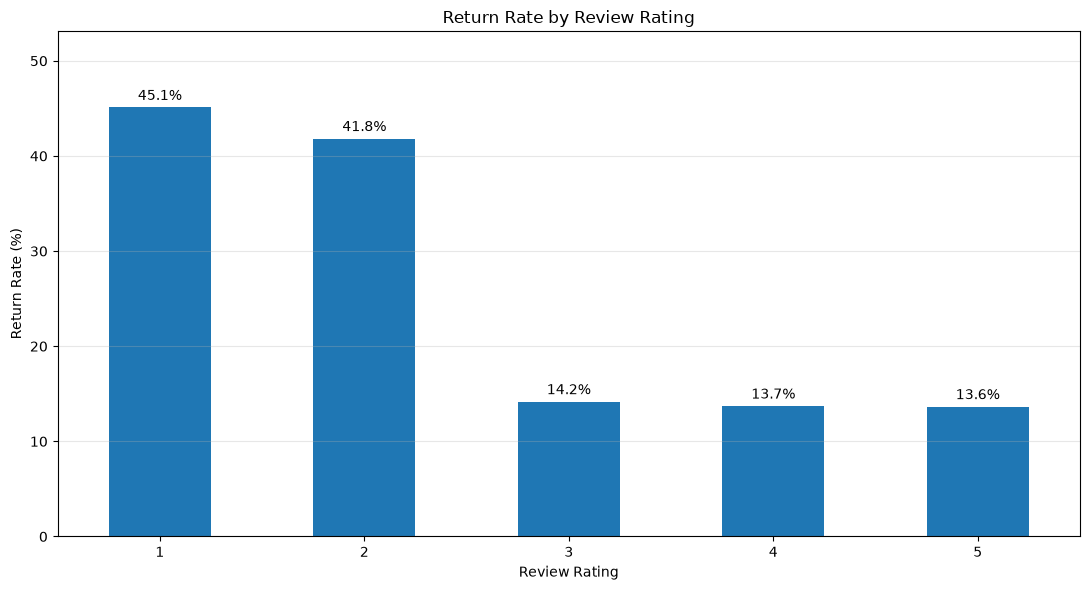

In [135]:
# Compare return behaviour across customer-rating levels
rating_return_plot = (
    rating_return_summary
    .set_index("Review Rating")
)

ax = rating_return_plot["Return Rate (%)"].plot(
    kind="bar",
    figsize=(11, 6)
)

plt.title("Return Rate by Review Rating")
plt.xlabel("Review Rating")
plt.ylabel("Return Rate (%)")
plt.xticks(rotation=0)
plt.ylim(
    0,
    rating_return_plot["Return Rate (%)"].max() + 8
)
plt.grid(axis="y", alpha=0.3)

ax.bar_label(
    ax.containers[0],
    fmt="%.1f%%",
    padding=3
)
save_figure(
    "h6_return_rate_by_review_rating.png"
)
plt.tight_layout()
plt.show()

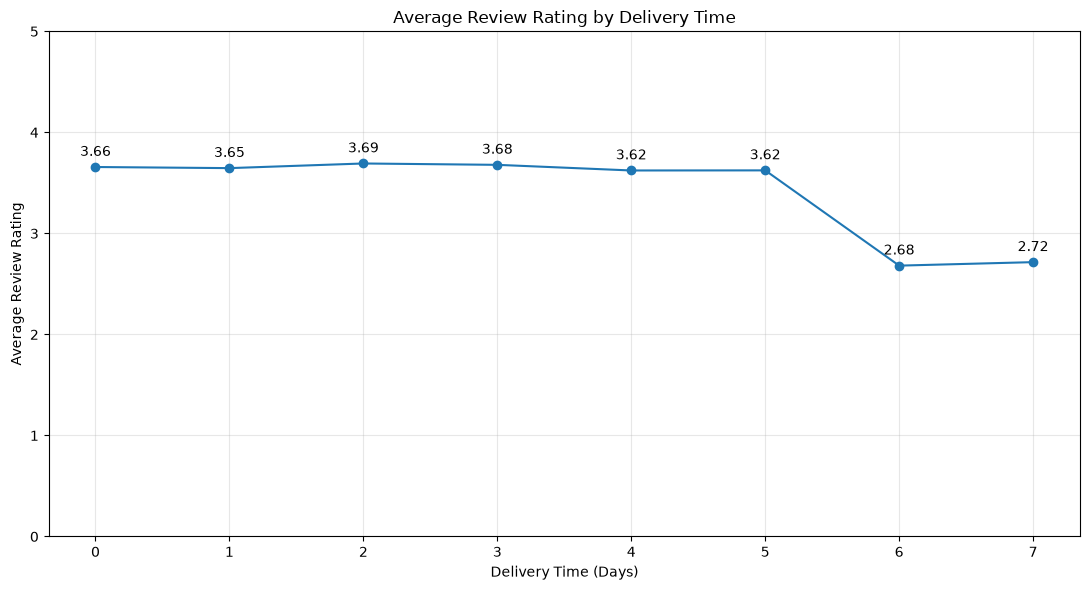

In [136]:
# Show how customer ratings change with delivery time
delivery_day_plot = (
    delivery_day_summary
    .sort_values("Delivery Time (Days)")
)

ax = delivery_day_plot.plot(
    x="Delivery Time (Days)",
    y="Average_Rating",
    kind="line",
    marker="o",
    figsize=(11, 6),
    legend=False
)

plt.title("Average Review Rating by Delivery Time")
plt.xlabel("Delivery Time (Days)")
plt.ylabel("Average Review Rating")
plt.xticks(
    delivery_day_plot["Delivery Time (Days)"]
)
plt.ylim(0, 5)
plt.grid(alpha=0.3)

for x, y in zip(
    delivery_day_plot["Delivery Time (Days)"],
    delivery_day_plot["Average_Rating"]
):
    plt.annotate(
        f"{y:.2f}",
        (x, y),
        textcoords="offset points",
        xytext=(0, 8),
        ha="center"
    )

plt.tight_layout()
save_figure(
    "h6_average_review_rating_by_delivery_time.png"
)
plt.show()

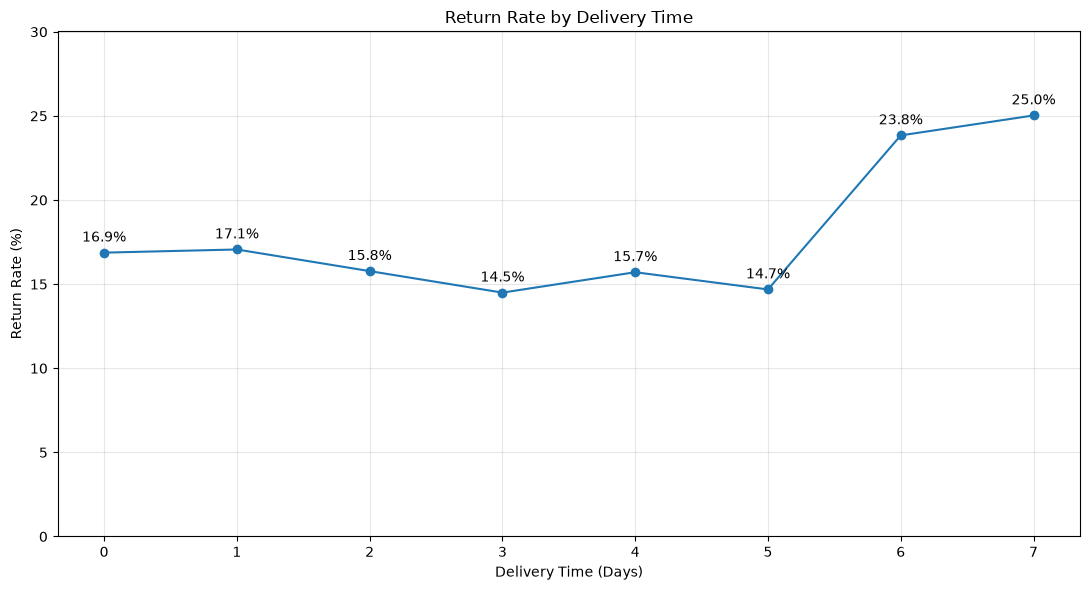

In [137]:
# Show how return rates change with delivery time
ax = delivery_day_plot.plot(
    x="Delivery Time (Days)",
    y="Return Rate (%)",
    kind="line",
    marker="o",
    figsize=(11, 6),
    legend=False
)

plt.title("Return Rate by Delivery Time")
plt.xlabel("Delivery Time (Days)")
plt.ylabel("Return Rate (%)")
plt.xticks(
    delivery_day_plot["Delivery Time (Days)"]
)
plt.ylim(
    0,
    delivery_day_plot["Return Rate (%)"].max() + 5
)
plt.grid(alpha=0.3)

for x, y in zip(
    delivery_day_plot["Delivery Time (Days)"],
    delivery_day_plot["Return Rate (%)"]
):
    plt.annotate(
        f"{y:.1f}%",
        (x, y),
        textcoords="offset points",
        xytext=(0, 8),
        ha="center"
    )
save_figure(
    "h6_return_rate_by_delivery_time.png"
)
plt.tight_layout()
plt.show()

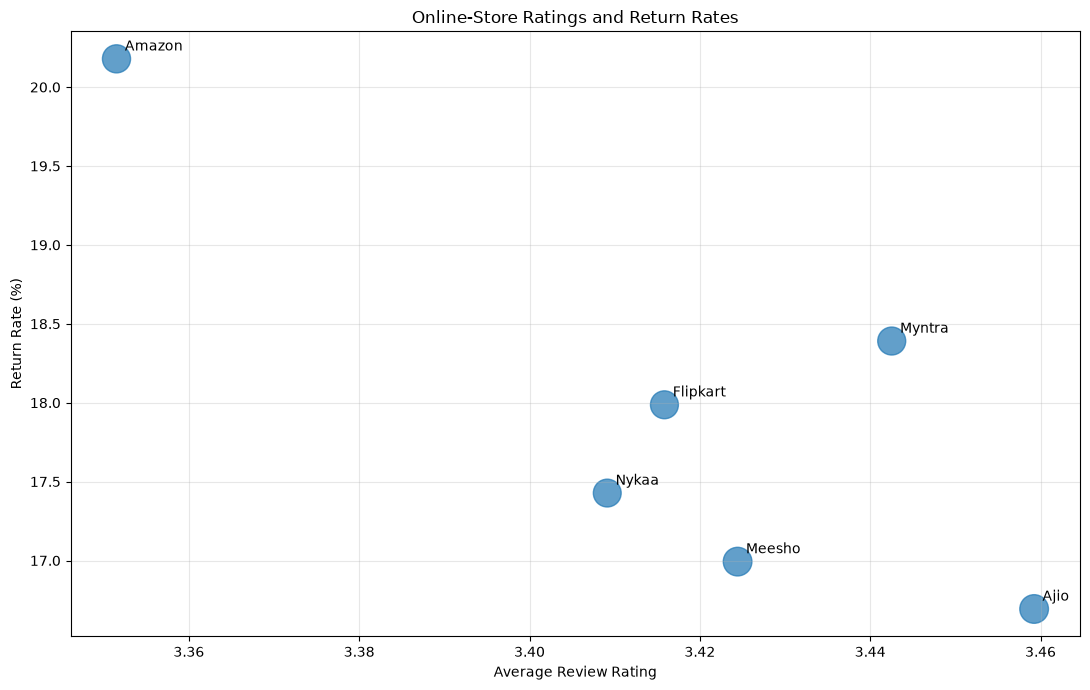

In [138]:
# Compare online stores using customer ratings and return rates
plt.figure(figsize=(11, 7))

plt.scatter(
    store_experience_summary["Average_Rating"],
    store_experience_summary["Return Rate (%)"],
    s=(
        store_experience_summary["Transaction_Count"]
        / 3
    ),
    alpha=0.7
)

for _, row in store_experience_summary.iterrows():
    plt.annotate(
        row["Online Store"],
        (
            row["Average_Rating"],
            row["Return Rate (%)"]
        ),
        textcoords="offset points",
        xytext=(6, 6)
    )

plt.title("Online-Store Ratings and Return Rates")
plt.xlabel("Average Review Rating")
plt.ylabel("Return Rate (%)")
plt.grid(alpha=0.3)

plt.tight_layout()
save_figure(
    "h6_online_store_ratings_and_return_rates.png"
)
plt.show()

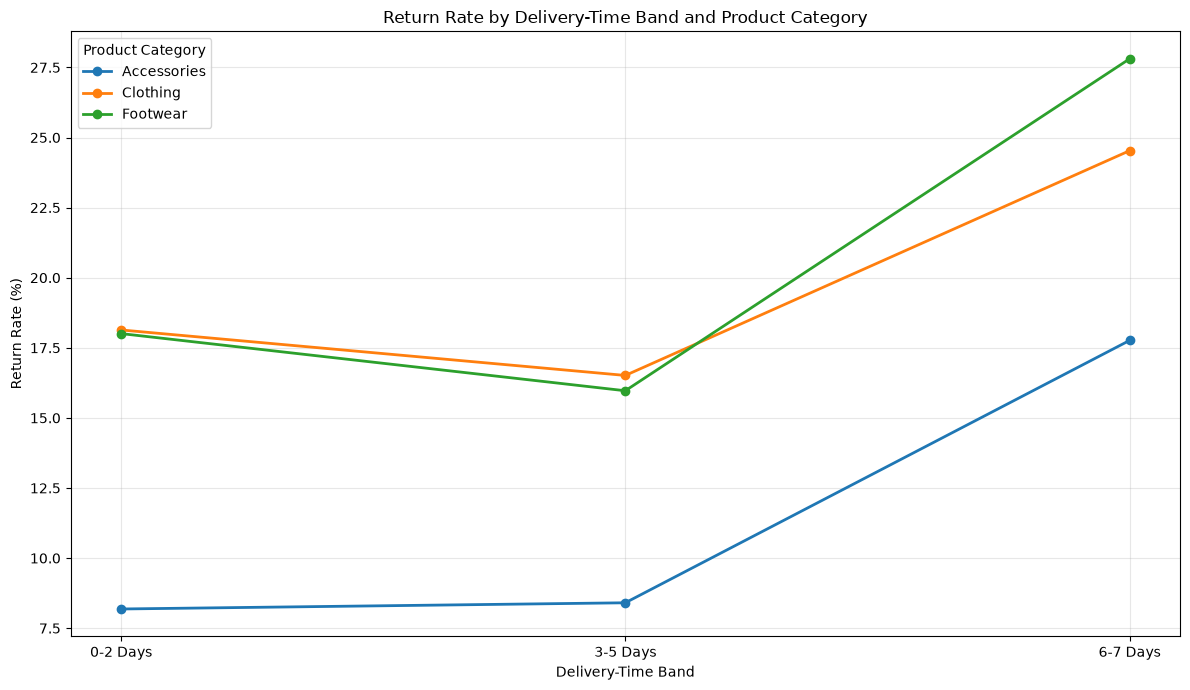

In [139]:
# Compare delivery-related return patterns within each category
ax = category_delivery_return_pivot.plot(
    kind="line",
    marker="o",
    figsize=(12, 7),
    linewidth=2
)

plt.title(
    "Return Rate by Delivery-Time Band and Product Category"
)
plt.xlabel("Delivery-Time Band")
plt.ylabel("Return Rate (%)")
plt.xticks(
    range(
        len(category_delivery_return_pivot.index)
    ),
    category_delivery_return_pivot.index,
    rotation=0
)
plt.grid(alpha=0.3)
plt.legend(title="Product Category")
plt.tight_layout()

save_figure(
    "h6_return_rate_by_delivery_band_and_category.png"
)

plt.show()

### Visual Comparison Results

**Review ratings and returns**

- One-star transactions had the highest return rate at 45.1%, followed by two-star transactions at 41.8%.
- Return rates dropped sharply to 14.2% at three stars and remained close to 14% for four- and five-star transactions.
- The main difference is therefore between ratings of two or below and ratings of three or above, rather than a gradual decline at every rating level.

**Delivery time and ratings**

- Average ratings remained relatively stable between 3.62 and 3.69 when delivery took zero to five days.
- Ratings fell sharply to 2.68 after six days and 2.72 after seven days.
- The visual indicates a clear deterioration once delivery extended beyond five days.

**Delivery time and returns**

- Return rates fluctuated between 14.5% and 17.1% for deliveries completed within five days.
- They increased substantially to 23.8% after six days and 25.0% after seven days.
- Faster delivery did not produce a consistent improvement within the zero-to-five-day range. The important pattern is the sharp increase associated with six- and seven-day delivery.

**Online-store experience**

- Ajio recorded the highest average rating at approximately 3.46 and the lowest return rate at approximately 16.7%.
- Amazon recorded the lowest average rating at approximately 3.35 and the highest return rate at approximately 20.2%.
- The stores generally show an inverse relationship between ratings and returns, although the pattern is not perfectly linear across every store.
- Store transaction volumes were broadly similar, so bubble size did not materially change the comparison.

**Category-controlled returns**

- Accessories maintained the lowest return rate in every delivery-time band.
- Clothing and Footwear had similar return rates for deliveries completed within five days.
- Return rates increased sharply in the 6–7 Day band for all categories, reaching approximately 17.8% for Accessories, 24.5% for Clothing, and 27.8% for Footwear.
- The long-delivery pattern therefore remained visible even after controlling for product category.

**Overall visual conclusion**

- Poor ratings were strongly associated with higher returns.
- Delivery outcomes remained relatively stable for the first five days but deteriorated substantially after six or seven days.
- Product category influenced the baseline return rate, while long delivery times were associated with poorer outcomes across every category.

## Hypothesis 6 Verdict

**Verdict: Partially supported**

The hypothesis expected faster delivery to be associated with higher ratings and lower return rates. This expectation was supported mainly when comparing deliveries completed within five days with deliveries taking six or seven days.

Average ratings remained relatively stable for delivery times of zero to five days, while six- and seven-day deliveries recorded a sharp decline. Return rates followed a similar pattern, increasing substantially after five days.

However, the results did not show that every reduction in delivery time produced better outcomes. Same Day delivery did not consistently outperform Express delivery, and the 3–5 Day group recorded a slightly lower return rate than the 0–2 Day group. The relationship is therefore better interpreted as a long-delivery threshold rather than a continuous “faster is always better” pattern.

The expectation that low ratings would be associated with more returns was strongly supported. One- and two-star transactions had return rates above 40%, compared with approximately 14% for ratings of three or higher.

The free-shipping expectation was not supported. Free and paid shipping produced almost identical ratings and return rates, while shipping-charge amount had correlations close to zero with customer outcomes.

Ajio recorded the strongest combination of rating and return performance, while Amazon recorded the weakest. However, average delivery-time differences between stores were small, so store outcomes cannot be attributed to delivery speed alone.

Within this synthetic dataset, avoiding delivery times of six or seven days appears more important than reducing already acceptable delivery times from five days to one or zero days. Ratings, product category, and store-level differences also remain relevant to return behaviour.

# Overall Conclusions and Recommendations

## Overall Conclusion

The six hypotheses show that customer-shopping behaviour within this synthetic dataset is influenced more clearly by product type, shopping channel, customer experience, and delivery conditions than by discount percentage alone.

Promotional-sale transactions recorded higher average purchase amounts than standard-day transactions, but they did not produce larger quantities per transaction. Discounts also showed almost no consistent relationship with purchase amount, quantity, ratings, or returns. This suggests that promotions may raise transaction value in selected situations, but larger discounts should not automatically be interpreted as producing larger baskets.

Customer contribution was broadly distributed across age and gender groups. Customers aged 55–64 generated the strongest transaction and purchase-amount contribution relative to their group size. Subscription status produced almost no improvement in transaction frequency and was associated with slightly lower spending measures, indicating that the simulated subscription programme did not create a clear commercial advantage.

Product performance showed a strong distinction between volume and value. Clothing generated the highest transaction volume, while Footwear contributed most of the purchase amount. Sneakers and Running Shoes were especially important high-value items. However, Footwear and Clothing also appeared frequently among the products with higher return rates, suggesting a need to balance commercial value with fit, sizing, and post-purchase experience.

Online shopping reached substantially more customers than offline shopping, but both channels showed similar average quantities, transaction values, and broad product composition. Online transactions recorded a moderately higher return rate and supported a wider range of payment methods. The six online stores contributed relatively similar commercial shares, although their ratings and return outcomes differed.

The strongest customer-experience pattern concerned delivery time. Ratings and return rates remained relatively stable when delivery was completed within five days, but customer outcomes deteriorated sharply when delivery took six or seven days. Low ratings were also strongly associated with returns, while free shipping and shipping-charge amount showed almost no meaningful relationship with customer outcomes.

## Decision Recommendations

**Control long delivery times:** Operational attention should focus on preventing deliveries from extending beyond five days. Reducing six- and seven-day deliveries appears more important than making already acceptable deliveries slightly faster.

**Balance Footwear value with return management:** Footwear should remain a commercial priority because of its high purchase contribution, but sizing information, product descriptions, and return analysis should receive additional attention.

**Use discounts selectively:** Large discounts should be treated as promotional tools rather than a guaranteed method for increasing basket quantity or reducing returns. Promotion performance should be evaluated using transaction value, profitability, and customer outcomes together.

**Review the subscription proposition:** Since subscribed customers did not demonstrate stronger spending or transaction activity, the benefits and targeting of the simulated subscription programme should be reconsidered.

**Improve online post-purchase experience:** Online shopping provides broad reach and payment flexibility, but its higher return rate indicates an opportunity to improve product information, delivery reliability, and return prevention.

## Limitations

This project uses a synthetic Indian retail dataset and does not represent the verified behaviour of a real company or all Indian consumers.

The findings describe associations within the simulated transactions and do not establish causal relationships.

The dataset does not provide complete information about profit margins, marketing costs, reasons for returns, or the operational causes of delivery delays. These factors would be required for more complete business decisions.

# Export Final Analysis Tables

Selected final summary tables from all six hypotheses are exported as individual CSV files.

Temporary plotting tables and duplicate pivot views are excluded because their underlying summary tables already contain the same information.

In [140]:
# Export final analysis tables together
tables_to_export = {
    # Hypothesis 1
    "h1_monthly_activity":
        "monthly_activity",
    "h1_promotion_summary":
        "promotion_summary",

    # Hypothesis 2
    "h2_age_group_summary":
        "age_group_summary",
    "h2_gender_summary":
        "gender_summary",
    "h2_subscription_summary":
        "subscription_summary",
    "h2_frequency_summary":
        "frequency_summary",

    # Hypothesis 3
    "h3_category_summary":
        "category_summary",
    "h3_item_summary":
        "item_summary",
    "h3_brand_summary":
        "brand_summary",

    # Hypothesis 4
    "h4_channel_summary":
        "channel_summary",
    "h4_category_transaction_share":
        "channel_category_transaction_share",
    "h4_category_purchase_share":
        "channel_category_purchase_share",
    "h4_channel_item_summary":
        "channel_item_summary",
    "h4_payment_share":
        "channel_payment_share",
    "h4_online_store_summary":
        "online_store_summary",

    # Hypothesis 5
    "h5_discount_summary":
        "discount_summary",
    "h5_discount_correlations":
        "discount_correlations",
    "h5_discount_category_mix":
        "discount_category_mix",
    "h5_discount_category_summary":
        "discount_category_summary",
    "h5_discount_promotion_share":
        "discount_promotion_share",

    # Hypothesis 6
    "h6_rating_return_summary":
        "rating_return_summary",
    "h6_return_status_experience":
        "return_status_experience",
    "h6_delivery_speed_summary":
        "delivery_speed_summary",
    "h6_delivery_day_summary":
        "delivery_day_summary",
    "h6_delivery_time_band_summary":
        "delivery_time_band_summary",
    "h6_shipping_type_summary":
        "shipping_type_summary",
    "h6_shipping_charge_summary":
        "shipping_charge_summary",
    "h6_delivery_correlations":
        "delivery_correlations",
    "h6_store_experience_summary":
        "store_experience_summary",
    "h6_category_delivery_summary":
        "category_delivery_summary"
}

exported_tables = []
missing_tables = []

for filename, variable_name in tables_to_export.items():
    table = globals().get(variable_name)

    if isinstance(table, pd.Series):
        export_table = table.to_frame(
            name=table.name or "Value"
        )

    elif isinstance(table, pd.DataFrame):
        export_table = table.copy()

    else:
        missing_tables.append(variable_name)
        continue

    index = export_table.index

    # Preserve meaningful pivot/correlation row labels
    if isinstance(index, pd.MultiIndex):
        export_table = export_table.reset_index()

    elif (
        index.name is not None
        or not pd.api.types.is_integer_dtype(index.dtype)
    ):
        export_table = export_table.reset_index()

    else:
        export_table = export_table.reset_index(
            drop=True
        )

    export_table.columns.name = None

    export_table.to_csv(
        TABLE_DIR / f"{filename}.csv",
        index=False
    )

    exported_tables.append(filename)

print(
    f"Exported {len(exported_tables)} tables successfully."
)

if missing_tables:
    print(
        "\nTables not found in the current session:"
    )

    for table_name in missing_tables:
        print("-", table_name)

    print(
        "\nRun the notebook from the beginning, "
        "then rerun this export cell."
    )

Exported 30 tables successfully.


### Verification 

In [141]:
# Verify the number of exported project files
figure_count = len(list(FIGURE_DIR.glob("*.png")))
table_count = len(list(TABLE_DIR.glob("*.csv")))

print(f"Saved figures: {figure_count}")
print(f"Saved tables: {table_count}")

Saved figures: 29
Saved tables: 30
